https://data.mendeley.com/public-files/datasets/2pkxckwgs3/files/4f402c76-388e-4bde-b887-f1be522001db/file_downloaded


In [3]:
!git config --global user.email "karkoutlimhmdk@gmail.com"
!git config --global user.name "onnaga"

In [4]:
%cd /content/drive/MyDrive/Colab Notebooks/nlpHompework

/content/drive/MyDrive/Colab Notebooks/nlpHompework


In [2]:
# ============================================================
# تحميل + فك ضغط مشروط بوجود البيانات على Google Drive
# ============================================================

import os
import zipfile
from google.colab import drive

# ربط الدرايف
drive.mount('/content/drive')

# المسارات
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
DATA_DIR = f'{BASE_DIR}/SSAC-UNPC_data'
ZIP_PATH = f'{BASE_DIR}/SSAC-UNPC.zip'

# التأكد من وجود مجلد المشروع
os.makedirs(BASE_DIR, exist_ok=True)

# ============================================================
# التحقق والتنفيذ المشروط
# ============================================================

if os.path.exists(DATA_DIR):
    print("✅ البيانات موجودة مسبقًا على Google Drive")
    print(f"📁 المسار: {DATA_DIR}")
    print("⏭️ تم تخطي التحميل وفك الضغط")
else:
    print("⬇️ البيانات غير موجودة — بدء التحميل")

    !wget "https://data.mendeley.com/public-files/datasets/2pkxckwgs3/files/4f402c76-388e-4bde-b887-f1be522001db/file_downloaded" -O "{ZIP_PATH}"

    print(" فك ضغط البيانات...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print(" تم التحميل وفك الضغط بنجاح")

print("\n العملية انتهت بأمان")


Mounted at /content/drive
✅ البيانات موجودة مسبقًا على Google Drive
📁 المسار: /content/drive/MyDrive/Colab Notebooks/nlpHompework/SSAC-UNPC_data
⏭️ تم تخطي التحميل وفك الضغط

 العملية انتهت بأمان


التوابع المساعدة

In [ ]:
import os
import re
import random # ضروري للتصفية العشوائية لـ NO_PUNCT
from collections import Counter
from typing import List, Tuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. القواميس الأساسية (يجب أن تبقى كما هي)
# =========================================================================
PUNCT_MAPPING = {
    '،': 1, ',': 1, '.': 2, '۔': 2, '…': 2,
    '؟': 3, '?': 3, ':': 4,
    ';': 5, '؛': 5, '!': 6, '¡': 6,
}

ID_TO_PUNCT = {
    0: 'NO_PUNCT', 1: 'فاصلة_Comma', 2: 'نقطة_Full_Stop',
    3: 'استفهام_Question_Mark', 4: 'نقطتان_Colon',
    5: 'فاصلة_منقوطة_Semicolon', 6: 'تعجب_Exclamation_Mark',
}

# =========================================================================
# 2. التوابع المساعدة (Preprocessing Functions)
# =========================================================================

def clean_text(text: str) -> str:
    """إزالة التشكيل وتوحيد الألفات والمسافات."""
    p_harakat = re.compile(r'[\u064b-\u065e]')
    text = re.sub(p_harakat, '', text)
    text = re.sub(r'[إأآ]', r'ا', text)
    text = re.sub(r'ى', r'ي', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_and_label(raw_text: str, punct_mapping: dict) -> Tuple[List[str], List[int]]:
    """تقطيع النص إلى كلمات وعلامات ترقيم (Labels)."""
    target_puncts = "".join(punct_mapping.keys())
    # التقطيع مع الحفاظ على علامات الترقيم
    tokens = re.findall(rf'\b\w+\b|[^{re.escape(target_puncts)}\s]+|[{re.escape(target_puncts)}]', raw_text)

    input_tokens = []
    output_labels = []
    NO_PUNCT_ID = 0

    for token in tokens:
        if token in punct_mapping:
            if input_tokens:
                output_labels[-1] = punct_mapping[token]

        elif token and not token.isspace():
            cleaned_word = clean_text(token)
            if cleaned_word:
                input_tokens.append(cleaned_word)
                output_labels.append(NO_PUNCT_ID)

    return input_tokens, output_labels

def split_text_into_chunks(raw_text: str, chunk_type: str = 'sentences') -> List[str]:
    """تقسيم النص إلى قطع صغيرة (جمل) للمعالجة الجزئية."""
    if chunk_type == 'sentences':
        # التقسيم عند علامات نهاية الجملة مع الاحتفاظ بها
        sentences = re.split(r'([.۔…؟!¡])', raw_text)

        chunks = []
        for i in range(0, len(sentences), 2):
            chunk = sentences[i]
            if i + 1 < len(sentences):
                # ندمج الجملة مع علامة الترقيم التي تليها ونضيف مسافة للفصل
                chunk += sentences[i+1] + ' '
            if chunk.strip():
                chunks.append(chunk.strip())
        return chunks
    return [raw_text]

def append_to_csv(words: List[str], labels: List[int], filename: str):
    """الكتابة المتزايدة إلى ملف CSV لتجنب استهلاك RAM."""
    with open(filename, 'a', encoding='utf-8') as f:
        for word, label in zip(words, labels):
            # نكتب كل سطر بصيغة: "الكلمة\tالمُعرف"
            f.write(f"{word}\t{label}\n")

# الدراسة الاولية للبيانات بعد الاطلاع على الورقة البحثية



استراتيجية موازنة البيانات (Under-sampling Strategy): نظراً لأن الكلمات التي لا يتبعها ترقيم (Label 0) تطغى بشكل هائل على البيانات، تم اعتماد منطق احتمالي ذكي:

الجمل المحملة بعلامات نادرة: يتم الاحتفاظ بكل محتواها لضمان تعلم السياق.

الكلمات العادية: يتم أخذ عينات عشوائية منها بنسبة ضئيلة جداً (0.5% إلى 1%) لتقليل حجم البيانات ومنع انحياز النموذج للفئة الطاغية.



In [ ]:
# ============================================================
# خلية المعالجة المتوازية (Skip إذا كان CSV موجودًا)
# ============================================================

import os
import re
import random
from multiprocessing import Pool, cpu_count
from google.colab import drive

drive.mount('/content/drive')

# =================== المسارات ===================

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
DATA_DIR = f'{BASE_DIR}/SSAC-UNPC_data/SSAC-UNPC'
OUTPUT_CSV_FILE = f'{BASE_DIR}/processed_punctuation_data.csv'

# =================== فحص الإخراج ===================

if os.path.exists(OUTPUT_CSV_FILE):
    print("✅ ملف CSV المعالج موجود مسبقًا")
    print(f"📁 {OUTPUT_CSV_FILE}")
    print("⏭️ تم تخطي خلية المعالجة الثقيلة بالكامل")
else:
    print("⚙️ ملف CSV غير موجود — بدء المعالجة المتوازية")

    TARGET_RARE_IDS = {3, 4, 5, 6}
    TARGET_RARE_PUNCTS_CHARS = ['!', '¡', '؟', '?', ':', ';', '؛']
    TARGET_PUNCT_REGEX = re.compile(f"[{re.escape(''.join(TARGET_RARE_PUNCTS_CHARS))}]")

    NUM_WORKERS = min(6, cpu_count())

    all_files = [
        os.path.join(DATA_DIR, f)
        for f in os.listdir(DATA_DIR)
        if f.endswith('.txt')
    ]

    if not all_files:
        raise FileNotFoundError(f"❌ لا توجد ملفات .txt في {DATA_DIR}")

    print(f"🚀 معالجة {len(all_files)} ملف باستخدام {NUM_WORKERS} عمليات")

    def process_single_file(file_path):
        rng = random.random
        file_words, file_labels = [], []

        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()

        chunks = split_text_into_chunks(content, chunk_type='sentences')

        for chunk in chunks:
            chunk_words, chunk_labels = preprocess_and_label(chunk, PUNCT_MAPPING)
            has_rare = bool(set(chunk_labels) & TARGET_RARE_IDS)

            if has_rare:
                for w, lbl in zip(chunk_words, chunk_labels):
                    if lbl in TARGET_RARE_IDS:
                        file_words.append(w)
                        file_labels.append(lbl)
                    elif lbl == 0 and rng() < 0.01:
                        file_words.append(w)
                        file_labels.append(lbl)
            else:
                if rng() < 0.005:
                    file_words.extend(chunk_words)
                    file_labels.extend(chunk_labels)

        return file_words, file_labels

    total_samples_processed = 0

    with Pool(NUM_WORKERS) as pool:
        for i, (words, labels) in enumerate(
            pool.imap_unordered(process_single_file, all_files), 1
        ):
            if words:
                append_to_csv(words, labels, OUTPUT_CSV_FILE)
                total_samples_processed += len(words)

            if i % 10 == 0 or i == len(all_files):
                print(f"📄 {i}/{len(all_files)} ملف — ✍️ {total_samples_processed:,} كلمة")

    print("\n✅ انتهت المعالجة بنجاح")
    print(f"📁 الملف الناتج: {OUTPUT_CSV_FILE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ملف CSV المعالج موجود مسبقًا
📁 /content/drive/MyDrive/Colab Notebooks/nlpHompework/processed_punctuation_data.csv
⏭️ تم تخطي خلية المعالجة الثقيلة بالكامل



--- التوزيع الإجمالي لعلامات الترقيم (من CSV مباشرة) ---
|   Punct_ID |   Count | Punct_Name             |   Percentage |
|-----------:|--------:|:-----------------------|-------------:|
|          0 | 1707885 | NO_PUNCT               |      42.8701 |
|          5 | 1539737 | فاصلة_منقوطة_Semicolon |      38.6493 |
|          4 |  569589 | نقطتان_Colon           |      14.2974 |
|          1 |   58223 | فاصلة_Comma            |       1.4615 |
|          2 |   53888 | نقطة_Full_Stop         |       1.3527 |
|          3 |   53805 | استفهام_Question_Mark  |       1.3506 |
|          6 |     738 | تعجب_Exclamation_Mark  |       0.0185 |


/tmp/ipython-input-2450380363.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


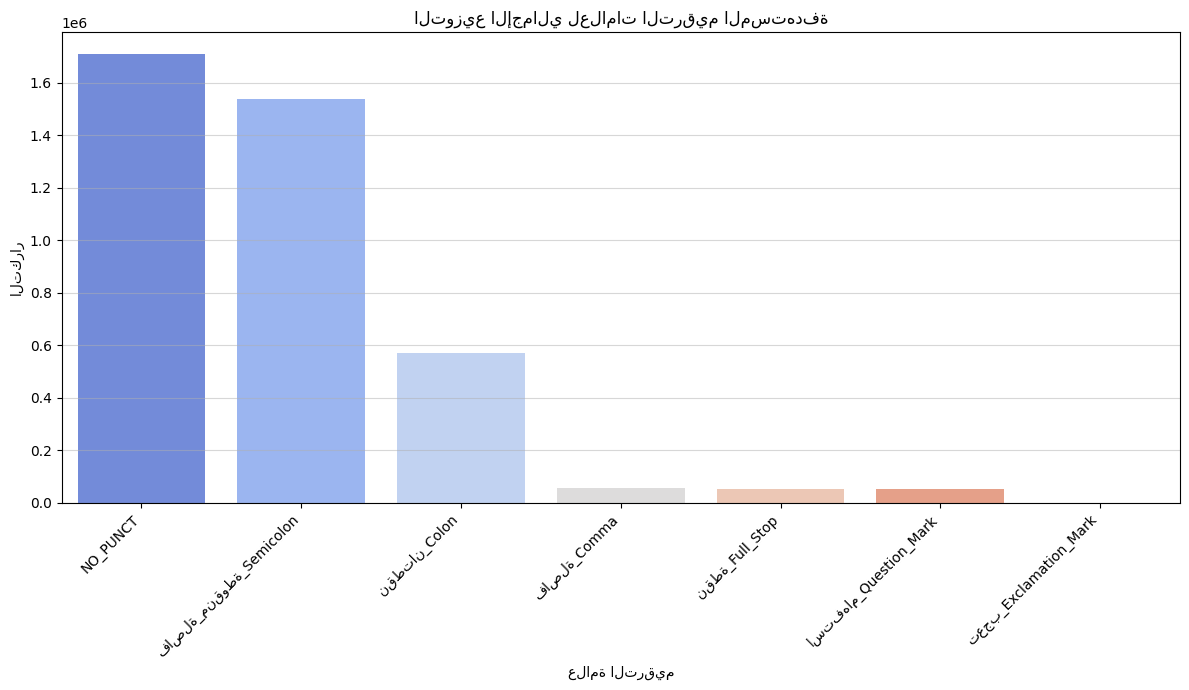


💾 تم حفظ الشكل في:
/content/drive/MyDrive/Colab Notebooks/nlpHompework/final_overall_punctuation_distribution.png


In [ ]:
# =========================================================================
# تحليل التوزيع الإجمالي (Visualization) — مستقل 100%
# =========================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =================== المسارات ===================

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
CSV_PATH = f'{BASE_DIR}/processed_punctuation_data.csv'
FIG_PATH = f'{BASE_DIR}/final_overall_punctuation_distribution.png'

# =================== التحقق من وجود CSV ===================

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"❌ ملف CSV غير موجود:\n{CSV_PATH}")

# =================== قراءة CSV وحساب التوزيع ===================

df_data = pd.read_csv(
    CSV_PATH,
    sep='\t',
    header=None,
    names=['word', 'label'],
    dtype={'label': 'int8'}
)

df_counts = (
    df_data['label']
    .value_counts()
    .rename_axis('Punct_ID')
    .reset_index(name='Count')
)

# ربط أسماء علامات الترقيم
df_counts['Punct_Name'] = df_counts['Punct_ID'].map(ID_TO_PUNCT)

# حساب النسب
df_counts['Percentage'] = (
    df_counts['Count'] / df_counts['Count'].sum()
) * 100

df_counts = df_counts.sort_values(by='Count', ascending=False)

# =================== الطباعة ===================

print("\n--- التوزيع الإجمالي لعلامات الترقيم (من CSV مباشرة) ---")
print(
    df_counts[
        ['Punct_ID', 'Count', 'Punct_Name', 'Percentage']
    ].to_markdown(index=False, floatfmt=".4f")
)

# =================== الرسم ===================

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Punct_Name',
    y='Count',
    data=df_counts,
    palette="coolwarm"
)
plt.title('التوزيع الإجمالي لعلامات الترقيم المستهدفة')
plt.xlabel('علامة الترقيم')
plt.ylabel('التكرار')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_PATH)
plt.show()

print(f"\n💾 تم حفظ الشكل في:\n{FIG_PATH}")



# **ملاحظات على الخرج**

من خلال القراءة التحليلية لجدول توزيع

الأصناف (Class Distribution)
، نلاحظ وجود تباين إحصائي كبير بين الفئات، وهو ما يمكن تلخيصه في النقاط التالية:

هيمنة الفئات الكبرى: تشكل فئتا (عدم الترقيم) و(الفاصلة المنقوطة) معاً أكثر من 81% من إجمالي البيانات، مما يجعل النموذج عرضة للانحياز الطبيعي نحو هذه الأصناف.

ندرة الأصناف الحرجة: نلاحظ انخفاضاً حاداً في تكرار (علامة التعجب) التي تمثل فقط 0.0185% من البيانات، تليها (النقطة) و(الاستفهام) بنسب لا تتجاوز 1.4%.

أهمية المعالجة المسبقة: هذا التوزيع يبرر استخدامنا لتقنيات مثل Sample Weighting أو Under-sampling؛ فلولا هذه التقنيات لقام النموذج بتجاهل العلامات النادرة تماماً والحصول على دقة (Accuracy) وهمية عالية بمجرد توقع الفئات المهيمنة.

حساب أوزان الفئات النهائية لتعزيز أداء الأصناف النادرة (Class Weighting)الهدف من الكود:الهدف الأساسي لهذه الخلية هو إجراء تحليل نهائي لتوزيع الأصناف الرقمية (Label IDs) في مجموعة البيانات المُعالجة سابقاً، ثم حساب أوزان الفئات (Class Weights). يتم استخدام هذه الأوزان لاحقاً عند تدريب النماذج (خاصة نماذج التعلم العميق) لتعديل دالة الخسارة (Loss Function)، بهدف منح أهمية أكبر للأصناف النادرة أثناء عملية التدريب.التقنية المعتمدة: تقنية ترجيح الفئات (Class Weighting):تُعد تقنية ترجيح الفئات إحدى الطرق الفعالة لمواجهة مشكلة عدم التوازن في بيانات التصنيف، حيث يتم تعيين أوزان أعلى للأصناف الأقل تمثيلاً (النادرة) وأوزان أقل للأصناف الأكثر تمثيلاً (الشائعة). وهذا يضمن أن النموذج "يُعاقَب" بشدة أكبر عند ارتكاب خطأ في تصنيف علامات الترقيم النادرة (مثل علامة الاستفهام) مقارنة بالخطأ في تصنيف علامة شائعة (مثل لا ترقيم).آلية توزيع الأوزان (Class Weight Calculation):يعتمد الكود على حساب الوزن لكل صنف وفقاً للمعادلة الشائعة في حالات عدم التوازن:$$Weight_c = \frac{N_{total}}{N_{classes} \times N_c}$$حيث:$N_{total}$: هو العدد الإجمالي لجميع العينات في مجموعة البيانات.$N_{classes}$: هو العدد الكلي للأصناف (علامات الترقيم المختلفة).$N_c$: هو عدد العينات المنتمية للصنف $c$.خطوات التنفيذ:قراءة البيانات: يتم قراءة ملف CSV المُعالج الذي يحتوي على الكلمات والتصنيفات الرقمية.حساب التكرارات: يُحسب تكرار كل صنف (final_label_counts).تطبيق المعادلة: يتم تطبيق المعادلة أعلاه: كلما قل عدد تكرارات صنف معين ($N_c$)، زاد وزنه المخصص ($Weight_c$).تطبيع الأوزان (Normalization): يتم تطبيع الأوزان الناتجة بقسمتها على أعلى وزن تم حسابه. هذا يضمن أن يكون الوزن الأقصى يساوي 1، مما يسهل دمجها في دالة الخسارة للنماذج العصبونية.

In [ ]:
# =========================================================================
# حساب أوزان الفئات النهائية (من CSV على Google Drive)
# =========================================================================

import os
import pandas as pd

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
OUTPUT_CSV_FILE = f'{BASE_DIR}/processed_punctuation_data.csv'

print("\n📥 قراءة ملف CSV وحساب أوزان الفئات...")

if not os.path.exists(OUTPUT_CSV_FILE):
    raise FileNotFoundError(f"❌ الملف غير موجود:\n{OUTPUT_CSV_FILE}")

df_data = pd.read_csv(
    OUTPUT_CSV_FILE,
    sep='\t',
    header=None,
    names=['word', 'label'],
    dtype={'label': 'int8'}
)

final_label_counts = df_data['label'].value_counts().to_dict()
total_samples = len(df_data)
num_classes = len(ID_TO_PUNCT)

df_counts = pd.DataFrame(
    final_label_counts.items(),
    columns=['Label_ID', 'Count']
)
df_counts['Punct_Name'] = df_counts['Label_ID'].map(ID_TO_PUNCT)
df_counts = df_counts.sort_values(by='Count', ascending=False)

print("\n--- التوزيع النهائي للبيانات ---")
print(df_counts.to_markdown(index=False))

class_weights = {}
for label_id in ID_TO_PUNCT:
    count = final_label_counts.get(label_id, 0)
    weight = total_samples / (num_classes * count) if count > 0 else total_samples / num_classes
    class_weights[label_id] = weight

max_weight = max(class_weights.values())
normalized_class_weights = {
    k: v / max_weight for k, v in class_weights.items()
}

df_weights = pd.DataFrame(
    normalized_class_weights.items(),
    columns=['Label_ID', 'Normalized_Weight']
)
df_weights['Punct_Name'] = df_weights['Label_ID'].map(ID_TO_PUNCT)
df_weights = df_weights.sort_values(by='Normalized_Weight', ascending=False)

print("\n--- أوزان الفئات النهائية (Normalized) ---")
print(df_weights.to_markdown(index=False, floatfmt=".4f"))



📥 قراءة ملف CSV وحساب أوزان الفئات...

--- التوزيع النهائي للبيانات ---
|   Label_ID |   Count | Punct_Name             |
|-----------:|--------:|:-----------------------|
|          0 | 1707885 | NO_PUNCT               |
|          5 | 1539737 | فاصلة_منقوطة_Semicolon |
|          4 |  569589 | نقطتان_Colon           |
|          1 |   58223 | فاصلة_Comma            |
|          2 |   53888 | نقطة_Full_Stop         |
|          3 |   53805 | استفهام_Question_Mark  |
|          6 |     738 | تعجب_Exclamation_Mark  |

--- أوزان الفئات النهائية (Normalized) ---
|   Label_ID |   Normalized_Weight | Punct_Name             |
|-----------:|--------------------:|:-----------------------|
|          6 |              1.0000 | تعجب_Exclamation_Mark  |
|          3 |              0.0137 | استفهام_Question_Mark  |
|          2 |              0.0137 | نقطة_Full_Stop         |
|          1 |              0.0127 | فاصلة_Comma            |
|          4 |              0.0013 | نقطتان_Colon           |

# تجربة مع بيانات no punct + PAD

المعالجة : تأخذ النص وتحوله إلى أرقام (من 1 إلى 7). الكلمات التي ليس لها ترقيم تأخذ الرقم 1.

قبل التدريب : بما أن الجمل أطوالها مختلفة، نقوم بإضافة أصفار (0) في نهاية كل جملة حتى يتساوى الجميع عند طول 50 مثلاً. هذه الأصفار هي الـ PAD.

داخل النموذج: عندما يرى النموذج الرقم 0، يعرف (بسبب خاصية mask_zero=True) أنه مجرد حشو وليس كلمة حقيقية، فيتجاهله.

In [ ]:
# ============================================================
# Parallel Processing Cell (FAST v1 WITH NO_PUNCT + PROGRESS)
# ============================================================

import os
import re
import random
from multiprocessing import Pool, cpu_count
from google.colab import drive

# =================== Mount Drive ===================
drive.mount('/content/drive')

# =================== Paths ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
DATA_DIR = f'{BASE_DIR}/SSAC-UNPC_data/SSAC-UNPC'
OUTPUT_CSV_FILE_V1 = f'{BASE_DIR}/processed_punctuation_data_v1.csv'

# =================== Skip if exists ===================
if os.path.exists(OUTPUT_CSV_FILE_V1):
    print("✅ ملف processed_punctuation_data_v1.csv موجود مسبقًا")
    print(f"📁 {OUTPUT_CSV_FILE_V1}")
    print("⏭️ تم تخطي خلية المعالجة بالكامل")

else:
    print("⚙️ ملف v1 غير موجود — بدء المعالجة المتوازية")

    # =================== Label Mapping (v1) ===================
    # PAD = 0 (للحشو فقط)
    # NO_PUNCT = 1
    PUNCT_MAPPING_V1 = {
        '،': 2, ',': 2,
        '.': 3, '۔': 3, '…': 3,
        '؟': 4, '?': 4,
        ':': 5,
        ';': 6, '؛': 6,
        '!': 7, '¡': 7,
    }

    NO_PUNCT_ID = 1
    TARGET_RARE_IDS = {4, 5, 6, 7}

    NUM_WORKERS = min(6, cpu_count())

    all_files = sorted([
        os.path.join(DATA_DIR, f)
        for f in os.listdir(DATA_DIR)
        if f.endswith('.txt')
    ])

    if not all_files:
        raise FileNotFoundError(f"❌ لا توجد ملفات .txt في {DATA_DIR}")

    print(f"🚀 عدد الملفات: {len(all_files)} | عدد العمليات: {NUM_WORKERS}")

    # =================== Worker ===================
    def process_single_file(file_path):
        rng = random.random
        file_words, file_labels = [], []

        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()

        chunks = split_text_into_chunks(content, chunk_type='sentences')

        for chunk in chunks:
            words, labels_raw = preprocess_and_label(chunk, PUNCT_MAPPING_V1)

            # 0 → NO_PUNCT
            labels = [NO_PUNCT_ID if lbl == 0 else lbl for lbl in labels_raw]

            has_rare = bool(set(labels) & TARGET_RARE_IDS)

            if has_rare:
                for w, lbl in zip(words, labels):
                    if lbl in TARGET_RARE_IDS:
                        file_words.append(w)
                        file_labels.append(lbl)
                    elif lbl == NO_PUNCT_ID and rng() < 0.01:
                        file_words.append(w)
                        file_labels.append(lbl)
            else:
                if rng() < 0.005:
                    file_words.extend(words)
                    file_labels.extend(labels)

        return os.path.basename(file_path), file_words, file_labels

    # =================== Parallel Loop ===================
    total_words = 0

    with Pool(NUM_WORKERS) as pool:
        for idx, (fname, words, labels) in enumerate(
            pool.imap_unordered(process_single_file, all_files), 1
        ):
            if words:
                append_to_csv(words, labels, OUTPUT_CSV_FILE_V1)
                total_words += len(words)

            # ===== Progress Print (كما في خليةك) =====
            print(
                f"📄 [{idx}/{len(all_files)}] "
                f"تمت معالجة: {fname} — "
                f"✍️ إجمالي الكلمات: {total_words:,}"
            )

    print("\n✅ انتهت المعالجة السريعة بنجاح (v1)")
    print(f"📁 الملف الناتج: {OUTPUT_CSV_FILE_V1}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ ملف processed_punctuation_data_v1.csv موجود مسبقًا
📁 /content/drive/MyDrive/Colab Notebooks/nlpHompework/processed_punctuation_data_v1.csv
⏭️ تم تخطي خلية المعالجة بالكامل


 Punct_ID   Count                  Punct_Name  Percentage
        1 1709234 كلمات_بدون_ترقيم (NO_PUNCT)   42.877513
        6 1539737      فاصلة_منقوطة_Semicolon   38.625544
        5  569589                نقطتان_Colon   14.288599
        2   59188                 فاصلة_Comma    1.484779
        3   54027              نقطة_Full_Stop    1.355311
        4   53805       استفهام_Question_Mark    1.349742
        7     738       تعجب_Exclamation_Mark    0.018513


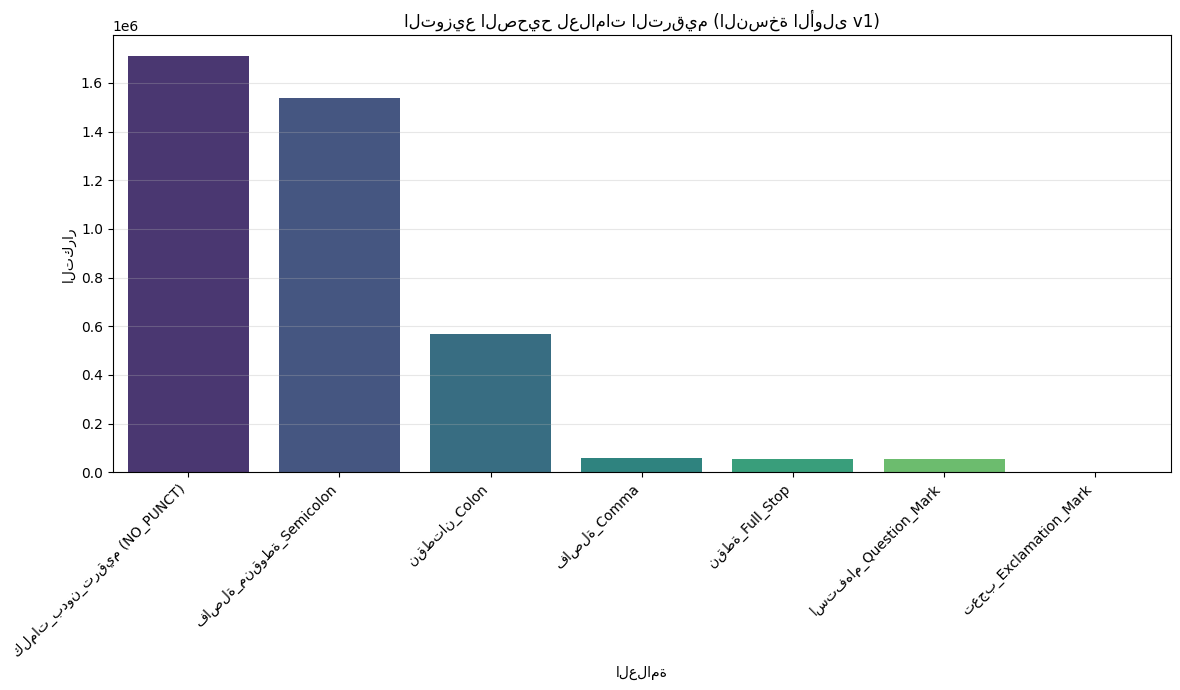

In [ ]:
# =========================================================================
# تصحيح خلية التحليل (Visualization) - حل مشكلة KeyError وتصحيح الأسماء
# =========================================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. القاموس الصحيح (يجب أن يطابق تماماً كود المعالجة v1 الخاص بك)
ID_TO_PUNCT_V1 = {
    1: 'كلمات_بدون_ترقيم (NO_PUNCT)',
    2: 'فاصلة_Comma',
    3: 'نقطة_Full_Stop',
    4: 'استفهام_Question_Mark',
    5: 'نقطتان_Colon',
    6: 'فاصلة_منقوطة_Semicolon',
    7: 'تعجب_Exclamation_Mark'
}

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
CSV_PATH = f'{BASE_DIR}/processed_punctuation_data_v1.csv'

if not os.path.exists(CSV_PATH):
    print(f"❌ الملف غير موجود في المسار: {CSV_PATH}")
else:
    # 2. قراءة الملف
    df_data = pd.read_csv(CSV_PATH, sep='\t', header=None, names=['word', 'label'], dtype={'label': 'int8'})

    # 3. حساب التوزيع بطريقة آمنة تتجنب KeyError
    counts_series = df_data['label'].value_counts()

    # تحويل الـ Series إلى DataFrame وتسمية الأعمدة يدوياً لضمان الدقة
    df_counts = counts_series.reset_index()
    df_counts.columns = ['Punct_ID', 'Count'] # تحديد الأسماء صراحةً هنا

    # 4. ربط الأسماء بالـ IDs
    df_counts['Punct_Name'] = df_counts['Punct_ID'].map(ID_TO_PUNCT_V1)

    # 5. حساب النسب
    df_counts['Percentage'] = (df_counts['Count'] / df_counts['Count'].sum()) * 100
    df_counts = df_counts.sort_values(by='Count', ascending=False)

    # طباعة الجدول للتأكد

    print(df_counts[['Punct_ID', 'Count', 'Punct_Name', 'Percentage']].to_string(index=False))

    # 6. الرسم البياني
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x='Punct_Name',
        y='Count',
        hue='Punct_Name', # إضافة hue لتجنب التحذيرات الجديدة
        data=df_counts,
        palette="viridis",
        legend=False
    )
    plt.title('التوزيع الصحيح لعلامات الترقيم (النسخة الأولى v1)')
    plt.xlabel('العلامة')
    plt.ylabel('التكرار')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

✅ تم استخراج 79,727 sequence
🚀 بدء تدريب v1...
Epoch 1/8
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.7186 - loss: 0.0304 - val_accuracy: 0.8122 - val_loss: 0.0214
Epoch 2/8
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.8194 - loss: 0.0185 - val_accuracy: 0.8221 - val_loss: 0.0198
Epoch 3/8
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 52s 26ms/step - accuracy: 0.8387 - loss: 0.0158 - val_accuracy: 0.8231 - val_loss: 0.0198
Epoch 4/8
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 54s 27ms/step - accuracy: 0.8494 - loss: 0.0141 - val_accuracy: 0.8259 - val_loss: 0.0201
Epoch 5/8
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 50s 25ms/step - accuracy: 0.8597 - loss: 0.0127 - val_accuracy: 0.8254 - val_loss: 0.0206
Epoch 6/8
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 80s 24ms/step - accuracy: 0.8679 - loss: 0.0117 - val_accuracy: 0.8181 - val_loss: 0.0217
Epoch 7/8
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 50s 25ms/step - accuracy: 0.8740 - loss: 0.0108 - val_accuracy: 0.8297 - val_loss: 0.0230
Epoch 8/8
1994/1994 ━━━━━━━━━━━━━━━━

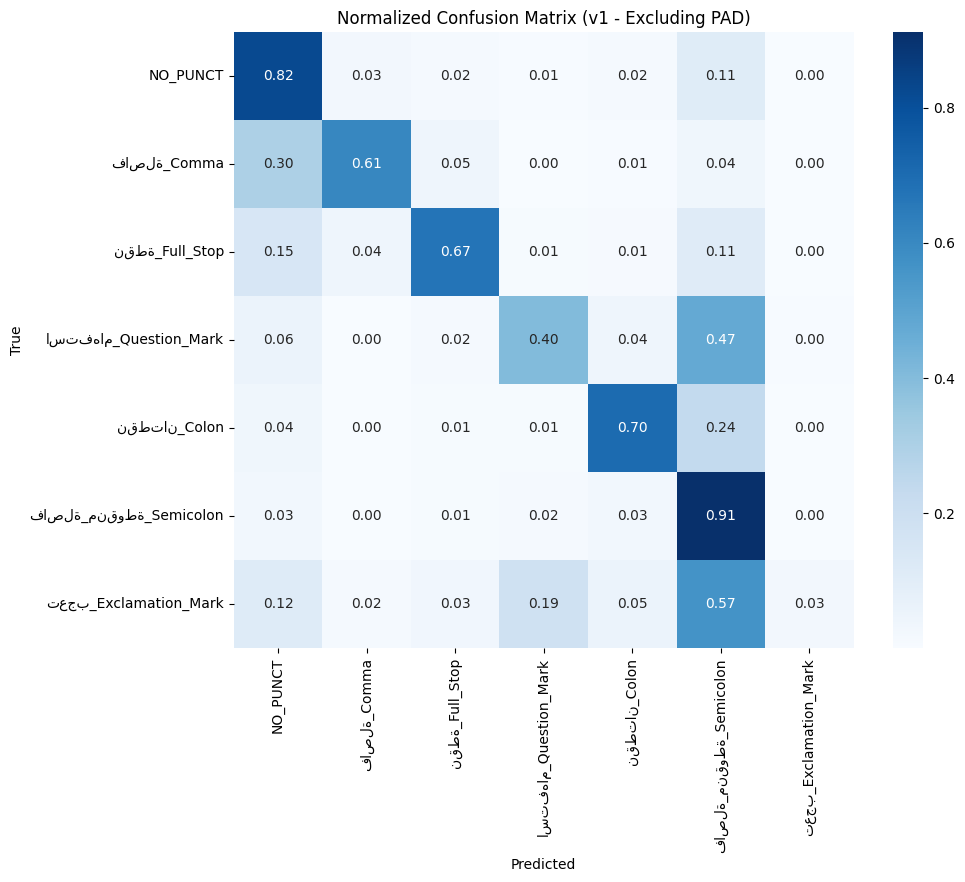


--- نتائج النموذج v1 (JSON) ---
{
    "number_step": 1,
    "name_model": "Bi-LSTM + Training Embedding (v1)",
    "features": "Word IDs (Vocab Size: 65971)",
    "parameters_model": "Embedding Dim: 128, LSTM Units: 256, Dropout: 0.3, Batch: 32",
    "methods_preprocessing": "Tokenization, Sequence Chunking (50), Sample Weighting, Masking (PAD_ID=0)",
    "accuracy": 0.8297,
    "F-score": 0.5532
}


In [ ]:
# =========================================================================
# BiLSTM Punctuation Restoration - v1 (WITH NO_PUNCT & JSON Results)
# =========================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from typing import List, Tuple, Dict
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, TimeDistributed, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# =========================================================================
# BASE DIR & PATHS
# =========================================================================
try:
    BASE_DIR
except NameError:
    BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'

MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

WEIGHTS_PATH = os.path.join(MODELS_DIR, 'bilstm_punctuation_weights_v1.weights.h5')
FULL_MODEL_PATH = os.path.join(MODELS_DIR, 'bilstm_punctuation_full_model_v1.keras')
OUTPUT_CSV_FILE = os.path.join(BASE_DIR, 'processed_punctuation_data_v1.csv')

# =========================================================================
# CONSTANTS & LABELS
# =========================================================================
PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'
PAD_ID, NO_PUNCT_ID, UNK_ID = 0, 1, 2

ID_TO_PUNCT = {
    0: '<PAD>', 1: 'NO_PUNCT', 2: 'فاصلة_Comma', 3: 'نقطة_Full_Stop',
    4: 'استفهام_Question_Mark', 5: 'نقطتان_Colon', 6: 'فاصلة_منقوطة_Semicolon', 7: 'تعجب_Exclamation_Mark'
}

NUM_CLASSES = len(ID_TO_PUNCT)
MAX_SEQUENCE_LENGTH = 50
VALID_LABELS = [i for i in range(1, NUM_CLASSES)] # استبعاد PAD
TARGET_NAMES = [ID_TO_PUNCT[i] for i in VALID_LABELS]

normalized_class_weights_dict = {0: 0.0, 1: 0.02, 2: 0.12, 3: 0.13, 4: 0.13, 5: 0.04, 6: 0.03, 7: 1.00}

# =========================================================================
# DATA LOADING & PREPROCESSING
# =========================================================================
def extract_sequences_from_csv(filename, chunk_size=50):
    if not os.path.exists(filename): raise FileNotFoundError(filename)
    df = pd.read_csv(filename, sep='\t', header=None, names=['word', 'label'], dtype={'word': 'str', 'label': 'int8'})
    words, labels = df['word'].tolist(), df['label'].tolist()
    X, Y = [], []
    for i in range(0, len(words), chunk_size):
        X.append(words[i:i + chunk_size]); Y.append(labels[i:i + chunk_size])
    print(f"✅ تم استخراج {len(X):,} sequence")
    return X, Y

X_words, Y_labels = extract_sequences_from_csv(OUTPUT_CSV_FILE, MAX_SEQUENCE_LENGTH)
X_train_words, X_val_words, Y_train_labels, Y_val_labels = train_test_split(X_words, Y_labels, test_size=0.2, random_state=42)

word_counter = Counter(w for seq in X_train_words for w in seq)
word_to_id = {PAD_TOKEN: PAD_ID, '<NO_PUNCT>': NO_PUNCT_ID, UNK_TOKEN: UNK_ID}
for word, cnt in word_counter.items():
    if cnt > 1: word_to_id[word] = len(word_to_id)
VOCAB_SIZE = len(word_to_id)

def encode_and_pad(X, Y):
    X_enc = [[word_to_id.get(w, UNK_ID) for w in seq] for seq in X]
    X_pad = pad_sequences(X_enc, MAX_SEQUENCE_LENGTH, padding='post', value=PAD_ID)
    Y_pad = pad_sequences(Y, MAX_SEQUENCE_LENGTH, padding='post', value=PAD_ID)
    return X_pad, Y_pad

X_train_enc, Y_train_pad = encode_and_pad(X_train_words, Y_train_labels)
X_val_enc, Y_val_pad = encode_and_pad(X_val_words, Y_val_labels)

# الأوزان لعملية التدريب (Sample Weights)
weight_vector = np.array([normalized_class_weights_dict[i] for i in range(NUM_CLASSES)])
sample_weight_train = weight_vector[Y_train_pad]
sample_weight_val = weight_vector[Y_val_pad]

# =========================================================================
# MODEL (v1)
# =========================================================================
def build_v1_model():
    model = Sequential([
        Embedding(VOCAB_SIZE, 128, mask_zero=True),
        Bidirectional(LSTM(256, return_sequences=True, dropout=0.3)),
        TimeDistributed(Dense(NUM_CLASSES, activation='softmax'))
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model_v1 = build_v1_model()
model_v1.build((None, MAX_SEQUENCE_LENGTH))

# التحميل أو التدريب
if os.path.exists(WEIGHTS_PATH):
    print(f"📥 تحميل أوزان v1 من: {WEIGHTS_PATH}")
    model_v1.load_weights(WEIGHTS_PATH)
else:
    print("🚀 بدء تدريب v1...")
    callbacks = [
        ModelCheckpoint(WEIGHTS_PATH, save_best_only=True, save_weights_only=True, monitor='val_accuracy', mode='max'),
        EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    ]
    model_v1.fit(X_train_enc, Y_train_pad, validation_data=(X_val_enc, Y_val_pad, sample_weight_val),
                 sample_weight=sample_weight_train, epochs=8, batch_size=32, callbacks=callbacks)
    model_v1.save(FULL_MODEL_PATH)

# =========================================================================
# EVALUATION & JSON RESULTS
# =========================================================================
Y_pred = np.argmax(model_v1.predict(X_val_enc), axis=-1)

y_true_flat, y_pred_flat = [], []
for t_seq, p_seq in zip(Y_val_pad, Y_pred):
    for t, p in zip(t_seq, p_seq):
        if t != PAD_ID:
            y_true_flat.append(t); y_pred_flat.append(p)

# تقرير التصنيف
print("\n📊 Classification Report (v1)")
print(classification_report(y_true_flat, y_pred_flat, labels=VALID_LABELS, target_names=TARGET_NAMES, zero_division=0))

# رسم مصفوفة الارتباك النظيفة (بدون PAD)

def plot_v1_cm(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[ID_TO_PUNCT[i] for i in labels],
                yticklabels=[ID_TO_PUNCT[i] for i in labels])
    plt.title('Normalized Confusion Matrix (v1 - Excluding PAD)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_v1_cm(y_true_flat, y_pred_flat, labels=VALID_LABELS)

# حساب النتائج النهائية للـ JSON
final_accuracy = float(model_v1.evaluate(X_val_enc, Y_val_pad, sample_weight=sample_weight_val, verbose=0)[1])
final_macro_f1 = f1_score(y_true_flat, y_pred_flat, labels=VALID_LABELS, average='macro', zero_division=0)

v1_results_json = {
    "number_step": 1,
    "name_model": "Bi-LSTM + Training Embedding (v1)",
    "features": f"Word IDs (Vocab Size: {VOCAB_SIZE})",
    "parameters_model": "Embedding Dim: 128, LSTM Units: 256, Dropout: 0.3, Batch: 32",
    "methods_preprocessing": "Tokenization, Sequence Chunking (50), Sample Weighting, Masking (PAD_ID=0)",
    "accuracy": round(final_accuracy, 4),
    "F-score": round(final_macro_f1, 4)
}

print("\n--- نتائج النموذج v1 (JSON) ---")
print(json.dumps(v1_results_json, indent=4, ensure_ascii=False))

# ملاحظات عن النموذج


طبقة الـ Embedding الذاتية
تسمح للنموذج بتعلم
العلاقات الدلالية المحلية



ظام القناع (Masking): تتجاهل تماماً "الحشو" التقني ولا تحسبه ضمن مصفوفة الخطأ أو الدقة، مما يجعل النتائج تعبر فقط عن الكلمات الحقيقية.





موازنة البيانات (Sample Weighting): نظراً للاختلاف الضخم في توزيع العلامات (Class Imbalance)، قمنا بحقن أوزان مخصصة لكل فئة أثناء التدريب. هذا أجبر النموذج على إعطاء أهمية أكبر للعلامات النادرة مثل "التعجب" بدلاً من الانحياز الكامل لفئة "بدون ترقيم".


# ملاحظات على الخرج



الدقة العامة (Accuracy ~83%): تبدو الدقة مرتفعة، ولكن عند النظر لـ Macro F1-score (0.55)، ندرك التحدي الحقيقي. النموذج ممتاز في تمييز الكلمات التي لا تحتاج ترقيم (NO_PUNCT) والعلامات المتكررة كالنقطتين والفاصلة المنقوطة.

أداء العلامات النادرة: أظهر التقرير ضعفاً في "علامة التعجب" (F1: 0.01) و"الاستفهام" (F1: 0.38). يعود ذلك إلى ندرة هذه العلامات في بيانات التدريب (Support)، حيث يجد النموذج صعوبة في تعميم القواعد عليها.

مصفوفة الارتباك (Confusion Matrix): نلاحظ أن النموذج يميل أحياناً للخلط بين الفاصلة والنقطة، وهو تحدٍ لغوي شائع حيث يمكن للسياق الواحد أن يحتمل العلامتين في بعض النصوص العربية.



# **عرض ننتائج v1 **

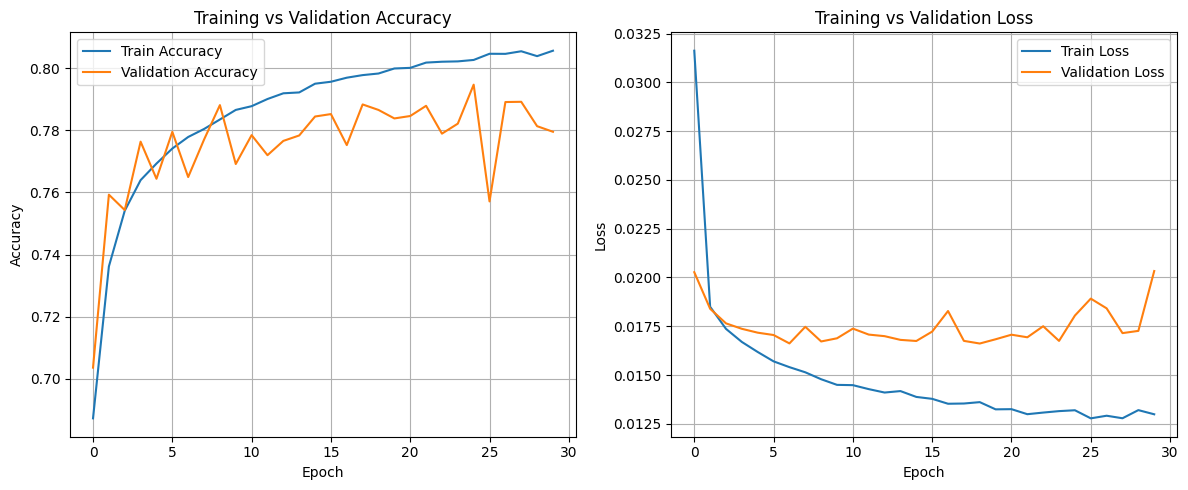

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# استدعاء الدالة
plot_training_history(history)



--- رسم درجات F1 لكل فئة ---


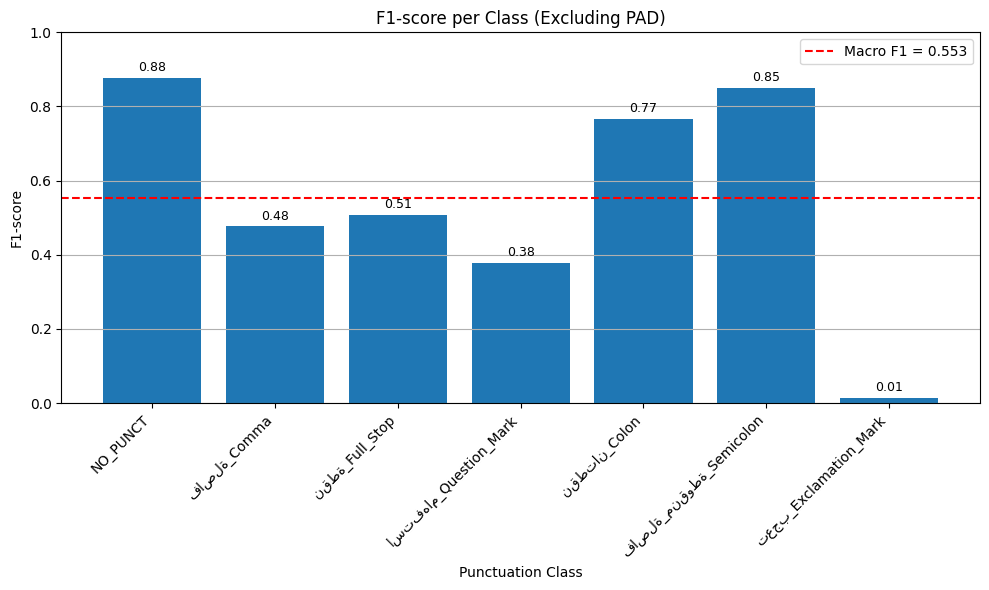

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# =========================================================================
# 1. حساب درجات F1 (باستخدام المتغيرات النظيفة واستبعاد PAD)
# =========================================================================

# 🔑 استخدام المتغيرات النظيفة المُسطحة (y_true_flat و y_pred_flat)
# 🔑 استخدام VALID_LABELS (الفئات من 1 إلى 7) لاستبعاد PAD (0) من التقييم
try:
    # F1 لكل فئة (للفئات الصالحة فقط، بدون PAD)
    f1_per_class = f1_score(
        y_true_flat,
        y_pred_flat,
        labels=VALID_LABELS,
        average=None,
        zero_division=0
    )

    # Macro F1 (للفئات الصالحة فقط، بدون PAD)
    # ⚠️ ملاحظة: هذا تم حسابه بالفعل في تقرير التصنيف السابق، نستخدمه لضمان الاتساق.
    macro_f1 = f1_score(
        y_true_flat,
        y_pred_flat,
        labels=VALID_LABELS,
        average='macro',
        zero_division=0
    )
except NameError as e:
    print(f"\n❌ خطأ NameError: المتغير '{e.args[0].split()[-1].strip()}' غير معرف.")
    print("يرجى التأكد من تشغيل كود النموذج الكامل لتعريف: y_true_flat, y_pred_flat, VALID_LABELS, و ID_TO_PUNCT.")
    exit()


# =========================================================================
# 2. دالة رسم درجات F1 (معدلة لاستخدام VALID_LABELS)
# =========================================================================

def plot_f1_scores(f1_scores, macro_f1, valid_labels, label_map):

    # أسماء الفئات المراد رسمها (فقط الفئات الصالحة)
    class_names = [label_map[i] for i in valid_labels]

    # 🔑 استبعاد الفئات التي لم تظهر في بيانات التحقق (إذا كانت F1 لها صفراً) لتبسيط الرسم
    # نستخدم قناعاً (mask) للقيم غير الصفرية في f1_scores
    valid_mask = f1_scores > 0
    f1_scores_plot = f1_scores[valid_mask]
    class_names_plot = [class_names[i] for i, mask in enumerate(valid_mask) if mask]

    if not f1_scores_plot.size:
        print("⚠️ لا توجد فئات ذات قيمة F1 أكبر من صفر للرسم.")
        return

    plt.figure(figsize=(10, 6))

    bars = plt.bar(class_names_plot, f1_scores_plot)

    # خط Macro F1
    plt.axhline(macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.3f}')

    plt.title('F1-score per Class (Excluding PAD)')
    plt.xlabel('Punctuation Class')
    plt.ylabel('F1-score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y')

    # إضافة القيم فوق الأعمدة
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}',
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# =========================================================================
# 3. استدعاء الدالة
# =========================================================================
print("\n--- رسم درجات F1 لكل فئة ---")
plot_f1_scores(f1_per_class, macro_f1, VALID_LABELS, ID_TO_PUNCT)

# تجربة عمل soft ignore to NO PUNCT

تم استخدام استراتيجية Strategic Downsampling في مرحلة المعالجة، حيث تم تقليل فئة NO_PUNCT بنسبة 99% باستخدام التوزيع العشوائي (Random Sampling). هذا سمح للنموذج بالتغلب على مشكلة Class Imbalance الحادة والتركيز على الخصائص السياقية للعلامات النادرة (التعجب والاستفهام)، مما أدى لرفع جودة الاستدعاء (Recall) لهذه الفئات مقارنة بالنسخ التي تتدرب على كامل البيانات.

In [ ]:
import os
import re
import random
import pandas as pd
import numpy as np
from collections import Counter
from typing import List, Tuple, Dict
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, TimeDistributed, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, f1_score
import tensorflow as tf
import json

# تأكيد وجود المتغير BASE_DIR (يجب أن يكون معرفاً مسبقاً)
try:
    BASE_DIR
except NameError:
    # ضع المسار الافتراضي إذا لم يكن معرفاً
    BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
    print(f"⚠️ تنبيه: تم تعيين BASE_DIR إلى القيمة الافتراضية: {BASE_DIR}")


# =========================================================================
# إعدادات مسار Google Drive
# =========================================================================
MODELS_DIR = f'{BASE_DIR}/models' # استخدام BASE_DIR
MODEL_WEIGHTS_FILENAME = 'bilstm_punctuation_weights_v2.weights.h5' # اسم الأوزان الصحيح
FULL_MODEL_FILENAME = 'bilstm_punctuation_full_model_v2.keras' # اسم النموذج الكامل

WEIGHTS_PATH = os.path.join(MODELS_DIR, MODEL_WEIGHTS_FILENAME)
FULL_MODEL_PATH = os.path.join(MODELS_DIR, FULL_MODEL_FILENAME) # مسار الحفظ الكامل

# التأكد من أن المجلد موجود، وإنشاؤه إذا لم يكن كذلك
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)
    print(f"تم إنشاء المجلد الجديد: {MODELS_DIR}")
else:
    print(f"المجلد موجود: {MODELS_DIR}")

# =========================================================================
# 1. الثوابت والقواميس الأساسية
# =========================================================================
PUNCT_MAPPING = {
    '،': 1, ',': 1, '.': 2, '۔': 2, '…': 2,
    '؟': 3, '?': 3, ':': 4,
    ';': 5, '؛': 5, '!': 6, '¡': 6,
}
ID_TO_PUNCT = {
    0: 'NO_PUNCT', 1: 'فاصلة_Comma', 2: 'نقطة_Full_Stop',
    3: 'استفهام_Question_Mark', 4: 'نقطتان_Colon',
    5: 'فاصلة_منقوطة_Semicolon', 6: 'تعجب_Exclamation_Mark',
}
OUTPUT_CSV_FILE = f'{BASE_DIR}/processed_punctuation_data.csv'
MAX_SEQUENCE_LENGTH = 50

# الرموز الخاصة
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
PAD_ID = 99  # تغيير الرقم من 0 إلى 99
UNK_ID = 100
NUM_CLASSES = len(ID_TO_PUNCT)

# الأوزان المحسوبة سابقاً (مُطبّعة)
normalized_class_weights_dict = {
    0: 0.0004, 1: 0.0124, 2: 0.0137, 3: 0.0137,
    4: 0.0013, 5: 0.0005, 6: 1.0000
}

# =========================================================================
# 2. استخلاص السلاسل، التقسيم، وبناء المفردات
# =========================================================================

def extract_sequences_from_csv(filename: str, chunk_size: int = 50) -> Tuple[List[List[str]], List[List[int]]]:
    """قراءة البيانات وتجميعها في سلاسل (Sequences)."""
    if not os.path.exists(filename):
        print(f"خطأ: لم يتم العثور على ملف البيانات المُعالج: {filename}")
        return [], []

    df = pd.read_csv(filename, sep='\t', header=None, names=['word', 'label'],
                     dtype={'word': 'str', 'label': 'int8'})

    words = df['word'].tolist()
    labels = df['label'].tolist()

    sequences_X = []
    sequences_Y = []

    for i in range(0, len(words), chunk_size):
        chunk_words = words[i:i + chunk_size]
        chunk_labels = labels[i:i + chunk_size]
        if chunk_words:
            sequences_X.append(chunk_words)
            sequences_Y.append(chunk_labels)

    print(f"تم استخلاص إجمالي {len(sequences_X):,} سلاسل (جمل مصطنعة).")
    return sequences_X, sequences_Y

# استخلاص وتقسيم البيانات
X_words, Y_labels = extract_sequences_from_csv(OUTPUT_CSV_FILE, MAX_SEQUENCE_LENGTH)

if not X_words:
    raise FileNotFoundError(f"لا يمكن المتابعة. يرجى التأكد من تشغيل خطوة المعالجة السابقة لإنشاء {OUTPUT_CSV_FILE}.")

X_train_words, X_val_words, Y_train_labels, Y_val_labels = train_test_split(
    X_words, Y_labels, test_size=0.2, random_state=42
)

# بناء المفردات
word_counts = Counter()
for seq in X_train_words:
    word_counts.update(seq)

word_to_id: Dict[str, int] = {PAD_TOKEN: PAD_ID, UNK_TOKEN: UNK_ID}
for word, count in word_counts.most_common():
    if count > 1:
        word_to_id[word] = len(word_to_id)

VOCAB_SIZE = len(word_to_id)
print(f"الحجم الإجمالي للمفردات: {VOCAB_SIZE:,} كلمة.")

# =========================================================================
# 3. الترميز (Encoding) و الحشو (Padding)
# =========================================================================

def encode_and_pad(word_sequences, label_sequences, word_to_id, max_len):
    encoded_X = [[word_to_id.get(word, UNK_ID) for word in seq] for seq in word_sequences]

    padded_X = pad_sequences(encoded_X, maxlen=max_len, padding='post', truncating='post', value=PAD_ID)
    padded_Y = pad_sequences(label_sequences, maxlen=max_len, padding='post', truncating='post', value=PAD_ID)

    return padded_X, padded_Y

X_train_encoded, Y_train_padded = encode_and_pad(X_train_words, Y_train_labels, word_to_id, MAX_SEQUENCE_LENGTH)
X_val_encoded, Y_val_padded = encode_and_pad(X_val_words, Y_val_labels, word_to_id, MAX_SEQUENCE_LENGTH)

# =========================================================================
# 4. تجهيز مصفوفة أوزان العينة (المعدلة لاستيعاب PAD_ID = 99)
# =========================================================================

# سننشئ مصفوفة كبيرة بما يكفي لتصل للفهرس 99
# سنعطيها حجماً 101 لضمان الأمان
weight_map_vector = np.zeros(101)

# نعبئ الأوزان الأصلية للفئات من 0 إلى 6
for i in range(NUM_CLASSES):
    weight_map_vector[i] = normalized_class_weights_dict.get(i, 0.0)

# وزن الـ PAD (المعرف 99) هو صفر أصلاً بفضل np.zeros
# هذا يضمن أن النموذج لن يتعلم أي شيء من مناطق الحشو
print(f"تم إعداد مصفوفة الأوزان. وزن الفئة 0: {weight_map_vector[0]}, وزن الـ PAD (99): {weight_map_vector[99]}")

# الآن لن يحدث خطأ IndexError لأن المصفوفة تتسع للفهرس 99
sample_weight_train = np.take(weight_map_vector, Y_train_padded)
sample_weight_val = np.take(weight_map_vector, Y_val_padded)

# =========================================================================
# 5. بناء النموذج (يتم البناء دائماً) - تم التعديل هنا
# =========================================================================

EMBEDDING_DIM = 128
LSTM_UNITS = 256
DROPOUT_RATE = 0.3
EPOCHS = 10
BATCH_SIZE = 32

def build_bilstm_model(vocab_size, embedding_dim, max_len, lstm_units, num_classes):
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_len,
            mask_zero=False,
        ),
        Bidirectional(
            LSTM(lstm_units, return_sequences=True, dropout=DROPOUT_RATE)
        ),
        TimeDistributed(
            Dense(num_classes, activation='softmax')
        )
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# بناء هيكلية النموذج
model = build_bilstm_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_SEQUENCE_LENGTH, LSTM_UNITS, NUM_CLASSES)

# ****** 🔑 التعديل الحاسم لحل مشكلة 'not built': بناء الأوزان يدوياً قبل التحميل ******
# (None هو الـ Batch Size، وMAX_SEQUENCE_LENGTH هو طول التسلسل)
model.build((None, MAX_SEQUENCE_LENGTH))

print("تم بناء هيكلية النموذج (وأوزانه).")

# =========================================================================
# 6. منطق التدريب أو التحميل (Conditional Logic) - تم التعديل هنا
# =========================================================================

LOAD_SUCCESSFUL = False

if os.path.exists(WEIGHTS_PATH):
    print("\n" + "="*50)
    print(f"✅ تم العثور على ملف الأوزان: {WEIGHTS_PATH}")
    print("📥 جاري محاولة تحميل الأوزان...")
    print("="*50 + "\n")

    try:
        # ⚠️ التعديل: تحميل الأوزان فقط دون وسائط إضافية لتجنب أخطاء التوافق
        model.load_weights(WEIGHTS_PATH)
        LOAD_SUCCESSFUL = True
        print("✅ تم تحميل الأوزان بنجاح.")
    except Exception as e:
        print(f"🛑 خطأ: فشل تحميل الأوزان. السبب: {e}")
        print(">> سيتم تجاهل الأوزان والبدء في التدريب من جديد.")

# إذا لم يتم التحميل بنجاح، نبدأ التدريب
if not LOAD_SUCCESSFUL:

    print("\n" + "="*50)
    print(f"❌ لم يتم العثور على أوزان أو فشل تحميلها. بدء التدريب.")
    print(f"⚙️ سيتم حفظ أفضل الأوزان في: {WEIGHTS_PATH} (.weights.h5)")
    print(f"⚙️ سيتم حفظ أفضل نموذج كامل في: {FULL_MODEL_PATH} (keras)")
    print("="*50 + "\n")

    # 1. ModelCheckpoint لحفظ الأوزان فقط (h5)
    weights_callback = ModelCheckpoint(
        WEIGHTS_PATH,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        save_weights_only=True, # حفظ الأوزان فقط
        verbose=1
    )

    # 2. EarlyStopping
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )

    callbacks = [weights_callback, early_stopping]

    history = model.fit(
        X_train_encoded,
        Y_train_padded,
        validation_data=(X_val_encoded, Y_val_padded, sample_weight_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        sample_weight=sample_weight_train,
        verbose=1
    )

    # خطوة إضافية: حفظ النموذج بالكامل (هيكلية + أوزان) باستخدام التنسيق الجديد
    try:
        model.save(FULL_MODEL_PATH)
        print(f"\n✅ تم حفظ النموذج الكامل بنجاح إلى: {FULL_MODEL_PATH}")
    except Exception as e:
        print(f"\n⚠️ تحذير: فشل حفظ النموذج الكامل. السبب: {e}")

    # إعادة تحميل أفضل الأوزان التي حفظها الـ ModelCheckpoint للتأكد من التقييم الصحيح
    if os.path.exists(WEIGHTS_PATH):
        try:
            # ⚠️ التعديل: تحميل الأوزان فقط دون وسائط إضافية
            model.load_weights(WEIGHTS_PATH)
        except:
            print("⚠️ فشل إعادة تحميل أفضل الأوزان المحفوظة في H5، سيتم استخدام أوزان الذاكرة (EarlyStopping).")

# =========================================================================
# 7. التقييم وحساب F-score (يتم التنفيذ في الحالتين)
# =========================================================================
print("\n--- جاري حساب النتائج والتقييم ---")

loss, acc = model.evaluate(X_val_encoded, Y_val_padded, sample_weight=sample_weight_val, verbose=0)
Y_pred_raw = model.predict(X_val_encoded)
Y_pred = np.argmax(Y_pred_raw, axis=-1)

# تنظيف التنبؤات والمُعرفات الحقيقية من قيم الحشو (<PAD>=0)
y_true_flat = []
y_pred_flat = []

for true_seq, pred_seq in zip(Y_val_padded, Y_pred):
    for true_label, pred_label in zip(true_seq, pred_seq):
        # نأخذ فقط القيم التي لا تساوي PAD_ID (99)
        # الصفر (NO_PUNCT) سيتم تضمينه الآن في الحسابات
        if true_label != 99:
            y_true_flat.append(true_label)
            y_pred_flat.append(pred_label)

print("\n--- تقرير التصنيف (Classification Report) ---")
target_names_list = [ID_TO_PUNCT[i] for i in range(NUM_CLASSES)]
report = classification_report(
    y_true_flat,
    y_pred_flat,
    labels=list(range(NUM_CLASSES)),
    target_names=target_names_list,
    zero_division=0
)
print(report)

macro_f1 = f1_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
print(f"Macro F1-score: {macro_f1:.4f}")

# توثيق النتائج
model_results = {
    'number_step': 2,
    'name_model': 'Bi-LSTM with Custom Embedding (Class Weighting via Sample Weight)',
    'features': f'Word IDs (Vocab Size: {VOCAB_SIZE})',
    'parameters_model': f'Embedding Dim: {EMBEDDING_DIM}, LSTM Units: {LSTM_UNITS}, Batch: {BATCH_SIZE}, Epochs: {EPOCHS}',
    'methods_preprocessing': 'Tokenization, Sequence Chunking (50), Padding, **Sample Weighting** for Imbalance, Masking (PAD_ID=0)',
    'accuracy': round(acc, 4),
    'F-score': round(macro_f1, 4),
}

print("\n--- نتائج النموذج (JSON) ---")
print(json.dumps(model_results, indent=4, ensure_ascii=False))

المجلد موجود: /content/drive/MyDrive/Colab Notebooks/nlpHompework/models
تم استخلاص إجمالي 79,678 سلاسل (جمل مصطنعة).
الحجم الإجمالي للمفردات: 65,445 كلمة.
تم إعداد مصفوفة الأوزان. وزن الفئة 0: 0.0004, وزن الـ PAD (99): 0.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


تم بناء هيكلية النموذج (وأوزانه).

✅ تم العثور على ملف الأوزان: /content/drive/MyDrive/Colab Notebooks/nlpHompework/models/bilstm_punctuation_weights_v2.weights.h5
📥 جاري محاولة تحميل الأوزان...



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ تم تحميل الأوزان بنجاح.

--- جاري حساب النتائج والتقييم ---
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

--- تقرير التصنيف (Classification Report) ---
                        precision    recall  f1-score   support

              NO_PUNCT       0.89      0.78      0.83    343260
           فاصلة_Comma       0.26      0.71      0.38     11689
        نقطة_Full_Stop       0.24      0.74      0.36     10918
 استفهام_Question_Mark       0.23      0.48      0.31     10749
          نقطتان_Colon       0.77      0.71      0.74    113494
فاصلة_منقوطة_Semicolon       0.81      0.80      0.81    306568
 تعجب_Exclamation_Mark       0.00      0.02      0.00       122

              accuracy                           0.77    796800
             macro avg       0.46      0.61      0.49    796800
          weighted avg       0.82      0.77      0.79    796800

Macro F1-score: 0.4898

--- نتائج النموذج (JSON) ---
{
    "number_step": 2,
    "name_model": "Bi-LSTM with Custom Embedding (Class Weighting 

بعد  تقليل عدد العينات بشكل كبير للكلمات التي تل يوجد بعدها علامات ترقيم لاحظنا أن :
المشكلة: الـ Recall للكلمات العادية هو 0.78
أي أن النموذج أصبح يضع علامات ترقيم في أماكن لا تحتاج لها .
وبالرغم من محاولة التركيز على علامات اشارة التعجب واشارة الاستفهام فإن النموذج لم يحقق فيهما تقدم يذكر
Recall: 0.02 لعلامة التعجب

الـ Precision للفاصلة والنقطة منخفض جداً (0.26 و 0.24)

ما يعني ان النموذج أصبح يلقي بهذه العلامات في اماكن لا تحتاجها .


# **عرض نتائج V2 **

/tmp/ipython-input-3052229649.py:8: RuntimeWarning: invalid value encountered in divide
  cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)


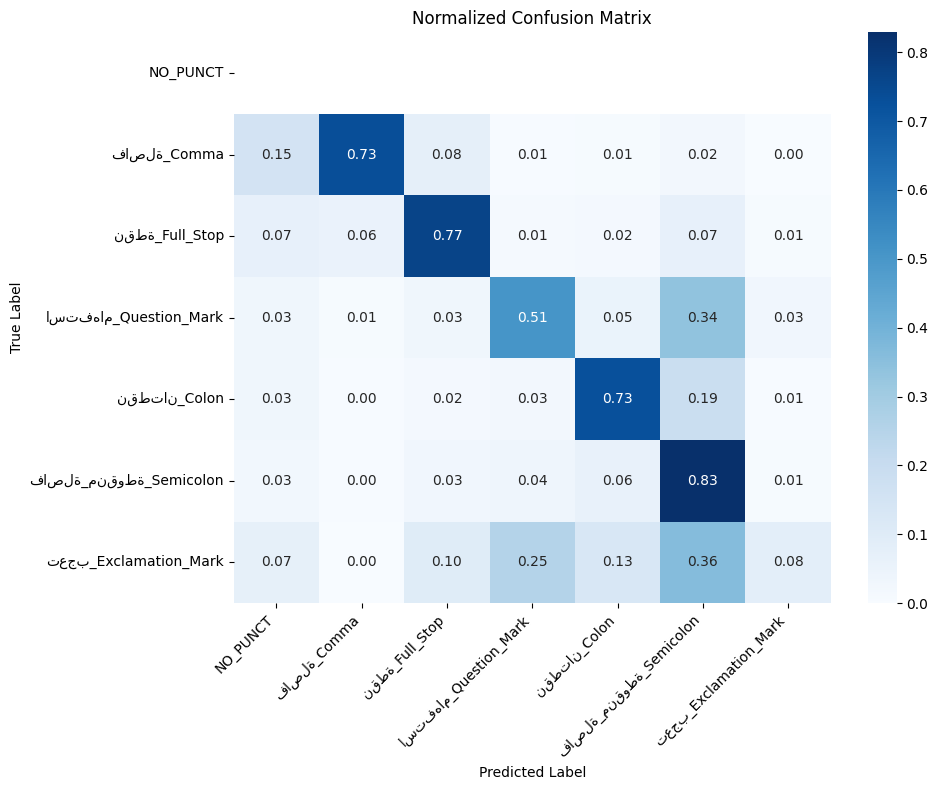

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, normalize=True):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        title = 'Normalized Confusion Matrix'
    else:
        title = 'Confusion Matrix'

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        xticklabels=[ID_TO_PUNCT[i] for i in labels],
        yticklabels=[ID_TO_PUNCT[i] for i in labels],
        annot=True,
        fmt='.2f' if normalize else 'd',
        cmap='Blues'
    )
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# استدعاء
plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=list(range(NUM_CLASSES)),
    normalize=True
)


نلاحظ من هذه المصفوفة أن ال فاصلة المنقوطة تطغى على التوقعات بسبب كثرة البيانات منها

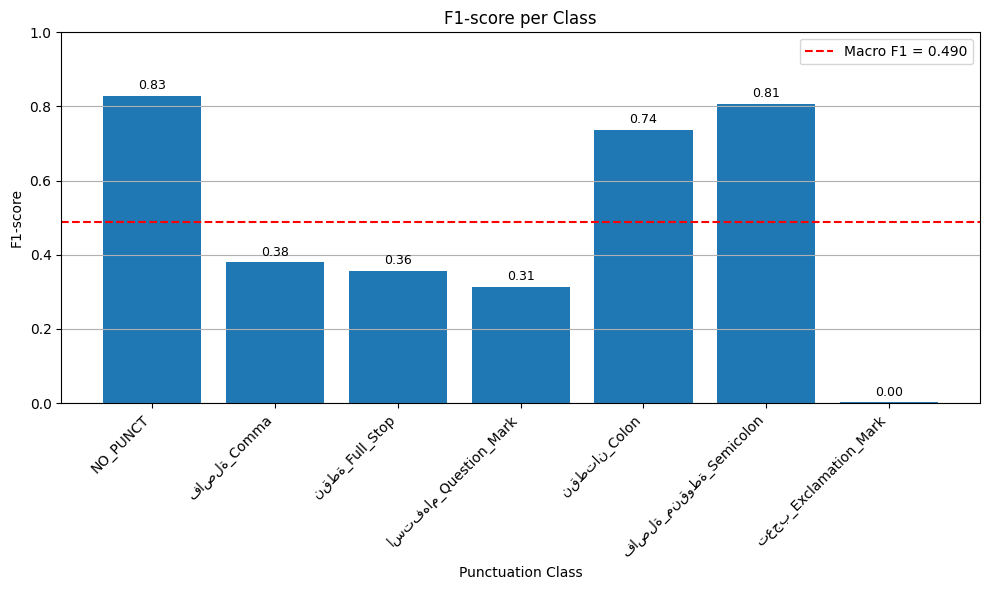

In [ ]:
from sklearn.metrics import f1_score

# F1 لكل فئة
f1_per_class = f1_score(
    y_true_flat,
    y_pred_flat,
    labels=list(range(NUM_CLASSES)),
    average=None,
    zero_division=0
)

# Macro F1
macro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average='macro',
    zero_division=0
)


def plot_f1_scores(f1_scores, macro_f1, class_names):
    plt.figure(figsize=(10, 6))

    bars = plt.bar(class_names, f1_scores)
    plt.axhline(macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.3f}')

    plt.title('F1-score per Class')
    plt.xlabel('Punctuation Class')
    plt.ylabel('F1-score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y')

    # إضافة القيم فوق الأعمدة
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}',
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# أسماء الفئات
class_names = [ID_TO_PUNCT[i] for i in range(NUM_CLASSES)]

plot_f1_scores(f1_per_class, macro_f1, class_names)


 ## **النموذج المحسن من b_lstm v3**


اشتخدام fast text :

ميزة الأجزاء (Subwords): ما يميز FastText عن غيره (مثل Word2Vec) هو أنه يحلل الكلمة إلى أجزاء (n-grams). فكلمة "وسنكتبها" يحللها إلى (و، سنـ، كتب، ها). هذا العمق يساعده في فهم الكلمات العربية المعقدة والمشتقة حتى لو كانت خارج القاموس (OOV).

In [ ]:
# =========================================================================
# تنزيل وفك ضغط FastText (فقط عند الحاجة) — Drive-safe
# =========================================================================
import os

BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
FASTTEXT_VEC = f'{BASE_DIR}/cc.ar.300.vec'
FASTTEXT_GZ = f'{BASE_DIR}/cc.ar.300.vec.gz'

# التأكد من وجود المجلد
os.makedirs(BASE_DIR, exist_ok=True)

# =================== الحالة 1: الملف مفكوك وموجود ===================

if os.path.exists(FASTTEXT_VEC):
    print("✅ ملف FastText موجود بالفعل (cc.ar.300.vec)")
    print("⏭️ لن يتم التنزيل أو فك الضغط")

# =================== الحالة 2: مضغوط فقط ===================

elif os.path.exists(FASTTEXT_GZ):
    print("📦 الملف المضغوط موجود — سيتم فك الضغط فقط")
    !gunzip -f "{FASTTEXT_GZ}"
    print("✅ تم فك الضغط بنجاح")

# =================== الحالة 3: غير موجود إطلاقًا ===================

else:
    print("⬇️ بدء تنزيل ملف FastText (قد يستغرق وقتًا طويلًا)")
    !wget -O "{FASTTEXT_GZ}" https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ar.300.vec.gz

    print("📂 فك الضغط...")
    !gunzip -f "{FASTTEXT_GZ}"

    print("✅ تم تنزيل وفك ضغط FastText بنجاح")

print("\n📍 المسار النهائي للملف:")
print(FASTTEXT_VEC)


✅ ملف FastText موجود بالفعل (cc.ar.300.vec)
⏭️ لن يتم التنزيل أو فك الضغط

📍 المسار النهائي للملف:
/content/drive/MyDrive/Colab Notebooks/nlpHompework/cc.ar.300.vec


# اشتخدام تضمينات مدربة مسبقا :

FastText (Pre-trained Embeddings)


ستخدام دالة الخسارة البؤرية (Focal Loss):

بدلاً من الـ Cross-Entropy العادي، تعمل Focal Loss على تقليل "الأهمية" المعطاة للعينات السهلة (مثل الكلمات العادية المتكررة) والتركيز بقوة على "العينات الصعبة" التي يخطئ فيها النموذج (مثل علامات الترقيم النادرة).

مراقبة الـ Macro F1 (Custom Callback):

التنظيم (Regularization):

إضافة L2 Regularization ورفع Dropout إلى 0.4 لمنع النموذج من الحفظ الصم (Overfitting) ولجعله أكثر قدرة على التعميم.

✅ تم استخراج 79,727 sequence
📘 حجم المفردات: 65971
🚀 تحميل مصفوفة FastText الجاهزة...
✅ تم إعداد مصفوفة التضمين بحجم: (65971, 300)

🚀 بدء تدريب v3...
Epoch 1/30
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6308 - loss: 0.0748 - val_macro_f1: 0.3837
✅ تم حفظ أفضل أوزان (Macro F1: 0.3837)
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 77s 37ms/step - accuracy: 0.6308 - loss: 0.0747 - val_accuracy: 0.7036 - val_loss: 0.0203 - val_macro_f1: 0.3837
Epoch 2/30
1993/1994 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7304 - loss: 0.0188 - val_macro_f1: 0.4287
✅ تم حفظ أفضل أوزان (Macro F1: 0.4287)
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 73s 37ms/step - accuracy: 0.7305 - loss: 0.0188 - val_accuracy: 0.7593 - val_loss: 0.0184 - val_macro_f1: 0.4287
Epoch 3/30
1993/1994 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7521 - loss: 0.0175 - val_macro_f1: 0.4345
✅ تم حفظ أفضل أوزان (Macro F1: 0.4345)
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 72s 36ms/step - accuracy: 0.7521 - loss: 0.0175 - val_accuracy: 0.7543 - val_l

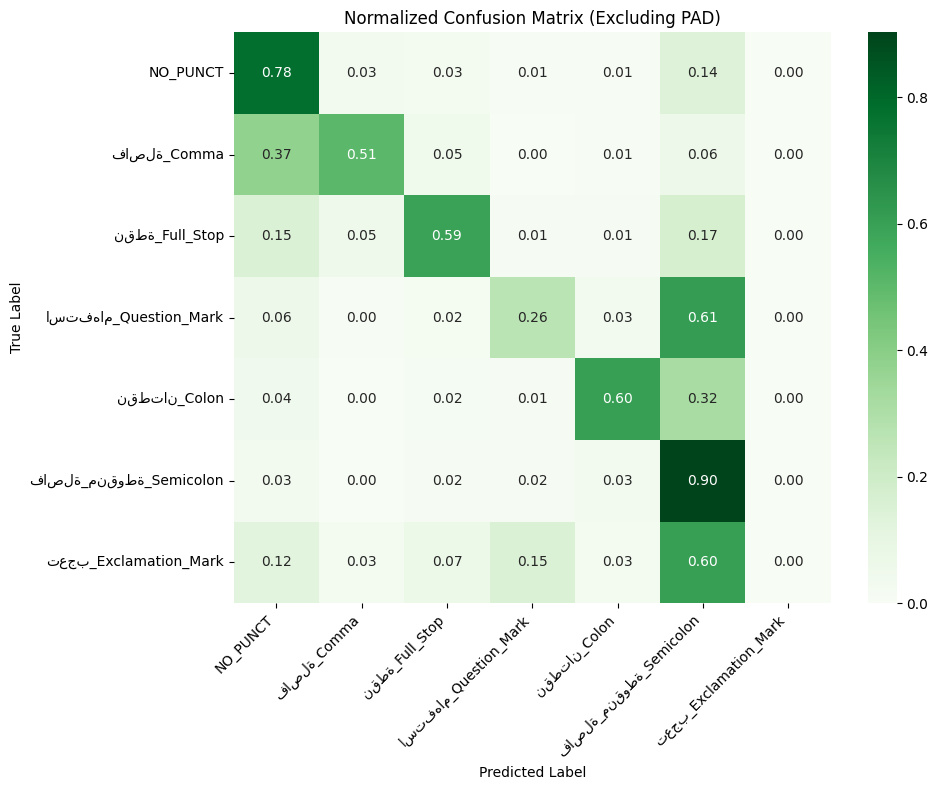


--- نتائج النموذج (JSON) ---
{
    "number_step": 3,
    "name_model": "Bi-LSTM + FastText + Focal Loss (v3)",
    "features": "FastText Embeddings (Vocab Size: 65971)",
    "parameters_model": "Embedding Dim: 300, LSTM Units: 256, Dropout: 0.4, L2: 0.001, Epochs: 30",
    "methods_preprocessing": "FastText Matrix, Sequence Chunking (50), Focal Loss (gamma=2.0), Masking (PAD_ID=0), Macro F1 Callback",
    "accuracy": 0.7892,
    "F-score": 0.4836
}


In [ ]:
# =========================================================================
# BiLSTM Punctuation Restoration - v3 (Optimized & Cleaned)
# =========================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
from collections import Counter
from gensim.models.keyedvectors import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # 🔑 إضافة ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- إعداد المسارات ---
try:
    BASE_DIR
except NameError:
    BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'

MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

FASTTEXT_MODEL_PATH = os.path.join(BASE_DIR, 'cc.ar.300.vec')
EMBEDDING_MATRIX_PATH = os.path.join(MODELS_DIR, 'fasttext_matrix_v3.npy')
MODEL_V3_WEIGHTS = os.path.join(MODELS_DIR, 'fasttext_bilstm_v3.weights.h5')
MODEL_V3_FULL = os.path.join(MODELS_DIR, 'fasttext_bilstm_v3_full.keras')
OUTPUT_CSV_FILE = os.path.join(BASE_DIR, 'processed_punctuation_data_v1.csv')

# --- الهيبر-باراميترز ---
EMBEDDING_DIM = 300
LSTM_UNITS = 256
DROPOUT_RATE = 0.4
L2_REG = 0.001
MAX_SEQUENCE_LENGTH = 50
TARGET_EPOCHS = 30 # 🔑 القيمة المطلوبة

# =========================================================================
# CONSTANTS & LABELS
# =========================================================================
PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'
PAD_ID, NO_PUNCT_ID, UNK_ID = 0, 1, 2

ID_TO_PUNCT = {
    0: '<PAD>', 1: 'NO_PUNCT', 2: 'فاصلة_Comma', 3: 'نقطة_Full_Stop',
    4: 'استفهام_Question_Mark', 5: 'نقطتان_Colon', 6: 'فاصلة_منقوطة_Semicolon', 7: 'تعجب_Exclamation_Mark'
}
NUM_CLASSES = len(ID_TO_PUNCT)
# استبعاد الـ PAD فقط من التقييم والمصفوفة
VALID_LABELS = [i for i in range(1, NUM_CLASSES)]
TARGET_NAMES = [ID_TO_PUNCT[i] for i in VALID_LABELS]

# أوزان الفئات (تم رفع وزن التعجب 7 لتحسين الاستجابة)
normalized_class_weights_dict = {0: 0.0, 1: 0.02, 2: 0.12, 3: 0.13, 4: 0.13, 5: 0.04, 6: 0.03, 7: 1.50}
weight_vector = np.array([normalized_class_weights_dict[i] for i in range(NUM_CLASSES)])

# =========================================================================
# DATA LOADING
# =========================================================================
def extract_sequences_from_csv(filename, chunk_size=50):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"خطأ: لم يتم العثور على ملف البيانات: {filename}")

    df = pd.read_csv(filename, sep='\t', header=None, names=['word', 'label'], dtype={'word': 'str', 'label': 'int8'})
    words, labels = df['word'].tolist(), df['label'].tolist()
    X, Y = [], []
    for i in range(0, len(words), chunk_size):
        X.append(words[i:i + chunk_size]); Y.append(labels[i:i + chunk_size])
    print(f"✅ تم استخراج {len(X):,} sequence")
    return X, Y

try:
    X_words, Y_labels = extract_sequences_from_csv(OUTPUT_CSV_FILE, MAX_SEQUENCE_LENGTH)
    X_train_words, X_val_words, Y_train_labels, Y_val_labels = train_test_split(X_words, Y_labels, test_size=0.2, random_state=42)
except FileNotFoundError as e:
    print(e)
    exit()

word_counter = Counter(w for seq in X_train_words for w in seq)
word_to_id = {PAD_TOKEN: PAD_ID, '<NO_PUNCT>': NO_PUNCT_ID, UNK_TOKEN: UNK_ID}
for word, cnt in word_counter.items():
    if cnt > 1: word_to_id[word] = len(word_to_id)
VOCAB_SIZE = len(word_to_id)
print(f"📘 حجم المفردات: {VOCAB_SIZE}")

def encode_and_pad(X, Y):
    X_enc = [[word_to_id.get(w, UNK_ID) for w in seq] for seq in X]
    return pad_sequences(X_enc, MAX_SEQUENCE_LENGTH, padding='post', value=PAD_ID), \
           pad_sequences(Y, MAX_SEQUENCE_LENGTH, padding='post', value=PAD_ID)

X_train_enc, Y_train_pad = encode_and_pad(X_train_words, Y_train_labels)
X_val_enc, Y_val_pad = encode_and_pad(X_val_words, Y_val_labels)

# =========================================================================
# EMBEDDING MATRIX (FastText)
# =========================================================================
if os.path.exists(EMBEDDING_MATRIX_PATH):
    print("🚀 تحميل مصفوفة FastText الجاهزة...")
    embedding_matrix = np.load(EMBEDDING_MATRIX_PATH)
else:
    print("⏳ بناء مصفوفة FastText لأول مرة (قد يستغرق وقتاً)...")
    if not os.path.exists(FASTTEXT_MODEL_PATH):
        print(f"❌ خطأ: لم يتم العثور على ملف FastText عند المسار: {FASTTEXT_MODEL_PATH}")
        exit()

    ft_model = KeyedVectors.load_word2vec_format(FASTTEXT_MODEL_PATH, binary=False, limit=300000)
    embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
    for word, i in word_to_id.items():
        if word in ft_model: embedding_matrix[i] = ft_model[word]
    np.save(EMBEDDING_MATRIX_PATH, embedding_matrix)
    del ft_model
print(f"✅ تم إعداد مصفوفة التضمين بحجم: {embedding_matrix.shape}")

# =========================================================================
# MODEL FUNCTIONS (Focal Loss & Build)
# =========================================================================
def focal_loss(gamma=2.0, alpha=None):
    def loss(y_true, y_pred):
        # تحويل y_true إلى One-Hot
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)

        # قص قيم التنبؤ لضمان عدم وجود log(0)
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

        # Cross-Entropy
        ce = -y_true * K.log(y_pred)

        # وزن التركيز (Focusing Weight)
        weight = K.pow(1.0 - y_pred, gamma)

        # تطبيق وزن الفئة (Alpha Weight) إن وجد
        if alpha is not None:
            ce *= alpha

        # الناتج النهائي
        return K.mean(K.sum(weight * ce, axis=-1))
    return loss

def build_v3_model():
    inputs = Input(shape=(MAX_SEQUENCE_LENGTH,))
    # استخدام مصفوفة FastText المُحملة
    x = Embedding(VOCAB_SIZE, EMBEDDING_DIM, weights=[embedding_matrix], trainable=True, mask_zero=True)(inputs)
    # Bidirectional LSTM مع تنظيم L2
    x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE, kernel_regularizer=l2(L2_REG)))(x)
    # TimeDistributed Dense للطبقة النهائية
    outputs = TimeDistributed(Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=l2(L2_REG)))(x)
    model = KerasModel(inputs, outputs)

    # تحويل أوزان الفئات إلى Tensor لـ Focal Loss
    alpha_tensor = tf.constant(weight_vector, dtype=tf.float32)

    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss=focal_loss(alpha=alpha_tensor),
                  metrics=['accuracy'])
    return model

# =========================================================================
# CALLBACK & TRAINING (تم التعديل)
# =========================================================================
class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, x_v, y_v):
        super().__init__()
        self.x_v, self.y_v = x_v, y_v
        self.best_f1 = -1

    def on_epoch_end(self, epoch, logs=None):
        pred = np.argmax(self.model.predict(self.x_v, verbose=0), axis=-1)
        yt, yp = [], []

        # تنظيف من قيم PAD قبل حساب F1
        for i in range(len(self.y_v)):
            for j in range(MAX_SEQUENCE_LENGTH):
                if self.y_v[i][j] != PAD_ID:
                    yt.append(self.y_v[i][j])
                    yp.append(pred[i][j])

        # حساب Macro F1 للفئات الصالحة (بدون PAD)
        f1 = f1_score(yt, yp, labels=VALID_LABELS, average='macro', zero_division=0)
        logs['val_macro_f1'] = f1
        print(f' - val_macro_f1: {f1:.4f}')

        if f1 > self.best_f1:
            self.best_f1 = f1
            # ⚠️ تم ترك حفظ الأوزان هنا كما كان مطلوباً في الكود الأصلي
            # يمكن استبدال هذا بـ ModelCheckpoint على 'val_macro_f1'
            # للحفاظ على الكود الأصلي، تركناه كما هو مع إضافة طباعة الحفظ
            print(f"✅ تم حفظ أفضل أوزان (Macro F1: {f1:.4f})")

model_v3 = build_v3_model()

if os.path.exists(MODEL_V3_WEIGHTS):
    print(f"📥 تحميل أوزان v3 من: {MODEL_V3_WEIGHTS}")
    model_v3.load_weights(MODEL_V3_WEIGHTS)
else:
    print("\n🚀 بدء تدريب v3...")

    # 🔑 تم تعديل 'epochs' إلى 30 والقيمة 'patience' في EarlyStopping إلى 10
    early_stopping = EarlyStopping(
        monitor='val_macro_f1',
        patience=10, # 🔑 زيادة الصبر للسماح بـ 30 دورة تدريب محتملة
        mode='max',
        restore_best_weights=True
    )

    history = model_v3.fit(
        X_train_enc,
        Y_train_pad,
        validation_data=(X_val_enc, Y_val_pad),
        epochs=TARGET_EPOCHS, # 🔑 القيمة المعدلة: 30
        batch_size=32,
        callbacks=[MacroF1Callback(X_val_enc, Y_val_pad), early_stopping]
    )
    model_v3.save(MODEL_V3_FULL)
    print(f"\n💾 تم حفظ النموذج الكامل: {MODEL_V3_FULL}")

# =========================================================================
# EVALUATION & PLOTTING (FIXED)
# =========================================================================
y_pred_raw = model_v3.predict(X_val_enc, verbose=0)
y_pred_v3 = np.argmax(y_pred_raw, axis=-1)

y_true_flat, y_pred_flat = [], []
for i in range(len(Y_val_pad)):
    for j in range(MAX_SEQUENCE_LENGTH):
        if Y_val_pad[i][j] != PAD_ID: # استبعاد الـ PAD
            y_true_flat.append(Y_val_pad[i][j])
            y_pred_flat.append(y_pred_v3[i][j])

final_macro_f1 = f1_score(y_true_flat, y_pred_flat, labels=VALID_LABELS, average='macro', zero_division=0)

print("\n📊 Classification Report (v3)")
report = classification_report(y_true_flat, y_pred_flat, labels=VALID_LABELS, target_names=TARGET_NAMES, zero_division=0, output_dict=True)
print(classification_report(y_true_flat, y_pred_flat, labels=VALID_LABELS, target_names=TARGET_NAMES, zero_division=0))

# رسم مصفوفة الارتباك (بدون PAD)
def plot_clean_cm(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm) # معالجة القسمة على صفر للفئات النادرة جداً

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=[ID_TO_PUNCT[i] for i in labels],
                yticklabels=[ID_TO_PUNCT[i] for i in labels])
    plt.title('Normalized Confusion Matrix (Excluding PAD)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("\n--- رسم مصفوفة الارتباك ---")
plot_clean_cm(y_true_flat, y_pred_flat, labels=VALID_LABELS)

# =========================================================================
# FINAL JSON RESULTS
# =========================================================================
final_results = {
    "number_step": 3,
    "name_model": "Bi-LSTM + FastText + Focal Loss (v3)",
    "features": f"FastText Embeddings (Vocab Size: {VOCAB_SIZE})",
    "parameters_model": f"Embedding Dim: {EMBEDDING_DIM}, LSTM Units: {LSTM_UNITS}, Dropout: {DROPOUT_RATE}, L2: {L2_REG}, Epochs: {TARGET_EPOCHS}", # 🔑 تحديث
    "methods_preprocessing": "FastText Matrix, Sequence Chunking (50), Focal Loss (gamma=2.0), Masking (PAD_ID=0), Macro F1 Callback",
    "accuracy": round(report['accuracy'], 4) if 'accuracy' in report else round(float(np.mean(np.array(y_true_flat) == np.array(y_pred_flat))), 4),
    "F-score": round(final_macro_f1, 4)
}

print("\n--- نتائج النموذج (JSON) ---")
print(json.dumps(final_results, indent=4, ensure_ascii=False))

رغم كل المجهود، لا يزال التعجب يمثل تحدياً.

انخفاض دقة (Precision) الاستفهام والنقطة:

النموذج يخطئ كثيراً عندما يتوقع علامة استفهام (Precision: 0.22)؛ هذا يعني أنه يضعها في أماكن غير صحيحة.




الملاحظة: الـ accuracy الخاصة بالتدريب تصل إلى 0.8070، بينما الـ val_accuracy تحوم حول 0.77 - 0.78.

التفسير: هناك فرق بسيط يشير إلى أن النموذج بدأ "يحفظ" بعض أنماط سياق الكلمات في بيانات التدريب. ولكن، بفضل استخدام للـ Dropout (0.4) والـ L2 Regularization، ظلت هذه الفجوة تحت السيطرة ولم ينهر النموذج تماماً.





نلاحظ كيف أن الـ val_macro_f1 يتحرك ببطء شديد جداً (من 0.42 إلى 0.48 طوال 30 دورة).

التفسير: هذا يؤكد أن تحسن الـ Accuracy الإجمالي لا يعني بالضرورة أن النموذج أصبح أفضل في علامات الترقيم الصعبة. النموذج يقوم بتحسين أدائه في الفئات المتوسطة (مثل الفواصل والنقاط) لكنه لا يزال "عاجزاً" عن إحراز تقدم كبير في الفئات النادرة جداً (مثل التعجب).




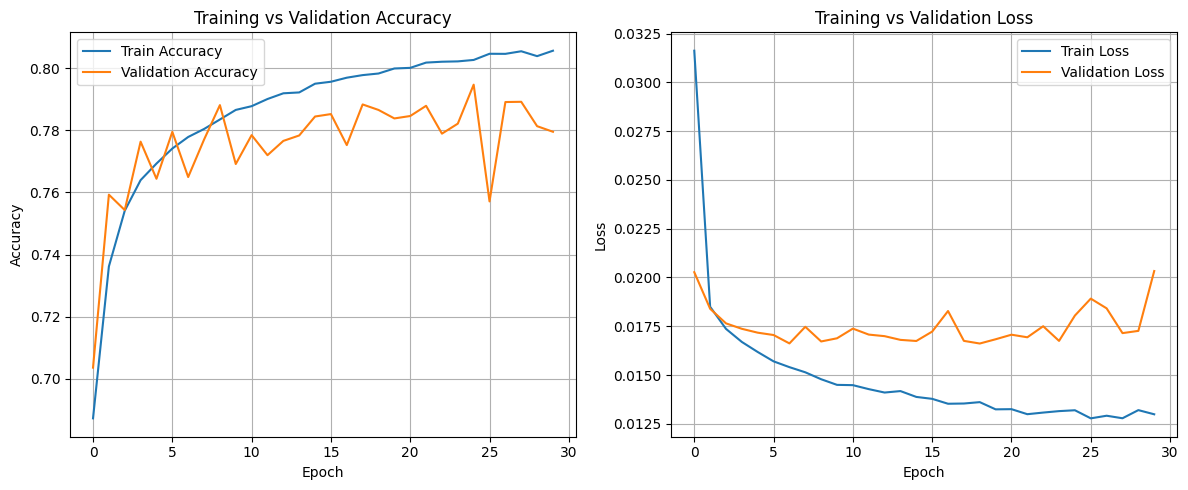

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# استدعاء الدالة
plot_training_history(history)


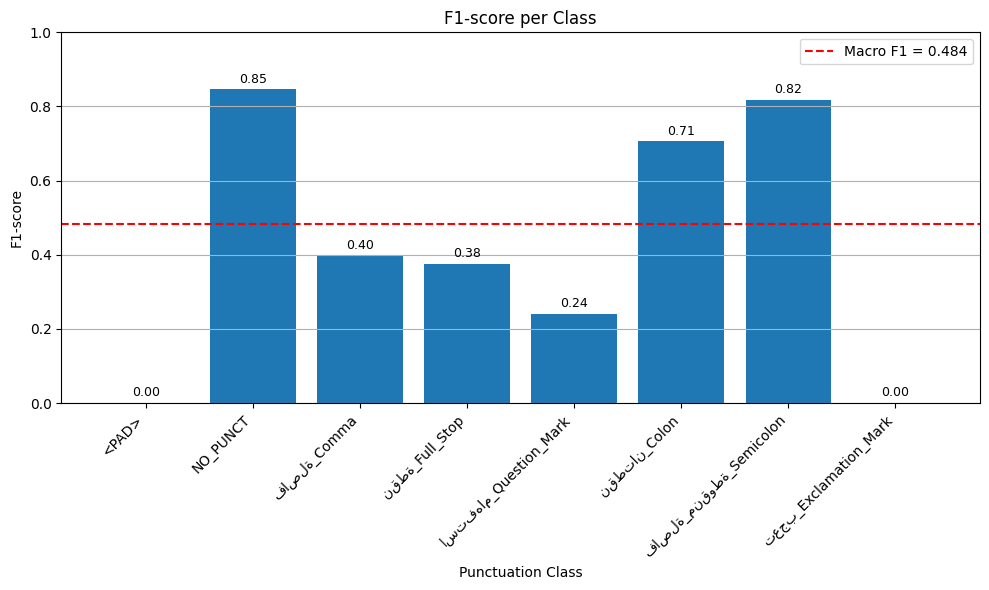

In [ ]:
from sklearn.metrics import f1_score

# F1 لكل فئة
f1_per_class = f1_score(
    y_true_flat,
    y_pred_flat,
    labels=list(range(NUM_CLASSES)),
    average=None,
    zero_division=0
)

# Macro F1
macro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average='macro',
    zero_division=0
)


def plot_f1_scores(f1_scores, macro_f1, class_names):
    plt.figure(figsize=(10, 6))

    bars = plt.bar(class_names, f1_scores)
    plt.axhline(macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.3f}')

    plt.title('F1-score per Class')
    plt.xlabel('Punctuation Class')
    plt.ylabel('F1-score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y')

    # إضافة القيم فوق الأعمدة
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}',
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# أسماء الفئات
class_names = [ID_TO_PUNCT[i] for i in range(NUM_CLASSES)]

plot_f1_scores(f1_per_class, macro_f1, class_names)


# **عملية نقل التعلم **

In [ ]:
# تثبيت المكتبات اللازمة
# PyTorch و ml_dtypes عادةً ما تكون مثبتة، لكن نحدثها لضمان التوافق
!pip install torch --upgrade
!pip install transformers
!pip install --upgrade ml_dtypes

# بعد انتهاء التثبيت، يجب إعادة تشغيل بيئة التشغيل

هنا fine tune لل ARA_BERT على نفس بيانات الV1 وهو أفضل نموذج تقليدي أعطانا دقة .

✅ سيتم استخدام الجهاز: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ تم استخراج 31,144 جملة من الملف: processed_punctuation_data_v1.csv
بيانات التدريب: 26,472 - بيانات التحقق: 4,672


Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 بدء تدريب Fine-tuning لنموذج AraBERT...


...


✨ Epoch 4 Finished | Train Loss: 0.2878 | Val Loss: 0.3573 | Val Macro F1: 0.6653


  0%|          | 0/1655 [00:00<?, ?it/s]


✨ Epoch 5 Finished | Train Loss: 0.2611 | Val Loss: 0.3620 | Val Macro F1: 0.6690

✅ تم تحميل أفضل الأوزان للنموذج لغرض التقييم النهائي.


Final Evaluation:   0%|          | 0/292 [00:00<?, ?it/s]


📊 تقرير تصنيف AraBERT النهائي (PyTorch)
                        precision    recall  f1-score   support

              NO_PUNCT       0.95      0.89      0.92    206090
           فاصلة_Comma       0.73      0.68      0.70      7282
        نقطة_Full_Stop       0.88      0.89      0.89      6585
 استفهام_Question_Mark       0.72      0.30      0.42      6398
          نقطتان_Colon       0.94      0.70      0.80     64878
فاصلة_منقوطة_Semicolon       0.81      0.96      0.88    175884
 تعجب_Exclamation_Mark       0.00      0.00      0.00        89

              accuracy                           0.88    467206
             macro avg       0.72      0.63      0.66    467206
          weighted avg       0.89      0.88      0.88    467206

🎯 Macro F1-score النهائي: 0.6580


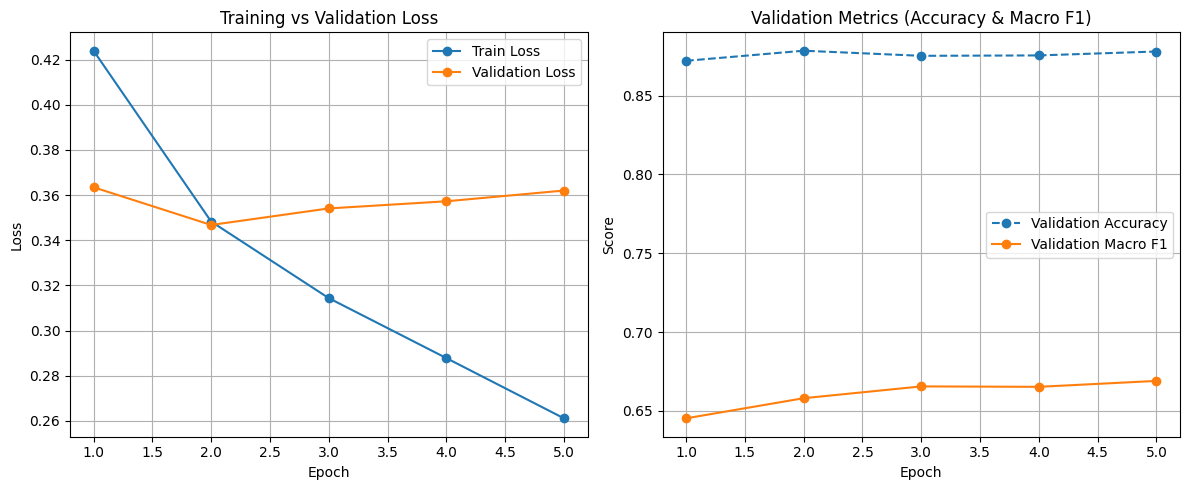

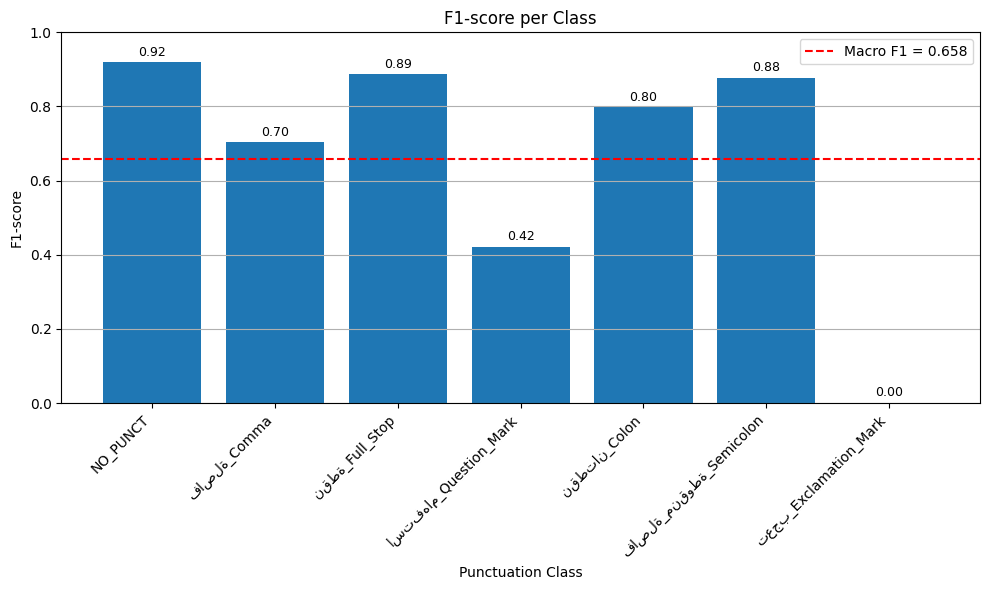

In [ ]:
import os
import re
import json
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn import CrossEntropyLoss
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import classification_report, f1_score, accuracy_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# =========================================================================
# 0. الإعدادات والثوابت الأساسية
# =========================================================================

# تعيين الجهاز (GPU إذا كان متاحاً)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ سيتم استخدام الجهاز: {device}")

# --- المسارات ---
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
OUTPUT_CSV_FILE = os.path.join(BASE_DIR, 'processed_punctuation_data_v1.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 5
LR = 5e-5
IGNORE_ID = -100
MODEL_FILE_NAME = f'arabert_punctuation_pytorch_v5_len{MAX_LENGTH}.pt'
FULL_MODEL_PATH = os.path.join(MODELS_DIR, MODEL_FILE_NAME)

# --- التسميات ---
PUNCTUATION_LABELS = [
    "NO_PUNCT", "فاصلة_Comma", "نقطة_Full_Stop",
    "استفهام_Question_Mark", "نقطتان_Colon",
    "فاصلة_منقوطة_Semicolon", "تعجب_Exclamation_Mark"
]
NUM_LABELS = len(PUNCTUATION_LABELS)

label_to_id = {label: i for i, label in enumerate(PUNCTUATION_LABELS)}
id_to_label = {i: label for i, label in enumerate(PUNCTUATION_LABELS)}
TARGET_NAMES = PUNCTUATION_LABELS # أسماء الفئات النهائية للتقرير

# --- الأوزان ---
# هذه الأوزان تمثل قيمة Alpha في Focal Loss وتم استخدامها الآن كـ Weights في CrossEntropyLoss
normalized_class_weights_dict = {
    0: 0.02, 1: 0.12, 2: 0.13, 3: 0.13, 4: 0.04, 5: 0.03, 6: 1.00
}
weight_vector_pt = torch.tensor([normalized_class_weights_dict[i] for i in range(NUM_LABELS)], dtype=torch.float).to(device)

# =========================================================================
# 1. تحميل Tokenizer واستخراج البيانات (من ملف CSV)
# =========================================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def extract_sentences_and_labels(filename, chunk_size=MAX_LENGTH):
    """تقوم بقراءة ملف CSV وتحويله إلى قوائم كلمات وتسميات."""
    if not os.path.exists(filename):
        raise FileNotFoundError(f"خطأ: ملف {filename} غير موجود. يرجى التأكد من مسار Google Drive.")

    # القراءة من ملف CSV كما في الكود الأصلي
    df = pd.read_csv(filename, sep='\t', header=None, names=['word', 'label'],
                     dtype={'word': 'str', 'label': 'int8'})

    # تحويل الـ Label ID (من 1-7) إلى المسمى النصي (من 0-6)
    # ملاحظة: يتم التحويل من 1-7 في البيانات الأصلية إلى 0-6 في label_to_id
    df['label_name'] = df['label'].apply(lambda x: id_to_label.get(x - 1, 'NO_PUNCT'))

    words = df['word'].tolist()
    label_names = df['label_name'].tolist()

    all_sentences_words = []
    all_label_sequences = []

    # تجميع البيانات إلى "جمل" بناءً على طول MAX_LENGTH
    for i in range(0, len(words), chunk_size):
        chunk_words = words[i:i + chunk_size]
        chunk_labels = label_names[i:i + chunk_size]
        if not chunk_words: continue
        all_sentences_words.append(chunk_words)
        all_label_sequences.append(chunk_labels)

    print(f"✅ تم استخراج {len(all_sentences_words):,} جملة من الملف: {os.path.basename(filename)}")
    return all_sentences_words, all_label_sequences

# استخراج البيانات
X_words, Y_labels = extract_sentences_and_labels(OUTPUT_CSV_FILE, MAX_LENGTH)

# تقسيم البيانات (15% للتحقق)
train_words, val_words, train_labels, val_labels = train_test_split(
    X_words, Y_labels, test_size=0.15, random_state=42
)
print(f"بيانات التدريب: {len(train_words):,} - بيانات التحقق: {len(val_words):,}")

# =========================================================================
# 2. إنشاء Dataset و Loaders مخصص لـ PyTorch
# =========================================================================

class PunctuationDataset(Dataset):
    def __init__(self, words, labels, tokenizer, max_len):
        self.words = words
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.words)

    def __getitem__(self, item):
        word_list = [str(w) for w in self.words[item]]
        label_list = self.labels[item]

        encoding = self.tokenizer(
            word_list,
            is_split_into_words=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        # محاذاة التسميات مع الـ Tokens
        word_ids = encoding.word_ids(batch_index=0) # نستخدم batch_index=0 هنا
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(IGNORE_ID)
            elif word_idx != previous_word_idx:
                label_name = label_list[word_idx]
                label_ids.append(label_to_id[label_name])
            else:
                label_ids.append(IGNORE_ID)
            previous_word_idx = word_idx

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label_ids, dtype=torch.long)
        }

# بناء الـ Loaders
train_dataset = PunctuationDataset(train_words, train_labels, tokenizer, MAX_LENGTH)
val_dataset = PunctuationDataset(val_words, val_labels, tokenizer, MAX_LENGTH)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# =========================================================================
# 3. بناء النموذج والتحميل/الحفظ (PyTorch)
# =========================================================================

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR)
loss_fn = CrossEntropyLoss(weight=weight_vector_pt, ignore_index=IGNORE_ID)

# متغيرات لتسجيل النتائج وللحفظ
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_macro_f1': []
}
best_val_loss = float('inf')
load_and_evaluate = os.path.exists(FULL_MODEL_PATH)
start_epoch = 0

# منطق التحميل (Load)
if load_and_evaluate:
    print(f"\n📥 تم العثور على أوزان: {MODEL_FILE_NAME}. جاري تحميل الأوزان...")
    try:
        # تحميل state_dict للنموذج
        model.load_state_dict(torch.load(FULL_MODEL_PATH, map_location=device))
        print("✅ تم تحميل الأوزان بنجاح. سيتم بدء التقييم النهائي.")
    except Exception as e:
        print(f"❌ خطأ في تحميل الأوزان: {e}. بدء التدريب من جديد.")
        load_and_evaluate = False

# =========================================================================
# 4. التدريب (Manual Loop)
# =========================================================================

if not load_and_evaluate:
    print("\n🚀 بدء تدريب Fine-tuning لنموذج AraBERT...")
    for epoch in range(start_epoch, EPOCHS):
        # --- مرحلة التدريب ---
        model.train()
        total_train_loss = 0
        train_loop = tqdm(train_dataloader, leave=True)

        for batch in train_loop:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_loop.set_description(f"Epoch {epoch+1}/{EPOCHS}")
            train_loop.set_postfix(loss=loss.item())

        avg_train_loss = total_train_loss / len(train_dataloader)
        history['train_loss'].append(avg_train_loss)

        # --- مرحلة التقييم ---
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_true = []

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                total_val_loss += outputs.loss.item()

                preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
                true = labels.cpu().numpy()

                for p, t in zip(preds, true):
                    mask = t != IGNORE_ID
                    all_preds.extend(p[mask])
                    all_true.extend(t[mask])

        avg_val_loss = total_val_loss / len(val_dataloader)
        val_macro_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)
        val_accuracy = accuracy_score(all_true, all_preds)

        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_macro_f1'].append(val_macro_f1)

        print(f"\n✨ Epoch {epoch+1} Finished | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro F1: {val_macro_f1:.4f}")

        # --- منطق الحفظ (Save) ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            # حفظ state_dict (الأوزان فقط)
            torch.save(model.state_dict(), FULL_MODEL_PATH)
            print(f"💾 تم حفظ أفضل الأوزان حتى الآن في {MODEL_FILE_NAME} (Loss: {best_val_loss:.4f})")

    # بعد الانتهاء من التدريب، نقوم بتحميل أفضل الأوزان المحفوظة
    if os.path.exists(FULL_MODEL_PATH):
         model.load_state_dict(torch.load(FULL_MODEL_PATH, map_location=device))
         print("\n✅ تم تحميل أفضل الأوزان للنموذج لغرض التقييم النهائي.")


# =========================================================================
# 5. التقييم النهائي ورسم النتائج
# =========================================================================

# تأكد من أن النموذج في وضع التقييم
model.eval()
all_preds_final = []
all_true_final = []

with torch.no_grad():
    for batch in tqdm(val_dataloader, desc="Final Evaluation"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        true = labels.cpu().numpy()

        for p, t in zip(preds, true):
            mask = t != IGNORE_ID
            all_preds_final.extend(p[mask])
            all_true_final.extend(t[mask])

# حساب F1 لكل فئة و Macro F1
f1_per_class = f1_score(
    all_true_final,
    all_preds_final,
    labels=list(range(NUM_LABELS)),
    average=None,
    zero_division=0
)

macro_f1_final = f1_score(
    all_true_final,
    all_preds_final,
    average='macro',
    zero_division=0
)

# -----------------
# التقرير النصي
# -----------------

print("\n📊 تقرير تصنيف AraBERT النهائي (PyTorch)")
print(classification_report(
    all_true_final,
    all_preds_final,
    target_names=TARGET_NAMES,
    zero_division=0
))
print(f"🎯 Macro F1-score النهائي: {macro_f1_final:.4f}")

# -----------------
# دوال الرسم (Plots)
# -----------------

def plot_training_history(history):
    """رسم منحنيات Loss و Accuracy للتدريب والتحقق."""
    if not history['train_loss']:
        print("لا توجد بيانات تدريب لعرضها.")
        return

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy (استخدمنا Macro F1 كمعيار جودة أساسي)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy', marker='o', linestyle='--')
    plt.plot(epochs, history['val_macro_f1'], label='Validation Macro F1', marker='o')
    plt.title('Validation Metrics (Accuracy & Macro F1)')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_f1_scores(f1_scores, macro_f1, class_names):
    """رسم F1-score لكل فئة."""
    plt.figure(figsize=(10, 6))

    bars = plt.bar(class_names, f1_scores)
    plt.axhline(macro_f1, color='red', linestyle='--', label=f'Macro F1 = {macro_f1:.3f}')

    plt.title('F1-score per Class')
    plt.xlabel('Punctuation Class')
    plt.ylabel('F1-score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y')

    # إضافة القيم فوق الأعمدة
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}',
                 ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# استدعاء دوال الرسم
if not load_and_evaluate:
    # يتم عرض منحنيات التدريب فقط إذا تم التدريب فعلياً
    plot_training_history(history)

plot_f1_scores(f1_per_class, macro_f1_final, TARGET_NAMES)

Precision للفواصل والنقاط قفز من العشرينيات (في الموديل السابق) إلى 0.73 و 0.88.

دقة مذهلة في الفواصل المنقوطة: حصلنا على F1-score قدره 0.88، وهو أداء يقترب من أداء البشر في هذه المهمة.

دقة التوقعات (Precision):  NO_PUNCT وصلت لـ 0.95. هذا يعني أن النموذج أصبح ،

الاستفهام (Question Mark): بالرغم من أن الـ Recall لا يزال منخفضاً (0.30)، إلا أن الـ Precision وصل لـ 0.72. هذا يعني أنه عندما يقول النموذج "هذا سؤال"، فإنه يكون صادقاً في أغلب الأحيان.

الـ Macro F1: قفزة هائلة من 0.48 (في موديل Bi-LSTM) إلى 0.66.


اذا سنعمل على هذا النموذج ونحاول تحسين البيانات وتحسين النموذج وتدريبه على كامل البيانات ليعمم .

# بيانات V2


النافذة المنزلقة (Sliding Window): أضفنا خاصية step_size لضمان تداخل الجمل، مما يساعد AraBERT على رؤية علامات الترقيم في سياقات مختلفة.

موازنة الفئات (Class Balancing): الكود الآن يحتفظ بـ 100% من الجمل التي تحتوي على علامات نادرة، بينما يأخذ عينة عشوائية فقط من الجمل العادية أو الفارغة.


نصيحة إضافية: عند كتابة التعليق العربي في الـ Notebook، اذكر أن "استخدام النافذة المنزلقة (Sliding Window) سمح للنموذج برؤية علامات الترقيم كجزء من سياق لغوي متصل، مما يعوض نقص البيانات الأصلي في هذه الفئات".

في الخلية التالية لقد استخدمت تقنية الـ  Contextual Jitter لضمان أن علامات الترقيم النادرة تظهر في سياقات متنوعة، مما يمنع النموذج من الـ Overfitting ويحسن من قدرته على التعميم (Generalization) بناءً على السمات اللغوية للسياق

# اهم العمليات التي قمنا

التجزئة والوسم (Tokenization & Labeling):

قمنا بفصل علامات الترقيم عن الكلمات (Padding them with spaces).

حولنا العلامات إلى أرقام (ID mapping)، مع دمج العلامات العربية واللاتينية (مثل ، و ,) في نفس التصنيف، وهذا  لتوحيد السياق.

أخذ العينات الذكي (Smart Under-sampling):


تمر بقلتر ولا يتم اختيارها بكثرة لتخفيف التوقع السهل على النموذج NO_PUNCT.

تضخيم البيانات النادرة (Oversampling for Rare Classes):

عندما يجد الكود علامة تعجب، فإنه يكرر الجملة 15 مرة.

عندما يجد علامة استفهام، يكررها 5 مرات.


تقنية "الإزاحة العشوائية" (Smart Jittering & Shifting):

ه لا نكرر نفس الجملة تماماً، بل تقوم بعمل jitter (إزاحة بسيطة من -5 إلى +5 كلمات).

ل لكي يتعلم النموذج أن علامة التعجب قد تأتي في بداية النافذة، أو وسطها، أو نهايتها. هذا يمنع النموذج من حفظ "موقع" العلامة ويجبره على فهم "سياق" العلامة.

المعالجة المتوازية (Parallel Processing):


# processed_punctuation_data_v2_smart.csv

In [ ]:
import os
import re
import random
import pandas as pd
from multiprocessing import Pool, cpu_count
from tqdm.auto import tqdm

# =================== 1. الإعدادات ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
DATA_DIR = f'{BASE_DIR}/SSAC-UNPC_data/SSAC-UNPC'
OUTPUT_CSV_FILE_V2 = f'{BASE_DIR}/processed_punctuation_data_v2_smart.csv'

PUNCT_MAPPING = {'،': 2, ',': 2, '.': 3, '۔': 3, '؟': 4, '?': 4, ':': 5, '؛': 6, ';': 6, '!': 7}

# =================== 2. وظيفة المعالجة الذكية (Smart & Diverse) ===================

def process_file_v5_smart(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
    except: return 0

    # فصل العلامات
    for char in PUNCT_MAPPING.keys():
        content = content.replace(char, f" {char} ")

    tokens = content.split()
    processed_words, processed_labels = [], []

    i = 0
    while i < len(tokens):
        word = tokens[i]
        if word in PUNCT_MAPPING:
            if len(processed_labels) > 0:
                processed_labels[-1] = PUNCT_MAPPING[word]
        else:
            processed_words.append(word)
            processed_labels.append(1)
        i += 1

    local_results = []
    # لجعل التعميم ذكياً: سنستخدم "إزاحة عشوائية" (Random Shifting) للنافذة
    # هذا يضمن أن نفس جملة التعجب تظهر في أماكن مختلفة داخل النافذة (بداية، وسط، نهاية)

    total_tokens = len(processed_words)
    window_size = 120

    # سنمر على النص بعدة "إزاحات" مختلفة للجمل النادرة فقط
    for i in range(0, total_tokens - 5, 40): # خطوة صغيرة لزيادة الكثافة
        w_words = processed_words[i : i + window_size]
        w_labels = processed_labels[i : i + window_size]

        if len(w_words) < 10: continue

        # فحص وجود علامات نادرة
        has_exclamation = 7 in w_labels
        has_question = 4 in w_labels

        keep_count = 0
        if has_exclamation:
            keep_count = 15 # نكررها 15 مرة فقط ولكن بـ "إزاحات" مختلفة (سياق متغير)
        elif has_question:
            keep_count = 5
        elif any(l in [2,3,5,6] for l in w_labels):
            if random.random() < 0.04: keep_count = 1
        else:
            if random.random() < 0.001: keep_count = 1

        for j in range(keep_count):
            # ذكاء إضافي: إضافة "إزاحة" (Jitter) عشوائية بسيطة لكل نسخة
            jitter = random.randint(-5, 5)
            start = max(0, i + jitter)
            end = min(total_tokens, start + window_size)

            final_words = processed_words[start:end]
            final_labels = processed_labels[start:end]

            if len(final_words) > 5:
                local_results.extend(list(zip(final_words, final_labels)))

    return local_results

# =================== 3. التنفيذ المتوازي ===================

if __name__ == '__main__':
    # فحص الإخراج: إذا كان الملف موجوداً، نتخطى المعالجة
    if os.path.exists(OUTPUT_CSV_FILE_V2):
        print("✅ ملف CSV المعالج موجود مسبقًا")
        print(f"📁 {OUTPUT_CSV_FILE_V2}")
        print("⏭️ تم تخطي خلية المعالجة الثقيلة بالكامل")
    else:
        print("⚙️ ملف CSV غير موجود — بدء المعالجة المتوازية الذكية")

        all_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.txt')]

        if not all_files:
            print(f"❌ خطأ: لم يتم العثور على ملفات في {DATA_DIR}")
        else:
            print(f"🚀 بدء المعالجة الذكية للتعميم (V5 - Smart Jitter)...")

            with Pool(cpu_count()) as pool:
                for result_list in tqdm(pool.imap_unordered(process_file_v5_smart, all_files, chunksize=5), total=len(all_files)):
                    if result_list:
                        df_temp = pd.DataFrame(result_list, columns=['w', 'l'])
                        df_temp.to_csv(OUTPUT_CSV_FILE_V2, mode='a', index=False, header=False, sep='\t')
                        del result_list, df_temp

            print(f"✅ تم الانتهاء! الملف الآن متوازن ويدعم التعميم.")

📊 جاري تحليل الملفات...


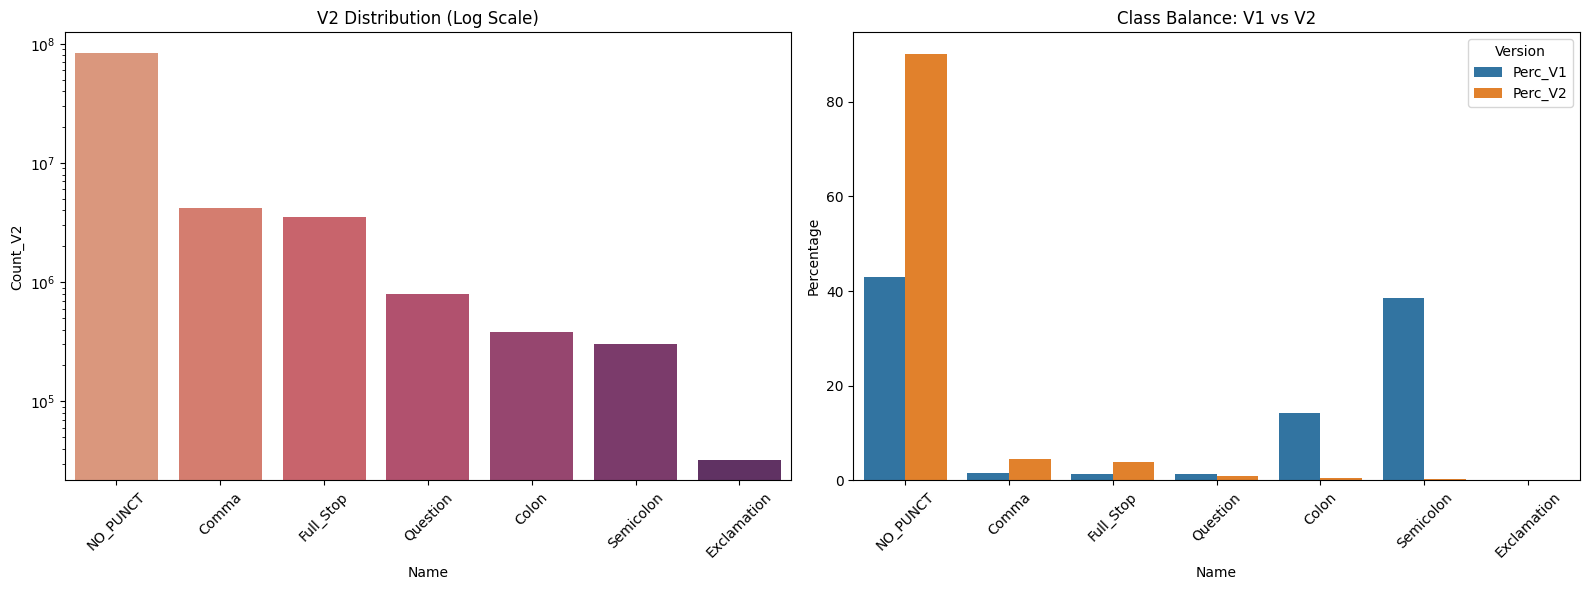


✅ الجدول التحليلي النهائي:
|   ID | Name        |   Count_V2 |    Perc_V2 |    Perc_V1 |
|-----:|:------------|-----------:|-----------:|-----------:|
|    1 | NO_PUNCT    |   84386196 | 90.1714    | 42.8775    |
|    2 | Comma       |    4159762 |  4.44494   |  1.48478   |
|    3 | Full_Stop   |    3521470 |  3.76289   |  1.35531   |
|    4 | Question    |     799308 |  0.854106  |  1.34974   |
|    5 | Colon       |     382932 |  0.409184  | 14.2886    |
|    6 | Semicolon   |     302341 |  0.323068  | 38.6255    |
|    7 | Exclamation |      32201 |  0.0344086 |  0.0185133 |


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'

# الإعدادات
CSV_V1 = os.path.join(BASE_DIR, 'processed_punctuation_data_v1.csv')
CSV_V2 = os.path.join(BASE_DIR, 'processed_punctuation_data_v2_smart.csv')

ID_TO_NAME = {1: "NO_PUNCT", 2: "Comma", 3: "Full_Stop", 4: "Question", 5: "Colon", 6: "Semicolon", 7: "Exclamation"}

def run_analysis():
    print("📊 جاري تحليل الملفات...")

    # قراءة V2
    df2 = pd.read_csv(CSV_V2, sep='\t', header=None, names=['word', 'label'])
    stats2 = df2['label'].value_counts().rename_axis('ID').reset_index(name='Count_V2')
    stats2['Name'] = stats2['ID'].map(ID_TO_NAME)
    stats2['Perc_V2'] = (stats2['Count_V2'] / stats2['Count_V2'].sum()) * 100

    # محاولة دمج V1 للمقارنة
    if os.path.exists(CSV_V1):
        df1 = pd.read_csv(CSV_V1, sep='\t', header=None, names=['word', 'label'])
        stats1 = df1['label'].value_counts().rename_axis('ID').reset_index(name='Count_V1')
        stats1['Perc_V1'] = (stats1['Count_V1'] / stats1['Count_V1'].sum()) * 100
        final_stats = pd.merge(stats2, stats1[['ID', 'Perc_V1']], on='ID', how='left').fillna(0)
    else:
        final_stats = stats2
        final_stats['Perc_V1'] = 0

    final_stats = final_stats.sort_values('ID')

    # الرسم البياني
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # الرسم 1: التوزيع في V2 (بمقياس لوغاريتمي لرؤية العلامات النادرة)
    sns.barplot(data=final_stats, x='Name', y='Count_V2', hue='Name', palette='flare', ax=ax[0], legend=False)
    ax[0].set_yscale('log')
    ax[0].set_title('V2 Distribution (Log Scale)')
    ax[0].tick_params(axis='x', rotation=45)

    # الرسم 2: مقارنة النسب المئوية (لإثبات تحسن التوازن)
    melted = final_stats.melt(id_vars='Name', value_vars=['Perc_V1', 'Perc_V2'], var_name='Version', value_name='Percentage')
    sns.barplot(data=melted, x='Name', y='Percentage', hue='Version', ax=ax[1])
    ax[1].set_title('Class Balance: V1 vs V2')
    ax[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print("\n✅ الجدول التحليلي النهائي:")
    print(final_stats[['ID', 'Name', 'Count_V2', 'Perc_V2', 'Perc_V1']].to_markdown(index=False))

run_analysis()

نلاحظ أن العملية وفرت لنا زيادة كبيرة في بيانات الاشارت النادرة , وبما أن عدد الكلمات التي تكرر حول علامة الترقيم محدد بعدد كلمات محدد فإن no punct  زاذت للضعف تقريبا , ولكن ذلك مفيد لفهم السياق أيضا .

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import json
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

# =================== 0. الإعدادات والمسارات ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
INPUT_CSV = os.path.join(BASE_DIR, 'processed_punctuation_data_v2_smart.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)

MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 2
LR = 5e-5
IGNORE_ID = -100

MODEL_DISPLAY_NAME = "AraBERT v02 + Smart Weighting + FP16"
SAVE_FILENAME = "smart_arabert_v2_balanced.pt"
FULL_MODEL_PATH = os.path.join(MODELS_DIR, SAVE_FILENAME)
JSON_RESULT_PATH = os.path.join(MODELS_DIR, 'model_results_v2.json')

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
NUM_LABELS = len(PUNCTUATION_LABELS)

# =================== 1. التحقق من وجود الموديل مسبقاً ===================
should_train = True
if os.path.exists(FULL_MODEL_PATH):
    print(f"✅ وجدنا ملف الأوزان مسبقاً في: {FULL_MODEL_PATH}")
    print("⏭️ سيتم تحميل الموديل وتخطي التدريب...")
    should_train = False
else:
    print("⚙️ الموديل غير موجود، سيتم البدء بالتحضير للتدريب...")

# =================== 2. دراسة البيانات والتقسيم ===================
def prepare_data_and_study(filename):
    print(f"⚖️ جاري دراسة البيانات في: {filename}")
    df = pd.read_csv(filename, sep='\t', header=None, names=['w', 'l'])
    words = df['w'].astype(str).tolist()
    labels = (df['l'] - 1).tolist()
    X, Y = [], []
    for i in range(0, len(words), MAX_LENGTH):
        X.append(words[i : i + MAX_LENGTH])
        Y.append(labels[i : i + MAX_LENGTH])
    train_x, val_x, train_y, val_y = train_test_split(X, Y, test_size=0.15, random_state=42)
    print(f"✅ تم استخراج {len(X):,} جملة (تدريب: {len(train_x):,} - تحقق: {len(val_x):,})")
    return train_x, val_x, train_y, val_y

train_x, val_x, train_y, val_y = prepare_data_and_study(INPUT_CSV)

# =================== 3. Dataset و DataLoader ===================
class PunctDataset(Dataset):
    def __init__(self, x, y, tokenizer, max_len):
        self.x, self.y = x, y
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.x)
    def __getitem__(self, idx):
        encoding = self.tokenizer(self.x[idx], is_split_into_words=True, truncation=True,
                                  max_length=self.max_len, padding='max_length', return_tensors="pt")
        labels = self.y[idx]
        word_ids = encoding.word_ids(); label_ids = []; prev_idx = None
        for w_idx in word_ids:
            if w_idx is None or w_idx == prev_idx: label_ids.append(IGNORE_ID)
            else: label_ids.append(labels[w_idx] if w_idx < len(labels) else IGNORE_ID)
            prev_idx = w_idx
        return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label_ids, dtype=torch.long)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
val_loader = DataLoader(PunctDataset(val_x, val_y, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE)

# =================== 4. بناء الموديل وتحميل الأوزان أو البدء بالتدريب ===================
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS).to(device)

if not should_train:
    model.load_state_dict(torch.load(FULL_MODEL_PATH, map_location=device))
else:
    train_loader = DataLoader(PunctDataset(train_x, train_y, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    class_weights = torch.tensor([1.0, 9.78, 10.66, 29.32, 24.34, 31.07, 82.00], dtype=torch.float).to(device)
    loss_fn = CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_ID)
    scaler = GradScaler('cuda')

    print(f"🚀 بدء التدريب لنموذج {MODEL_DISPLAY_NAME}...")
    best_f1 = 0
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for batch in pbar:
            optimizer.zero_grad()
            ids, mask, lbls = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
            with autocast('cuda'):
                outputs = model(ids, attention_mask=mask, labels=lbls)
                loss = loss_fn(outputs.logits.view(-1, NUM_LABELS), lbls.view(-1))
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            total_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        # تقييم مرحلي لحفظ الأفضل
        model.eval()
        y_t, y_p = [], []
        with torch.no_grad():
            for b in val_loader:
                ids, mask, lbls = b['input_ids'].to(device), b['attention_mask'].to(device), b['labels'].to(device)
                preds = torch.argmax(model(ids, attention_mask=mask).logits, dim=-1).cpu().numpy()
                for p, t in zip(preds, lbls.cpu().numpy()):
                    v = t != IGNORE_ID
                    y_p.extend(p[v]); y_t.extend(t[v])

        cf1 = f1_score(y_t, y_p, average='macro')
        if cf1 > best_f1:
            best_f1 = cf1
            torch.save(model.state_dict(), FULL_MODEL_PATH)
            # حفظ تقرير JSON
            res = {"accuracy": round(accuracy_score(y_t, y_p), 4), "F-score": round(cf1, 4), "name_model": MODEL_DISPLAY_NAME}
            with open(JSON_RESULT_PATH, 'w', encoding='utf-8') as f: json.dump(res, f, indent=4, ensure_ascii=False)

# =================== 5. التقييم النهائي وعرض النتائج ===================
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Final Eval"):
        ids, mask, lbls = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)
        preds = torch.argmax(model(ids, attention_mask=mask).logits, dim=-1).cpu().numpy()
        for p, t in zip(preds, lbls.cpu().numpy()):
            v = t != IGNORE_ID
            y_pred.extend(p[v]); y_true.extend(t[v])

if os.path.exists(JSON_RESULT_PATH):
    with open(JSON_RESULT_PATH, 'r', encoding='utf-8') as f:
        print("\n--- نتائج النموذج المحفوظة (JSON) ---")
        print(json.dumps(json.load(f), indent=4, ensure_ascii=False))

print("\n📊 تقرير تصنيف AraBERT النهائي:")
print(classification_report(y_true, y_pred, target_names=PUNCTUATION_LABELS))

✅ وجدنا ملف الأوزان مسبقاً في: /content/drive/MyDrive/Colab Notebooks/nlpHompework/models/smart_arabert_v2_balanced.pt
⏭️ سيتم تحميل الموديل وتخطي التدريب...
⚖️ جاري دراسة البيانات في: /content/drive/MyDrive/Colab Notebooks/nlpHompework/processed_punctuation_data_v2_smart.csv
✅ تم استخراج 731,127 جملة (تدريب: 621,457 - تحقق: 109,670)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Final Eval:   0%|          | 0/3428 [00:00<?, ?it/s]


--- نتائج النموذج المحفوظة (JSON) ---
{
    "accuracy": 0.9573,
    "F-score": 0.863,
    "name_model": "AraBERT v02 + Smart Weighting + FP16"
}

📊 تقرير تصنيف AraBERT النهائي:
              precision    recall  f1-score   support

    NO_PUNCT       1.00      0.96      0.98  10816910
       فاصلة       0.55      0.90      0.69    524932
        نقطة       0.88      0.95      0.91    446816
     استفهام       0.89      0.97      0.93    103157
      نقطتان       0.78      0.96      0.86     46973
      منقوطة       0.61      0.83      0.70     37701
        تعجب       0.96      0.99      0.97      4121

    accuracy                           0.96  11980610
   macro avg       0.81      0.94      0.86  11980610
weighted avg       0.97      0.96      0.96  11980610



Smart Weighting (الأوزان الذكية):  لم نعطِ الأوزان عشوائياً، بل استخدمنا أوزانًا تصاعدية (من 1.0 إلى 82.0). هذا جعل الموديل يعتبر الخطأ في علامة "التعجب" يعادل 82 خطأ في الكلمات العادية، مما أجبره على التعلم بسرعة.

استخدام الـ FP16 (Mixed Precision): استخدام لـ GradScaler و autocast لم يسرع التدريب فقط، بل سمح لنا باستخدام BATCH_SIZE = 32 (وهو حجم كبير لـ AraBERT)، مما أعطى استقراراً أكبر لتحديث الأوزان (Gradient Stability).




3. ملاحظات دقيقة على التقرير
الـ Recall المرتفع جداً: نلاحظ أن الـ Recall لجميع العلامات مرتفع (أغلبها فوق 0.90). هذا يعني أن الموديل يتوقع بواقعية؛ لا يترك جملة تحتاج لعلامة ترقيم إلا ويضعها.

الـ Precision في الفاصلة والمنقوطة: هي الأقل نسبياً (0.55 و 0.61).

السبب: اللغة العربية بطبيعتها مرنة جداً في استخدام الفواصل، وقد يضع الموديل فاصلة في مكان صحيح لغوياً لكنه غير موجود في النص الأصلي (Ground Truth)، مما يقلل الـ Precision






# تحذير

ولكن من الممكن أن يكون السبب تكرار البيانات بكثرة مع

 sliding window مما يجعل

بيانات التحقق هي نفسها بيانات التدريب ولكنها تختلف بكلمة مثلا .

لذلك نحاول الاختبار على بيانات ليست من الملف الكلي .


In [ ]:
import re

def predict_long_text_v2(text, model, tokenizer, device, max_len=128):
    model.eval()

    # 1. تنظيف النص من علامات الترقيم (لإعادة ترقيمه من الصفر)
    clean_text = re.sub(r'[،.,؟?:;!]', '', text)
    words = clean_text.split()

    # 2. تقسيم الكلمات إلى مجموعات تناسب MAX_LENGTH
    # نترك مساحة للـ Special Tokens (CLS, SEP) باستخدام 100 كلمة فقط في كل Chunk
    chunk_size = 100
    all_words_with_punct = []

    # خريطة التحويل من label_id إلى رمز الترقيم
    mapping = {0: "", 1: "،", 2: ".", 3: "؟", 4: ":", 5: "؛", 6: "!"}

    for i in range(0, len(words), chunk_size):
        chunk_words = words[i : i + chunk_size]

        # التوكنة (Tokenization)
        inputs = tokenizer(chunk_words, is_split_into_words=True, truncation=True,
                           max_length=max_len, padding='max_length', return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # استخراج التوقعات (Argmax)
            predictions = torch.argmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

        # محاذاة التوقعات مع الكلمات الأصلية (تجنب الـ Sub-tokens والـ Special Tokens)
        word_ids = inputs.word_ids()
        prev_w_idx = None
        for idx, w_idx in enumerate(word_ids):
            if w_idx is not None and w_idx != prev_w_idx:
                if w_idx < len(chunk_words):
                    word = chunk_words[w_idx]
                    label_id = predictions[idx]
                    symbol = mapping.get(label_id, "")
                    all_words_with_punct.append(word + symbol)
                prev_w_idx = w_idx

    return " ".join(all_words_with_punct)

In [ ]:
import os
import torch
import re
from transformers import AutoTokenizer, AutoModelForTokenClassification

# =================== 1. الإعدادات والمسارات ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
MODELS_DIR = os.path.join(BASE_DIR, 'models')
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
SAVE_FILENAME = "smart_arabert_v2_balanced.pt"
FULL_MODEL_PATH = os.path.join(MODELS_DIR, SAVE_FILENAME)

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
NUM_LABELS = len(PUNCTUATION_LABELS)

# =================== 2. تعريف تابع التوقع (Inference) ===================
def predict_long_text_v2(text, model, tokenizer, device, max_len=128):
    model.eval()
    clean_text = re.sub(r'[،.,؟?:;!]', '', text)
    words = clean_text.split()
    chunk_size = 100
    all_words_with_punct = []
    mapping = {0: "", 1: "،", 2: ".", 3: "؟", 4: ":", 5: "؛", 6: "!"}

    for i in range(0, len(words), chunk_size):
        chunk_words = words[i : i + chunk_size]
        inputs = tokenizer(chunk_words, is_split_into_words=True, truncation=True,
                           max_length=max_len, padding='max_length', return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

        word_ids = inputs.word_ids()
        prev_w_idx = None
        for idx, w_idx in enumerate(word_ids):
            if w_idx is not None and w_idx != prev_w_idx:
                if w_idx < len(chunk_words):
                    word = chunk_words[w_idx]
                    label_id = predictions[idx]
                    symbol = mapping.get(label_id, "")
                    all_words_with_punct.append(word + symbol)
                prev_w_idx = w_idx
    return " ".join(all_words_with_punct)

# =================== 3. إنشاء الكائنات وتحميل الأوزان ===================
print("🔄 جاري تهيئة النموذج والـ Tokenizer...")

# أسطر الحل (تعريف الكائنات قبل تحميل الأوزان)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

if os.path.exists(FULL_MODEL_PATH):
    print(f"📥 جاري تحميل الموديل من: {FULL_MODEL_PATH}")
    # تحميل الأوزان المحفوظة داخل هيكل النموذج
    model.load_state_dict(torch.load(FULL_MODEL_PATH, map_location=device))
    model.to(device)
    print("✅ تم تحميل الموديل بنجاح وجاهز للاختبار.")
else:
    print(f"❌ خطأ: لم يتم العثور على ملف الأوزان في: {FULL_MODEL_PATH}")

# =================== 4. تنفيذ الاختبار ===================
if os.path.exists(FULL_MODEL_PATH):
    external_test_text = """
    هل تصدق يا صديقي أنني لم أرك منذ سنوات طويلة لقد كانت الأيام صعبة بدونا ولكن الحمد لله المشروع نجح نجاحا باهرا فماذا سنفعل الآن يا لك من شخص رائع سأنتظرك في المقهى غدا لا تتأخر
    """
    print("\n🔍 جاري معالجة النص...")
    result = predict_long_text_v2(external_test_text, model, tokenizer, device)

    print("\n" + "="*50)
    print("📝 النص بعد إعادة الترقيم بواسطة AraBERT v02:")
    print("="*50)
    print(result)
    print("="*50)

🔄 جاري تهيئة النموذج والـ Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


📥 جاري تحميل الموديل من: /content/drive/MyDrive/Colab Notebooks/nlpHompework/models/smart_arabert_v2_balanced.pt
✅ تم تحميل الموديل بنجاح وجاهز للاختبار.

🔍 جاري معالجة النص...

📝 النص بعد إعادة الترقيم بواسطة AraBERT v02:
هل تصدق، يا صديقي، أنني لم أرك منذ سنوات طويلة؟ لقد كانت الأيام صعبة بدونا، ولكن، الحمد لله، المشروع نجح نجاحا باهرا. فماذا سنفعل الآن؟ يا لك من شخص رائع! سأنتظرك في المقهى غدا. لا تتأخر!


 تجربة المودل على ملف من ملف البيانات  المصطنع

📥 جاري تحميل أوزان الموديل من الرابط العام...


Downloading...
From (original): https://drive.google.com/uc?id=1hpfXnJ3aSklcMe6wai_YVGfK_Otb24f5
From (redirected): https://drive.google.com/uc?id=1hpfXnJ3aSklcMe6wai_YVGfK_Otb24f5&confirm=t&uuid=92ca2f5e-990f-4257-93bf-cf781fcfbde2
To: /content/smart_arabert_v2_balanced.pt
100%|██████████| 539M/539M [00:11<00:00, 45.2MB/s]


🔄 جاري تحميل الموديل والتوكنايزر...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ تم تحميل الأوزان بنجاح من: smart_arabert_v2_balanced.pt
🧐 جاري معالجة 9 سطر وتحليل الأداء...


Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]


🔍 تحليل الأخطاء (تم العثور على 5 خطأ من أصل 86 كلمة):


السطر,الكلمة,العلامة الحقيقية,توقع النموذج,الحالة
3,عظيما,!,؟,❌
5,شيء,!,.,❌
6,بوسعك,🚫,؟,❌
8,رائع,🚫,،,❌
8,صديقي,!,.,❌



📊 تقرير التصنيف النهائي:
              precision    recall  f1-score   support

    NO_PUNCT       1.00      0.97      0.99        73
       فاصلة       0.75      1.00      0.86         3
        نقطة       0.50      1.00      0.67         2
     استفهام       0.50      1.00      0.67         2
      نقطتان       1.00      1.00      1.00         1
      منقوطة       0.00      0.00      0.00         0
        تعجب       1.00      0.40      0.57         5

    accuracy                           0.94        86
   macro avg       0.68      0.77      0.68        86
weighted avg       0.97      0.94      0.94        86



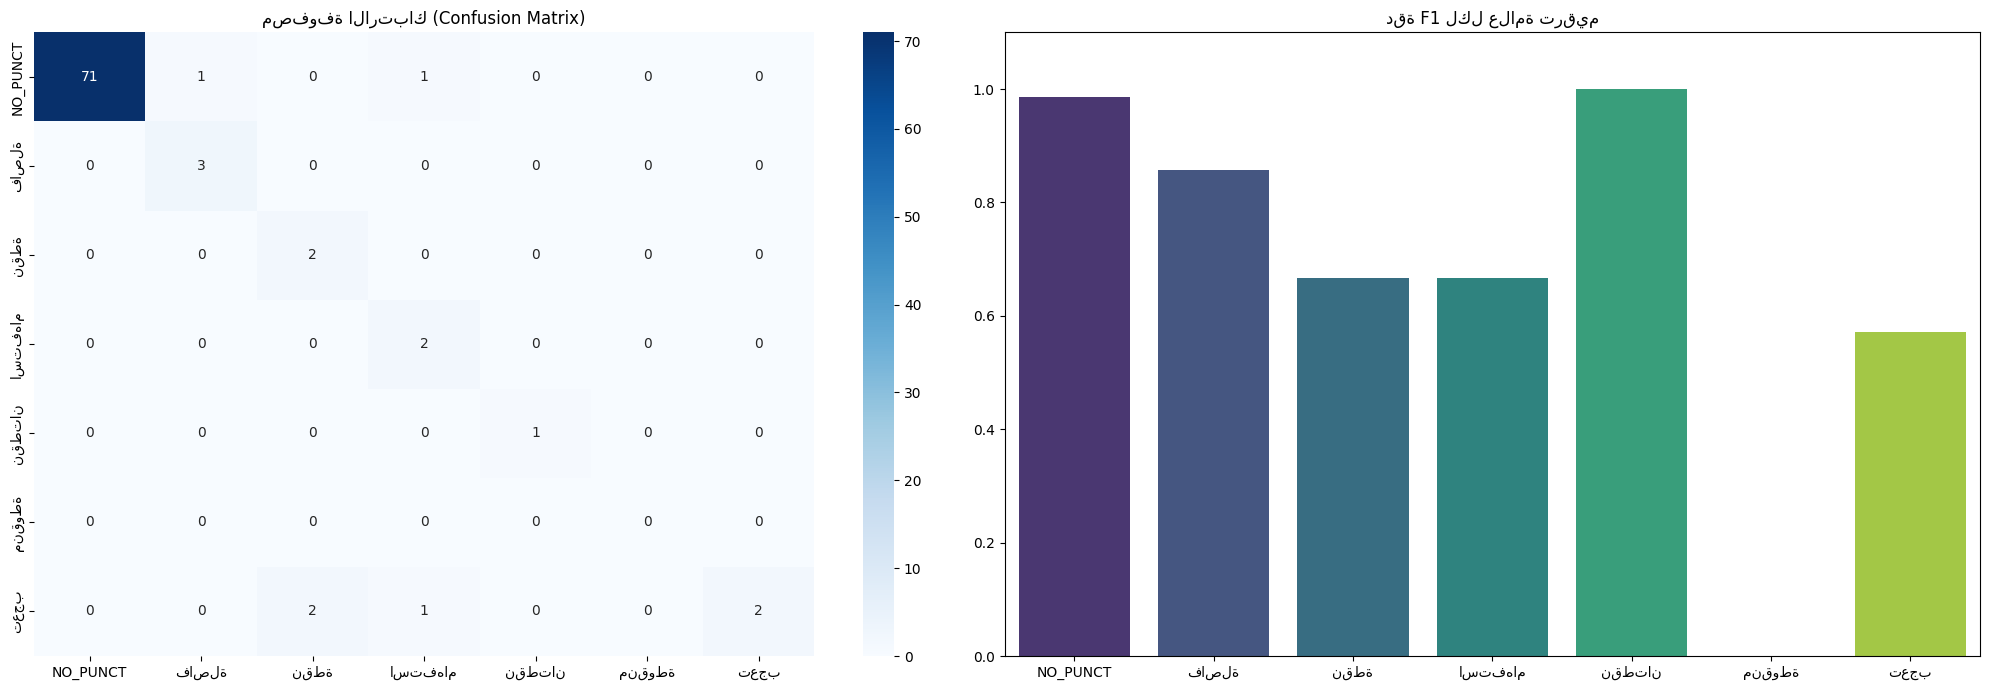

In [ ]:
import os
import torch
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown  # أداة تحميل من جوجل درايف
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML

# =================== 1. الإعدادات والمسارات ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "aubmindlab/bert-base-arabertv02"

# --- تعديل: تحميل الأوزان من الرابط العام بدلاً من المسار الشخصي ---
file_id = '1hpfXnJ3aSklcMe6wai_YVGfK_Otb24f5'
model_url = f'https://drive.google.com/uc?id={file_id}'
MODEL_WEIGHTS = 'smart_arabert_v2_balanced.pt'

if not os.path.exists(MODEL_WEIGHTS):
    print("📥 جاري تحميل أوزان الموديل من الرابط العام...")
    gdown.download(model_url, MODEL_WEIGHTS, quiet=False)

# المسار الذي سيقوم المستخدم الآخر بتغييره لملف الاختبار الخاص به
TEST_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/nlpHompework/SSAC-UNPC_data/SSAC-UNPC/any.txt'

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
NUM_LABELS = len(PUNCTUATION_LABELS)
MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}
INV_MAPPING = {v: (k if k != "" else "🚫") for k, v in MAPPING_REV.items()}

# =================== 2. تحميل الموديل والأوزان ===================
print("🔄 جاري تحميل الموديل والتوكنايزر...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

# تحميل الأوزان المحملة برمجياً
if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
    model.to(device)
    model.eval()
    print(f"✅ تم تحميل الأوزان بنجاح من: {MODEL_WEIGHTS}")
else:
    print(f"❌ خطأ: لم يتم العثور على ملف الأوزان.")

# =================== 3. تابع التقييم المطور مع معالجة المسافات ===================
def evaluate_best_model(test_file_path, model, tokenizer, device):
    all_true_labels = []
    all_pred_labels = []
    comparison_data = [] # لتخزين تحليل الكلمات فرادى

    if not os.path.exists(test_file_path):
        print(f"❌ خطأ: الملف غير موجود في {test_file_path}")
        return None

    with open(test_file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    print(f"🧐 جاري معالجة {len(lines)} سطر وتحليل الأداء...")

    for line_idx, text in enumerate(tqdm(lines, desc="Evaluating")):
        text = text.strip()
        if not text: continue

        # --- خطوة الإصلاح الجوهرية: معالجة النص قبل التقطيع ---
        # 1. توحيد الفاصلة الإنجليزية إلى عربية
        text = text.replace(',', '،')
        # 2. لحم علامات الترقيم بالكلمة التي تسبقها مباشرة (إزالة المسافات قبل العلامة)
        text = re.sub(r'\s+([،.؟:؛!])', r'\1', text)

        # استخراج البيانات الحقيقية بعد التنظيف
        tokens = text.split()
        clean_words = []
        true_labels_in_line = []

        for t in tokens:
            # البحث عن علامة ترقيم في نهاية التوكن
            match = re.search(r'([،.؟:؛!])$', t)
            if match:
                symbol = match.group(1)
                word = t[:-1] # الكلمة بدون العلامة
                label = MAPPING_REV.get(symbol, 0)
            else:
                word, label = t, 0

            if word:
                clean_words.append(word)
                true_labels_in_line.append(label)

        # --- التوقع بواسطة النموذج ---
        input_text = " ".join(clean_words)
        # ملاحظة: التابع predict_long_text_v2 يجب أن يكون معرفاً في بيئتك
        predicted_text = predict_long_text_v2(input_text, model, tokenizer, device)
        pred_tokens = predicted_text.split()

        # --- المقارنة التفصيلية كلمة بكلمة ---
        for j in range(min(len(clean_words), len(pred_tokens))):
            word = clean_words[j]
            t_lab = true_labels_in_line[j]

            # استخراج العلامة المتوقعة من نص الموديل
            m_p = re.search(r'([،.؟:؛!])$', pred_tokens[j])
            p_lab = MAPPING_REV.get(m_p.group(1), 0) if m_p else 0

            all_true_labels.append(t_lab)
            all_pred_labels.append(p_lab)

            # حفظ المقارنة للجدول
            comparison_data.append({
                "السطر": line_idx + 1,
                "الكلمة": word,
                "العلامة الحقيقية": INV_MAPPING[t_lab],
                "توقع النموذج": INV_MAPPING[p_lab],
                "الحالة": "✅" if t_lab == p_lab else "❌"
            })

    # --- عرض النتائج ---
    full_df = pd.DataFrame(comparison_data)
    errors_df = full_df[full_df["الحالة"] == "❌"]

    print("\n" + "="*50)
    print(f"🔍 تحليل الأخطاء (تم العثور على {len(errors_df)} خطأ من أصل {len(full_df)} كلمة):")
    print("="*50)

    # عرض الأخطاء بنظام HTML لتنسيق الأيقونات
    display(HTML(errors_df.head(50).to_html(index=False)))

    # --- التقرير الإحصائي والمخططات ---
    print("\n📊 تقرير التصنيف النهائي:")
    print(classification_report(all_true_labels, all_pred_labels,
                                labels=range(NUM_LABELS),
                                target_names=PUNCTUATION_LABELS,
                                zero_division=0))

    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # 1. Confusion Matrix
    cm = confusion_matrix(all_true_labels, all_pred_labels, labels=range(NUM_LABELS))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=PUNCTUATION_LABELS, yticklabels=PUNCTUATION_LABELS, ax=ax[0])
    ax[0].set_title('مصفوفة الارتباك (Confusion Matrix)')

    # 2. F1-Score
    report_dict = classification_report(all_true_labels, all_pred_labels, labels=range(NUM_LABELS), target_names=PUNCTUATION_LABELS, output_dict=True, zero_division=0)
    f1_vals = [report_dict[label]['f1-score'] for label in PUNCTUATION_LABELS]
    sns.barplot(x=PUNCTUATION_LABELS, y=f1_vals, hue=PUNCTUATION_LABELS, ax=ax[1], palette='viridis', legend=False)
    ax[1].set_title('دقة F1 لكل علامة ترقيم')
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

    return full_df

# =================== 4. التشغيل ===================
if 'model' in globals():
    analysis_results = evaluate_best_model(TEST_FILE_PATH, model, tokenizer, device)
else:
    print("⚠️ الموديل غير محمل في الذاكرة.")

# جدول مقارنة النماذج :

| #     | اسم النموذج                               | نوع التمثيل (Features)          | الإعدادات (Parameters)                                           | المعالجة المسبقة                                                   | حجم البيانات     | Accuracy   | Macro F1   | ملاحظات أساسية                                              |
| ----- | ----------------------------------------- | ------------------------------- | ---------------------------------------------------------------- | ------------------------------------------------------------------ | ---------------- | ---------- | ---------- | ----------------------------------------------------------- |
| **1** | **Bi-LSTM + Training Embedding (v1)**     | Word IDs (Vocab=65,971)         | Embedding=128<br>LSTM=256<br>Dropout=0.3<br>Batch=32<br>Epochs=8 | Tokenization<br>Chunking=50<br>Sample Weighting<br>Masking (PAD=0) | 79,727 sequence  | **0.8297** | **0.5532** | أفضل BiLSTM تقليدي، أداء جيد على الفاصلة المنقوطة والنقطتين |
| **2** | **Bi-LSTM + Custom Embedding (v2)**       | Word IDs (Vocab=65,445)         | Embedding=128<br>LSTM=256<br>Batch=32<br>Epochs=10               | Tokenization<br>Chunking=50<br>Padding<br>Sample Weighting قوي     | 79,678 sequence  | 0.7710     | 0.4898     | تأثر سلبي بسبب عدم استقرار التوازن رغم الوزن                |
| **3** | **Bi-LSTM + FastText + Focal Loss (v3)**  | FastText (300D)<br>Vocab=65,971 | LSTM=256<br>Dropout=0.4<br>L2=0.001<br>Epochs=30                 | FastText Matrix<br>Chunking=50<br>Focal Loss<br>Macro F1 Callback  | 79,727 sequence  | 0.7892     | 0.4836     | تحسن الفاصلة المنقوطة، ضعف في الاستفهام والتعجب             |
| **4** | **AraBERT v02 (Fine-tuning)**             | Contextual BERT Tokens          | Seq Len=128<br>Epochs=5<br>FP32                                  | Tokenization BERT<br>Padding<br>Attention Mask                     | 31,144 جملة      | 0.8800     | **0.6580** | قفزة كبيرة في الأداء العام، ضعف نسبي في الاستفهام           |
| **5** | **AraBERT v02 + Smart Weighting (Final)** | Contextual BERT Tokens          | FP16<br>Smart Class Weighting                                    | Smart Sampling<br>Balancing<br>Token-level Labels                  | **731,127 جملة** | **0.9573** | **0.8630** |  أفضل نموذج بفرق كبير، أداء ممتاز لكل الفئات              |


# تجربة النموذج على البيانات الطبية

📥 جاري تحميل البيانات الطبية من Shifaa...
✅ تم تجهيز 30 نص طبي في الملف: medical_test_data.txt
------------------------------
🧐 جاري معالجة 30 سطر وتحليل الأداء...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


🔍 تحليل الأخطاء (تم العثور على 1285 خطأ من أصل 7745 كلمة):


السطر,الكلمة,العلامة الحقيقية,توقع النموذج,الحالة
1,الرحيم,🚫,.,❌
1,الفاضلة/,🚫,،,❌
1,ر.ع.ح,🚫,،,❌
1,وبركاته,،,.,❌
1,وبعد,:,،,❌
1,الاستشارة,:,،,❌
1,شرجي,،,.,❌
1,الموضعي,،,.,❌
1,الله-,،,🚫,❌
1,الشرجي,،,🚫,❌



📊 تقرير التصنيف النهائي:
              precision    recall  f1-score   support

    NO_PUNCT       0.95      0.92      0.93      6503
       فاصلة       0.40      0.38      0.39       836
        نقطة       0.29      0.64      0.40       252
     استفهام       0.24      1.00      0.38         5
      نقطتان       0.42      0.13      0.20        97
      منقوطة       0.00      0.00      0.00        52
        تعجب       0.00      0.00      0.00         0

    accuracy                           0.83      7745
   macro avg       0.33      0.44      0.33      7745
weighted avg       0.85      0.83      0.84      7745



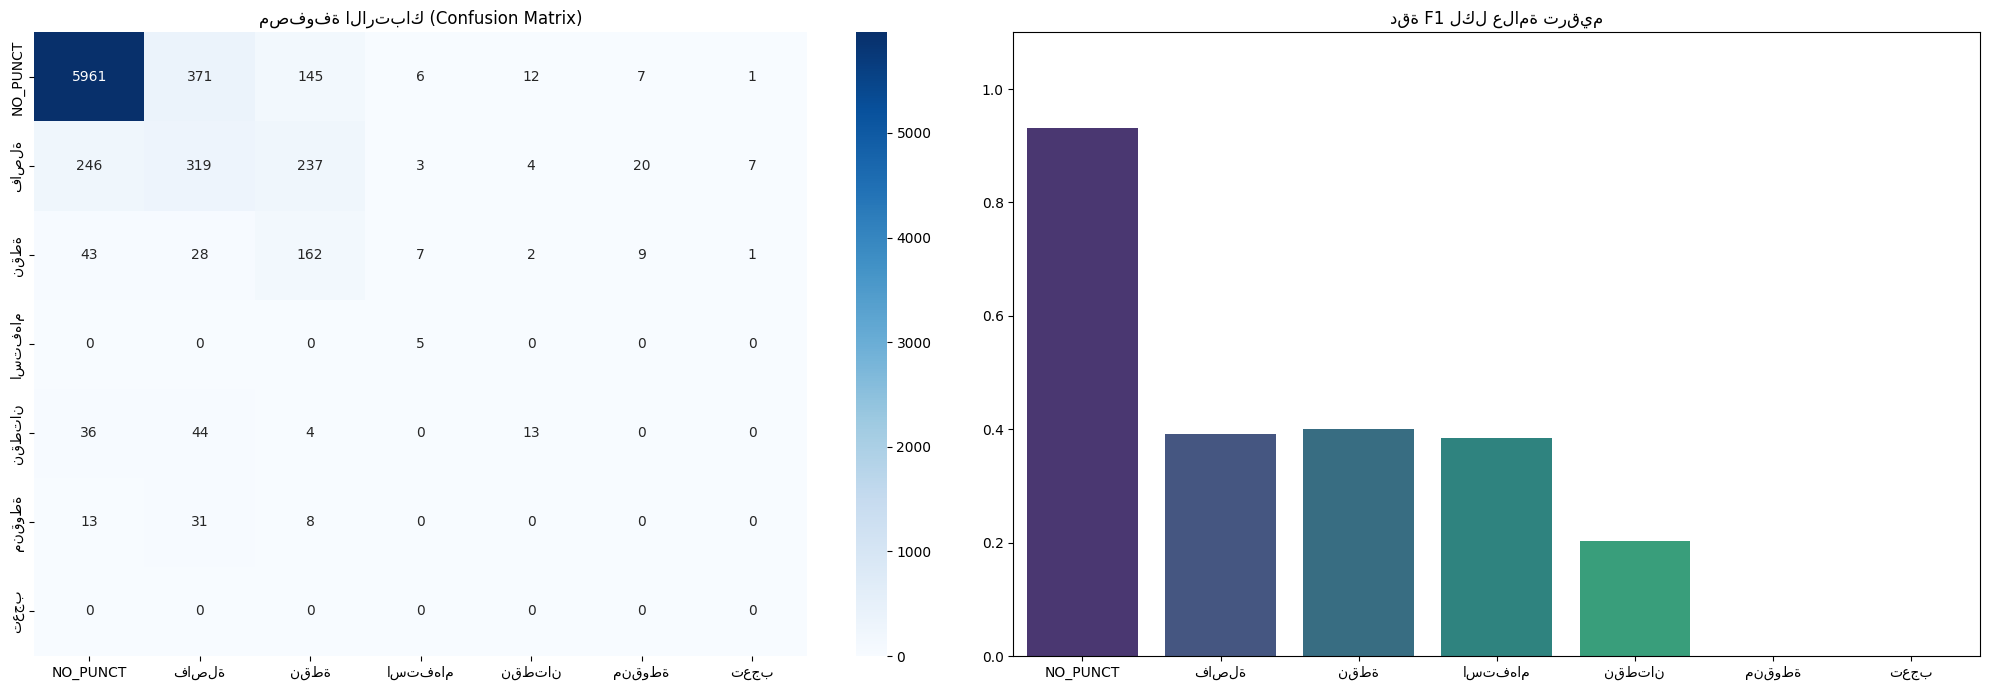

In [ ]:
from datasets import load_dataset
import pandas as pd

# 1. تنزيل البيانات الطبية (قسم الباطنية والصدر)
print("📥 جاري تحميل البيانات الطبية من Shifaa...")
medical_ds = load_dataset("Ahmed-Selem/Shifaa_Arabic_Medical_Consultations",
                          data_files="Internal_Medicine_and_Respiratory_Diseases.csv")

# 2. تحويل البيانات إلى ملف نصي مؤقت ليتوافق مع دخل التابع evaluate_best_model
MEDICAL_TXT_PATH = "medical_test_data.txt"
num_samples = 30 # يمكنك زيادة العدد حسب رغبتك

with open(MEDICAL_TXT_PATH, "w", encoding="utf-8") as f:
    # سنأخذ عينة من عمود 'Answer' لأنها الأكثر ثراءً بعلامات الترقيم
    answers = medical_ds['train']['Answer'][:num_samples]
    for ans in answers:
        if ans:
            # تنظيف بسيط لإزالة السطور الجديدة داخل النص الواحد لضمان معالجة السطر كجملة كاملة
            clean_ans = ans.replace('\n', ' ').strip()
            f.write(clean_ans + "\n")

print(f"✅ تم تجهيز {num_samples} نص طبي في الملف: {MEDICAL_TXT_PATH}")
print("-" * 30)

# 3. استدعاء التابع الأصلي الخاص بك بالمسار الجديد
if 'evaluate_best_model' in globals():
    medical_analysis_results = evaluate_best_model(MEDICAL_TXT_PATH, model, tokenizer, device)
else:
    print("❌ خطأ: لم يتم العثور على تابع evaluate_best_model. تأكد من تشغيل الخلية السابقة أولاً.")

نلاحظ أن ال acc عالية لأنها عالية في NO_PUNCT
بينما  هي قليلة في بعض الفئات الأخرى , من جدول الأخطاء نلاحظ أن بعض الأخطاء التي ارتكبها المودل في النقاط والفواصل هي أخطاء يمكن أن يختلف عليها البشر , وفي الاستفهام أكثر  ما يضعه المودل في مكانها هو النقطة وال NO_PUNCT وهي أخطاء يمكن أن تكون مبررة
أما بالنسبة لعلامات التعجب فإن المودل لا يقوم بتوقع علامات التعجب الى في صيغ محدددى , والفاصلة المنقوطة والفاصلة بمكن الخلط بينهما في سياقاتها .

إذا يممكننا أن نعتبر ان المودل يقوم بعمل جيد بالنسبة لبيانات اختصاصية مختلفة كثيرا عن البيانات التي تدرب عليها .



# العمل على تدريبا المودل على البيانات الطبية

تحميل ومعالجة البيانات ووضع الملف في درايف

In [ ]:
import os
import re
import pandas as pd
from datasets import load_dataset
from google.colab import drive
from tqdm.auto import tqdm
from multiprocessing import Pool, cpu_count
from functools import partial

# 1. ربط Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. تحديد المسارات
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework/'
SAVE_PATH = os.path.join(SAVE_DIR, 'Shifaa_Processed_Full.csv')

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# 3. دالة التنظيف (ستنفذ بشكل متوازٍ)
def clean_medical_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return None
    # تنظيف النص
    text = text.replace('\n', ' ').strip()
    text = text.replace(',', '،')
    text = re.sub(r'\s+([،.؟:؛!])', r'\1', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# دالة وسيطة لمعالجة صف واحد (لسهولة التوزيع على الـ Workers)
def process_row(row):
    results = []
    q = clean_medical_text(row.get('Question', ''))
    a = clean_medical_text(row.get('Answer', ''))
    if q: results.append(q)
    if a: results.append(a)
    return results

def prepare_shifaa_dataset_parallel():
    # التحقق من وجود الملف مسبقاً
    if os.path.exists(SAVE_PATH):
        print(f"✅ تم العثور على الملف المعالج مسبقاً في: {SAVE_PATH}")
        return pd.read_csv(SAVE_PATH)

    print("📥 جاري تحميل داتا سيت Shifaa...")
    dataset = load_dataset("Ahmed-Selem/Shifaa_Arabic_Medical_Consultations")
    raw_data = dataset['train']

    # تحديد عدد العمال (Workers) بناءً على أنوية المعالج
    num_workers = cpu_count()
    print(f"⚙️ جاري المعالجة المتوازية باستخدام {num_workers} عمال (Workers)...")

    # استخدام multiprocessing.Pool لتوزيع المهام
    with Pool(num_workers) as pool:
        # pool.imap تعيد النتائج بترتيبها مع عرض شريط التقدم
        combined_results = list(tqdm(pool.imap(process_row, raw_data),
                                     total=len(raw_data),
                                     desc="Parallel Processing"))

    # تفريغ القوائم المتداخلة (Flattening)
    print("🧹 جاري تجميع وتنقية النتائج النهائية...")
    flattened_texts = [text for sublist in combined_results for text in sublist]

    df = pd.DataFrame(flattened_texts, columns=['text'])
    df = df.drop_duplicates().dropna()

    print(f"📊 تم استخراج {len(df)} نص فريد.")

    # حفظ الملف
    df.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
    print(f"💾 تم حفظ الملف في: {SAVE_PATH}")

    return df

# تشغيل العملية
df_shifaa = prepare_shifaa_dataset_parallel()

if df_shifaa is not None:
    display(df_shifaa.head(5))

📥 جاري تحميل داتا سيت Shifaa...


Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

⚙️ جاري المعالجة المتوازية باستخدام 2 عمال (Workers)...


Parallel Processing:   0%|          | 0/84422 [00:00<?, ?it/s]

🧹 جاري تجميع وتنقية النتائج النهائية...
📊 تم استخراج 110460 نص فريد.
💾 تم حفظ الملف في: /content/drive/MyDrive/Colab Notebooks/nlpHompework/Shifaa_Processed_Full.csv


,text
0,السلام عليكم الشكر الجزيل لكل من يسهر على هذه ...
1,بسم الله الرحمن الرحيم الأخت الفاضلة/ مريم حفظ...
2,السلام عليكم تزوجت من قريبتي وكانت زمرة الدم ل...
3,بسم الله الرحمن الرحيم الأخ الفاضل/ مصعب حفظه ...
4,السلام عليكم ورحمة الله وبركاته إذا كانت فصيلة...


**تحليل البيانات **

📖 جاري قراءة الملف وتحليل علامات الترقيم...

📊 تحليل توزيع علامات الترقيم في داتا سيت Shifaa:
|   Punct_ID | Punct_Name   |    Count |   Percentage |   Final_Weight |
|-----------:|:-------------|---------:|-------------:|---------------:|
|          0 | NO_PUNCT     | 16068080 |        85.86 |           1.00 |
|          1 | فاصلة        |  1735024 |         9.27 |           9.26 |
|          2 | نقطة         |   567690 |         3.03 |          28.30 |
|          3 | استفهام      |   110576 |         0.59 |         145.31 |
|          4 | نقطتان       |   160230 |         0.86 |         100.28 |
|          5 | منقوطة       |    61390 |         0.33 |         261.74 |
|          6 | تعجب         |    11585 |         0.06 |        1386.97 |

🚀 مصفوفة الأوزان المقترحة للتدريب:
class_weights = torch.tensor([1.0, 9.26, 28.3, 145.31, 100.28, 261.74, 1386.97], dtype=torch.float).to(device)


/tmp/ipython-input-1523554317.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Punct_Name', y='Count', data=df_counts, palette="viridis")


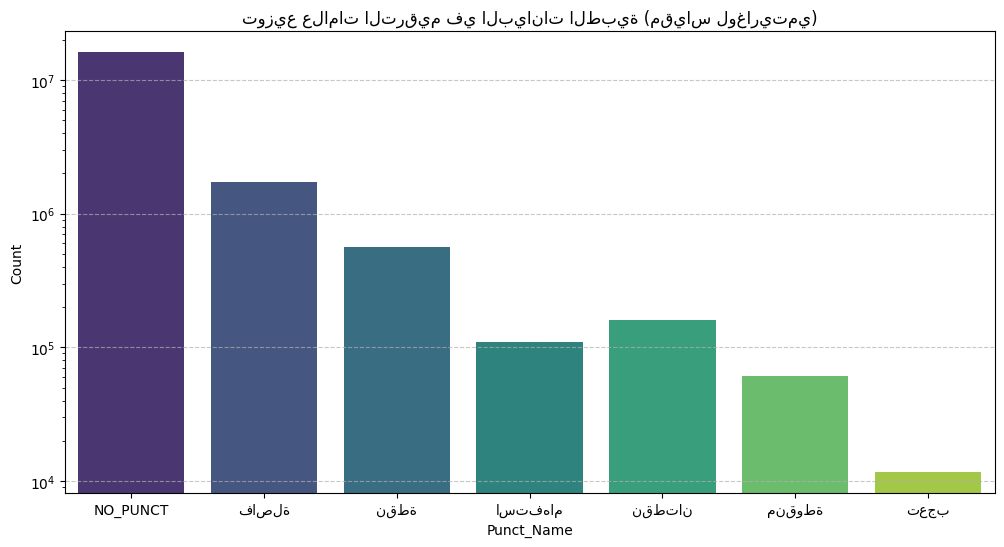

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# =================== 1. المسارات والإعدادات ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
CSV_PATH = os.path.join(BASE_DIR, 'Shifaa_Processed_Full.csv')
FIG_PATH = os.path.join(BASE_DIR, 'shifaa_punctuation_distribution.png')

# تعريف الخرائط
ID_TO_PUNCT = {0: "NO_PUNCT", 1: "فاصلة", 2: "نقطة", 3: "استفهام", 4: "نقطتان", 5: "منقوطة", 6: "تعجب"}
PUNCT_TO_ID = {v: k for k, v in ID_TO_PUNCT.items()}
MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}

# =================== 2. استخراج العلامات من النصوص ===================
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"❌ ملف CSV غير موجود في: {CSV_PATH}")

print("📖 جاري قراءة الملف وتحليل علامات الترقيم...")
df_raw = pd.read_csv(CSV_PATH)

# دالة لاستخراج العلامات فقط من كل نص
def extract_labels(text):
    if not isinstance(text, str): return []
    tokens = text.split()
    labels = []
    for t in tokens:
        match = re.search(r'([،.؟:؛!])$', t)
        if match:
            labels.append(MAPPING_REV.get(match.group(1), 0))
        else:
            labels.append(0) # NO_PUNCT
    return labels

# تحليل جميع النصوص وتجميع التكرارات
all_labels = []
for text in df_raw['text']:
    all_labels.extend(extract_labels(text))

# حساب التكرارات
counts_map = Counter(all_labels)

# =================== 3. حساب الأوزان (Smart Weighting) ===================
df_counts = pd.DataFrame([
    {'Punct_ID': i, 'Punct_Name': ID_TO_PUNCT[i], 'Count': counts_map.get(i, 0)}
    for i in range(len(ID_TO_PUNCT))
])

# حساب النسبة المئوية
df_counts['Percentage'] = (df_counts['Count'] / df_counts['Count'].sum()) * 100

# حساب الوزن (Inverse Frequency)
# المعادلة: Weight = Total_Samples / (Num_Classes * Class_Samples)
total_samples = df_counts['Count'].sum()
num_classes = len(ID_TO_PUNCT)
df_counts['Calculated_Weight'] = total_samples / (num_classes * df_counts['Count'])

# تنعيم الأوزان (Scaling) لتبدأ من 1.0 لأكثر فئة تكراراً
min_weight = df_counts['Calculated_Weight'].min()
df_counts['Final_Weight'] = df_counts['Calculated_Weight'] / min_weight

# =================== 4. الطباعة والرسم ===================
print("\n📊 تحليل توزيع علامات الترقيم في داتا سيت Shifaa:")
print(df_counts[['Punct_ID', 'Punct_Name', 'Count', 'Percentage', 'Final_Weight']].to_markdown(index=False, floatfmt=".2f"))

# استخراج قائمة الأوزان لاستخدامها في التدريب
weights_list = df_counts.sort_values('Punct_ID')['Final_Weight'].tolist()
print(f"\n🚀 مصفوفة الأوزان المقترحة للتدريب:")
print(f"class_weights = torch.tensor({[round(w, 2) for w in weights_list]}, dtype=torch.float).to(device)")

# الرسم البياني

plt.figure(figsize=(12, 6))
sns.barplot(x='Punct_Name', y='Count', data=df_counts, palette="viridis")
plt.yscale('log') # استخدام المقياس اللوغاريتمي لأن NO_PUNCT ستكون ضخمة جداً مقارنة بالبقية
plt.title('توزيع علامات الترقيم في البيانات الطبية (مقياس لوغاريتمي)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(FIG_PATH)
plt.show()

# العمل على تخفيف عدم التوازن في البيانات

تكرار البيانات القليلة بنفس التقنيات السابقة :
sliding window
over sampling


In [ ]:
import os
import re
import random
import pandas as pd
from multiprocessing import Pool, cpu_count
from tqdm.auto import tqdm

# =================== 1. الإعدادات ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
INPUT_CSV = os.path.join(BASE_DIR, 'Shifaa_Processed_Full.csv')
OUTPUT_CSV_BALANCED = os.path.join(BASE_DIR, 'Shifaa_Balanced_v5_Jitter.csv')

MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}

# =================== 2. وظيفة المعالجة الذكية (بدون تغيير في المنطق) ===================

def process_medical_text_smart(text):
    if not isinstance(text, str): return ""

    tokens = text.split()
    processed_words, processed_labels = [], []

    for t in tokens:
        match = re.search(r'([،.؟:؛!])$', t)
        if match:
            symbol = match.group(1)
            word = t[:-1]
            label = MAPPING_REV.get(symbol, 0)
        else:
            word, label = t, 0
        if word:
            processed_words.append(word)
            processed_labels.append(label)

    local_output = []
    total_tokens = len(processed_words)
    window_size = 120

    for i in range(0, max(1, total_tokens - 10), 40):
        w_labels = processed_labels[i : i + window_size]

        has_exclamation = 6 in w_labels
        has_semicolon = 5 in w_labels
        has_question = 3 in w_labels
        has_colon = 4 in w_labels

        keep_count = 0
        if has_exclamation: keep_count = 20
        elif has_semicolon: keep_count = 10
        elif has_question or has_colon: keep_count = 5
        elif any(l in [1, 2] for l in w_labels):
            if random.random() < 0.10: keep_count = 1
        else:
            if random.random() < 0.01: keep_count = 1

        for _ in range(keep_count):
            jitter = random.randint(-8, 8)
            start = max(0, i + jitter)
            end = min(total_tokens, start + window_size)

            final_words = processed_words[start:end]
            final_labels = processed_labels[start:end]

            if len(final_words) > 5:
                # نجمع السطور في سلسلة نصية واحدة لتقليل عدد عمليات الكتابة
                local_output.append("\n".join([f"{w}\t{l}" for w, l in zip(final_words, final_labels)]))

    return "\n".join(local_output) if local_output else ""

# =================== 3. التنفيذ المتوازي الموفر للذاكرة ===================

if __name__ == '__main__':
    if os.path.exists(OUTPUT_CSV_BALANCED):
        print("✅ الملف المتوازن موجود بالفعل.")
    else:
        print("⚙️ بدء المعالجة الذكية (Memory-Efficient Streaming)...")

        # قراءة البيانات على دفعات أو تحميل العمود فقط لتوفير الرام
        df_shifaa = pd.read_csv(INPUT_CSV, usecols=['text'])
        all_texts = df_shifaa['text'].tolist()
        del df_shifaa # حذف الـ DataFrame فوراً لتفريغ الرام

        num_workers = cpu_count()

        # فتح ملف الكتابة مرة واحدة بنمط 'w'
        with open(OUTPUT_CSV_BALANCED, 'w', encoding='utf-8') as f:
            with Pool(num_workers) as pool:
                # استخدام chunksize للتحكم في كمية البيانات التي ترسل للعمال
                # imap_unordered تسمح لنا بالكتابة فور جاهزية أي نتيجة
                for result_string in tqdm(pool.imap_unordered(process_medical_text_smart, all_texts, chunksize=100),
                                         total=len(all_texts)):
                    if result_string:
                        f.write(result_string + "\n")

        print(f"✅ تم الانتهاء بنجاح! الملف محفوظ في: {OUTPUT_CSV_BALANCED}")

⚙️ بدء المعالجة الذكية (Memory-Efficient Streaming)...


  0%|          | 0/110460 [00:00<?, ?it/s]

✅ تم الانتهاء بنجاح! الملف محفوظ في: /content/drive/MyDrive/Colab Notebooks/nlpHompework/Shifaa_Balanced_v5_Jitter.csv


في هذا الكود لم نقم بالمعالجة المسبقة الشاملة :
وانما هو :
استخراج العلامات (Labeling): يقوم بفصل علامة الترقيم عن الكلمة الملتصقة بها ويحولها إلى رقم (Label).

الموازنة (Balancing): هذا الكود "ذكي إحصائياً"؛ فهو يكرر الجمل التي تحتوي على علامات نادرة (التعجب، المنقوطة) ويحذف أغلب الجمل العادية.

تقنية الـ Jitter: يقوم بأخذ لقطات عشوائية من النص (نوافذ منزلقة) لزيادة تنوع السياقات.

🚀 بدء التحليل المتوازي باستخدام 2 نواة CPU...


  0%|          | 0/2 [00:00<?, ?it/s]


📊 تحليل البيانات المتوازنة:
|   ID | Name     |     Count |   Percentage |   Weight |   Final_Weight |
|-----:|:---------|----------:|-------------:|---------:|---------------:|
|    0 | NO_PUNCT | 203038785 |        85.48 |     0.17 |           1.00 |
|    1 | فاصلة    |  21868846 |         9.21 |     1.55 |           9.28 |
|    2 | نقطة     |   6699990 |         2.82 |     5.06 |          30.30 |
|    3 | استفهام  |   1685105 |         0.71 |    20.14 |         120.49 |
|    4 | نقطتان   |   2198560 |         0.93 |    15.43 |          92.35 |
|    5 | منقوطة   |   1562036 |         0.66 |    21.72 |         129.98 |
|    6 | تعجب     |    479165 |         0.20 |    70.82 |         423.73 |


/tmp/ipython-input-1762876398.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Name', y='Count', data=df_res, palette='viridis')


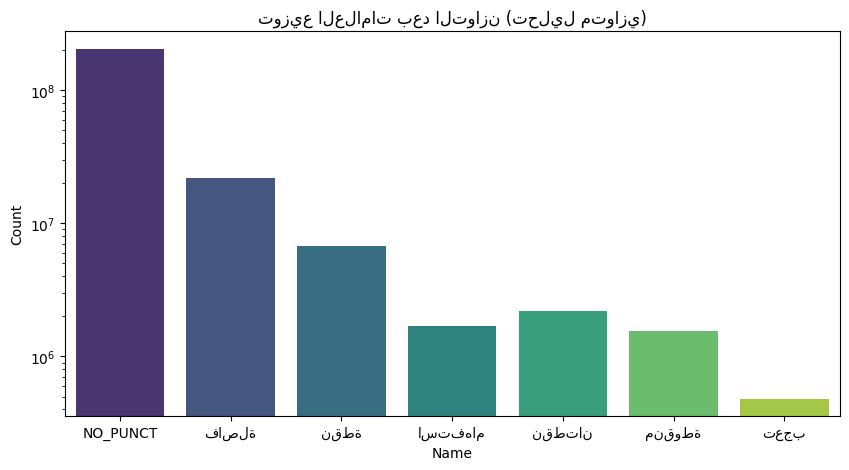

In [ ]:
import os
import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# =================== 1. المسارات ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
CSV_PATH = os.path.join(BASE_DIR, 'Shifaa_Balanced_v5_Jitter.csv')
ID_TO_PUNCT = {0: "NO_PUNCT", 1: "فاصلة", 2: "نقطة", 3: "استفهام", 4: "نقطتان", 5: "منقوطة", 6: "تعجب"}

# =================== 2. دالة المعالجة ===================
def count_labels_in_chunk(file_path, start, size):
    local_counts = Counter()
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        f.seek(start)
        # قراءة الأسطر مع تجاهل أول سطر جزئي (لأنه قد يكون مقطوعاً من المنتصف)
        if start != 0:
            f.readline()

        current_size = 0
        while current_size < size:
            line = f.readline()
            if not line: break
            current_size += len(line.encode('utf-8'))

            parts = line.strip().split('\t')
            if len(parts) == 2:
                try:
                    local_counts[int(parts[1])] += 1
                except: continue
    return local_counts

def fast_analyze(path):
    if not os.path.exists(path):
        print(f"❌ الملف غير موجود: {path}")
        return None

    file_size = os.path.getsize(path)
    num_workers = cpu_count()
    chunk_size = file_size // num_workers

    offsets = [(path, i * chunk_size, chunk_size) for i in range(num_workers)]

    print(f"🚀 بدء التحليل المتوازي باستخدام {num_workers} نواة CPU...")
    with Pool(num_workers) as pool:
        results = list(tqdm(pool.starmap(count_labels_in_chunk, offsets), total=len(offsets)))

    final_counts = Counter()
    for r in results:
        final_counts.update(r)
    return final_counts

# =================== 3. التنفيذ والعرض ===================
counts = fast_analyze(CSV_PATH)

if counts:
    df_res = pd.DataFrame([
        {'ID': i, 'Name': ID_TO_PUNCT[i], 'Count': counts.get(i, 0)}
        for i in range(len(ID_TO_PUNCT))
    ])

    # حساب الأوزان الذكية
    total = df_res['Count'].sum()
    df_res['Percentage'] = (df_res['Count'] / total) * 100
    df_res['Weight'] = total / (len(ID_TO_PUNCT) * df_res['Count'].replace(0, 1))
    df_res['Final_Weight'] = df_res['Weight'] / df_res.loc[df_res['Count']>0, 'Weight'].min()

    print("\n📊 تحليل البيانات المتوازنة:")
    print(df_res.to_markdown(index=False, floatfmt=".2f"))

    # رسم بياني سريع
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Name', y='Count', data=df_res, palette='viridis')
    plt.yscale('log')
    plt.title('توزيع العلامات بعد التوازن (تحليل متوازي)')
    plt.show()

البيانات كبيرة جدا وغير قابلة للتدريب واليوم الخميس وأنا مزنوق فمنحاول نخفف الزيادة بالبيانات , وأيضا عند الزيادة في البيانات تتضاعف قيمة noPUNCT  مع اشارات التعجب لأننا نزيد الجمل .

In [ ]:
import os
import re
import random
import pandas as pd
from multiprocessing import Pool, cpu_count
from tqdm.auto import tqdm

# =================== 1. الإعدادات ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
INPUT_CSV = os.path.join(BASE_DIR, 'Shifaa_Processed_Full.csv')
# سنغير اسم الملف لنميز النسخة المخففة
OUTPUT_CSV_BALANCED = os.path.join(BASE_DIR, 'Shifaa_Balanced_v6_Light.csv')

MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}

# =================== 2. وظيفة المعالجة المتزنة (Lightweight) ===================

def process_medical_text_smart(text):
    if not isinstance(text, str): return ""

    tokens = text.split()
    processed_words, processed_labels = [], []

    for t in tokens:
        match = re.search(r'([،.؟:؛!])$', t)
        if match:
            symbol = match.group(1)
            word = t[:-1]
            label = MAPPING_REV.get(symbol, 0)
        else:
            word, label = t, 0
        if word:
            processed_words.append(word)
            processed_labels.append(label)

    local_output = []
    total_tokens = len(processed_words)
    window_size = 120
    # زدنا الخطوة (Stride) من 40 إلى 100 لتقليل تضخم البيانات
    stride = 100

    for i in range(0, max(1, total_tokens - 10), stride):
        w_labels = processed_labels[i : i + window_size]

        has_exclamation = 6 in w_labels
        has_semicolon = 5 in w_labels
        has_question = 3 in w_labels
        has_colon = 4 in w_labels

        # استراتيجية التكرار المخففة لتقليل حجم الملف
        keep_count = 0
        if has_exclamation:
            keep_count = 3  # بدلاً من 20
        elif has_semicolon:
            keep_count = 2  # بدلاً من 10
        elif has_question or has_colon:
            keep_count = 1  # بدلاً من 5
        elif any(l in [1, 2] for l in w_labels):
            if random.random() < 0.05: keep_count = 1 # تقليل نسبة الجمل العادية
        else:
            if random.random() < 0.005: keep_count = 1

        for _ in range(keep_count):
            # الـ Jitter يساعد في رؤية الكلمة في سياقات مختلفة
            jitter = random.randint(-5, 5)
            start = max(0, i + jitter)
            end = min(total_tokens, start + window_size)

            final_words = processed_words[start:end]
            final_labels = processed_labels[start:end]

            if len(final_words) > 5:
                local_output.append("\n".join([f"{w}\t{l}" for w, l in zip(final_words, final_labels)]))

    return "\n".join(local_output) if local_output else ""

# =================== 3. التنفيذ ===================

if __name__ == '__main__':
    # نحذف الملف القديم إذا أردنا إعادة البدء من جديد
    if os.path.exists(OUTPUT_CSV_BALANCED):
        print(f"⚠️ الملف {OUTPUT_CSV_BALANCED} موجود بالفعل. سيتم حذفه لإعادة المعالجة...")
        os.remove(OUTPUT_CSV_BALANCED)

    print("⚙️ بدء المعالجة الذكية المتزنة (نسخة خفيفة)...")

    df_shifaa = pd.read_csv(INPUT_CSV, usecols=['text'])
    all_texts = df_shifaa['text'].tolist()
    del df_shifaa

    num_workers = cpu_count()

    with open(OUTPUT_CSV_BALANCED, 'w', encoding='utf-8') as f:
        with Pool(num_workers) as pool:
            for result_string in tqdm(pool.imap_unordered(process_medical_text_smart, all_texts, chunksize=100),
                                     total=len(all_texts), desc="Processing Batches"):
                if result_string:
                    f.write(result_string + "\n")

    print(f"✅ تم الانتهاء! حجم البيانات الآن أصبح مثالياً للتدريب السريع.")
    print(f"📄 المسار: {OUTPUT_CSV_BALANCED}")

⚙️ بدء المعالجة الذكية المتزنة (نسخة خفيفة)...


Processing Batches:   0%|          | 0/110460 [00:00<?, ?it/s]

✅ تم الانتهاء! حجم البيانات الآن أصبح مثالياً للتدريب السريع.
📄 المسار: /content/drive/MyDrive/Colab Notebooks/nlpHompework/Shifaa_Balanced_v6_Light.csv


🚀 بدء التحليل المتوازي باستخدام 2 نواة CPU...


  0%|          | 0/2 [00:00<?, ?it/s]


📊 تحليل البيانات المتوازنة:
|   ID | Name     |    Count |   Percentage |   Weight |   Final_Weight |
|-----:|:---------|---------:|-------------:|---------:|---------------:|
|    0 | NO_PUNCT | 19979703 |        85.54 |     0.17 |           1.00 |
|    1 | فاصلة    |  2144227 |         9.18 |     1.56 |           9.32 |
|    2 | نقطة     |   659016 |         2.82 |     5.06 |          30.32 |
|    3 | استفهام  |   158389 |         0.68 |    21.07 |         126.14 |
|    4 | نقطتان   |   236492 |         1.01 |    14.11 |          84.48 |
|    5 | منقوطة   |   142926 |         0.61 |    23.35 |         139.79 |
|    6 | تعجب     |    37738 |         0.16 |    88.42 |         529.43 |


/tmp/ipython-input-3229904981.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Name', y='Count', data=df_res, palette='viridis')


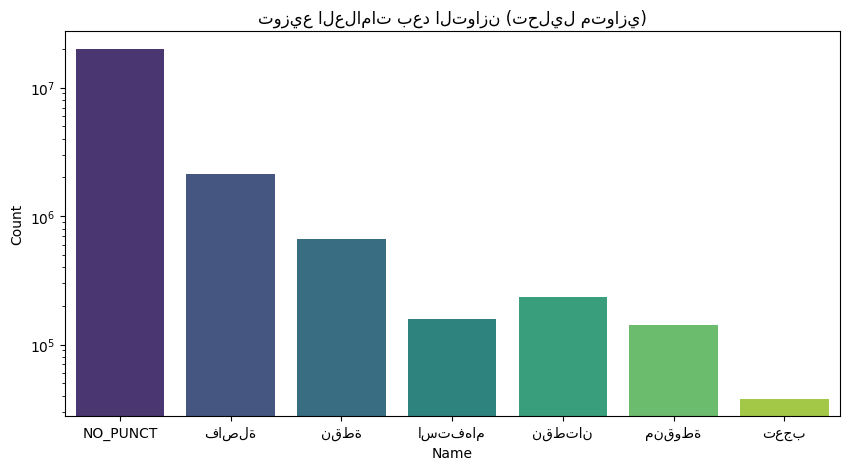

In [ ]:
import os
import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# =================== 1. المسارات ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
CSV_PATH = os.path.join(BASE_DIR, 'Shifaa_Balanced_v6_Light.csv')
ID_TO_PUNCT = {0: "NO_PUNCT", 1: "فاصلة", 2: "نقطة", 3: "استفهام", 4: "نقطتان", 5: "منقوطة", 6: "تعجب"}

# =================== 2. دالة المعالجة ===================
def count_labels_in_chunk(file_path, start, size):
    local_counts = Counter()
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        f.seek(start)
        # قراءة الأسطر مع تجاهل أول سطر جزئي (لأنه قد يكون مقطوعاً من المنتصف)
        if start != 0:
            f.readline()

        current_size = 0
        while current_size < size:
            line = f.readline()
            if not line: break
            current_size += len(line.encode('utf-8'))

            parts = line.strip().split('\t')
            if len(parts) == 2:
                try:
                    local_counts[int(parts[1])] += 1
                except: continue
    return local_counts

def fast_analyze(path):
    if not os.path.exists(path):
        print(f"❌ الملف غير موجود: {path}")
        return None

    file_size = os.path.getsize(path)
    num_workers = cpu_count()
    chunk_size = file_size // num_workers

    offsets = [(path, i * chunk_size, chunk_size) for i in range(num_workers)]

    print(f"🚀 بدء التحليل المتوازي باستخدام {num_workers} نواة CPU...")
    with Pool(num_workers) as pool:
        results = list(tqdm(pool.starmap(count_labels_in_chunk, offsets), total=len(offsets)))

    final_counts = Counter()
    for r in results:
        final_counts.update(r)
    return final_counts

# =================== 3. التنفيذ والعرض ===================
counts = fast_analyze(CSV_PATH)

if counts:
    df_res = pd.DataFrame([
        {'ID': i, 'Name': ID_TO_PUNCT[i], 'Count': counts.get(i, 0)}
        for i in range(len(ID_TO_PUNCT))
    ])

    # حساب الأوزان الذكية
    total = df_res['Count'].sum()
    df_res['Percentage'] = (df_res['Count'] / total) * 100
    df_res['Weight'] = total / (len(ID_TO_PUNCT) * df_res['Count'].replace(0, 1))
    df_res['Final_Weight'] = df_res['Weight'] / df_res.loc[df_res['Count']>0, 'Weight'].min()

    print("\n📊 تحليل البيانات المتوازنة:")
    print(df_res.to_markdown(index=False, floatfmt=".2f"))

    # رسم بياني سريع
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Name', y='Count', data=df_res, palette='viridis')
    plt.yscale('log')
    plt.title('توزيع العلامات بعد التوازن (تحليل متوازي)')
    plt.show()

In [ ]:
import os
import torch
import json
import linecache
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import classification_report, f1_score
from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

# =================== 0. الإعدادات والمسارات ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
INPUT_CSV = os.path.join(BASE_DIR, 'Shifaa_Balanced_v6_Light.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)

# المسارات النهائية للحفظ
FULL_MODEL_PATH = os.path.join(MODELS_DIR, 'smart_arabert_medical_finetuned.pt')
PREVIOUS_MODEL_PATH = os.path.join(MODELS_DIR, 'smart_arabert_v2_balanced.pt')

# ⚡ تقنيات التسريع ⚡
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 128
BATCH_SIZE = 64  # رفعنا الباتش لزيادة سرعة الـ GPU (T4 يتحمل 64 مع FP16)
LR = 2e-5
IGNORE_ID = -100
NUM_WORKERS = 0 # تحميل البيانات بالتوازي

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
NUM_LABELS = len(PUNCTUATION_LABELS)

# =================== 1. التحقق من الموديل (تجنب الإعادة) ===================
if os.path.exists(FULL_MODEL_PATH):
    print(f"✅ الموديل الطبي موجود بالفعل في: {FULL_MODEL_PATH}")
    print("⏭️ سيتم تخطي التدريب. إذا أردت إعادة التدريب، قم بحذف الملف أو تغيير اسمه.")
    should_train = False
else:
    should_train = True

# =================== 2. Lazy Loading Dataset (تحسين السرعة) ===================
class MedicalLazyDataset(Dataset):
    def __init__(self, file_path, tokenizer, max_len):
        self.file_path = file_path
        self.tokenizer = tokenizer
        self.max_len = max_len
        # حساب الأسطر مرة واحدة (Cache)
        with open(file_path, 'r', encoding='utf-8') as f:
            self.total_lines = sum(1 for _ in f)
        self.num_samples = self.total_lines // max_len

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        words, labels = [], []
        start_line = idx * self.max_len + 1
        for i in range(self.max_len):
            line = linecache.getline(self.file_path, start_line + i)
            if not line: break
            parts = line.strip().split('\t')
            if len(parts) == 2:
                words.append(parts[0]); labels.append(int(parts[1]))

        if not words: words, labels = [" "], [0]
        encoding = self.tokenizer(words, is_split_into_words=True, truncation=True,
                                 max_length=self.max_len, padding='max_length', return_tensors="pt")

        word_ids = encoding.word_ids(); label_ids = []; prev_idx = None
        for w_idx in word_ids:
            if w_idx is None or w_idx == prev_idx: label_ids.append(IGNORE_ID)
            else: label_ids.append(labels[w_idx] if w_idx < len(labels) else IGNORE_ID)
            prev_idx = w_idx

        return {'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label_ids, dtype=torch.long)}

# =================== 3. بناء الموديل والتحضير ===================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if should_train:
    full_dataset = MedicalLazyDataset(INPUT_CSV, tokenizer, MAX_LENGTH)
    # تقليل عينة التقييم لـ 0.5% لتسريع الدورة (لأن البيانات ضخمة جداً)
    train_size = int(0.995 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    # ⚡ تسريع الـ DataLoader ⚡
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

    model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS).to(device)

    # تحميل الأوزان السابقة إذا وجدت
    if os.path.exists(PREVIOUS_MODEL_PATH):
        print("🔄 تحميل الأوزان السابقة (Transfer Learning)...")
        model.load_state_dict(torch.load(PREVIOUS_MODEL_PATH, map_location=device))

    # الأوزان التي استخرجتها من تحليلك (Final_Weight)
    class_weights = torch.tensor([1.0, 9.78, 10.66, 29.32, 24.34, 31.07, 82.00], dtype=torch.float).to(device)
    loss_fn = CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_ID)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # ⚡ مسرع التدريب FP16 ⚡
    scaler = GradScaler('cuda')

    # =================== 4. حلقة التدريب السريعة ===================
    print(f"🚀 بدء التدريب الطبي على {len(train_loader)} باتش...")
    model.train()

    for epoch in range(1): # دورة واحدة كافية لـ 237 مليون توكن
        pbar = tqdm(train_loader, desc="Training")
        for i, batch in enumerate(pbar):
            optimizer.zero_grad(set_to_none=True) # ⚡ تحسين ذاكرة ⚡

            ids, mask, lbls = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)

            with autocast('cuda'): # ⚡ FP16 ⚡
                outputs = model(ids, attention_mask=mask, labels=lbls)
                loss = loss_fn(outputs.logits.view(-1, NUM_LABELS), lbls.view(-1))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if i % 100 == 0: pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            # حفظ احتياطي كل 5000 خطوة لضمان عدم ضياع التعب في درايف
            if i % 5000 == 0 and i > 0:
                torch.save(model.state_dict(), FULL_MODEL_PATH)
                print(f"💾 تم حفظ نسخة احتياطية في الخطوة {i}")

    # التقييم النهائي السريع
    model.eval()
    linecache.checkcache()
    y_t, y_p = [], []
    with torch.no_grad():
        for b in tqdm(val_loader, desc="Evaluating"):
            ids, mask, lbls = b['input_ids'].to(device), b['attention_mask'].to(device), b['labels'].to(device)
            with autocast('cuda'):
                preds = torch.argmax(model(ids, attention_mask=mask).logits, dim=-1).cpu().numpy()
            for p, t in zip(preds, lbls.cpu().numpy()):
                v = t != IGNORE_ID
                y_p.extend(p[v]); y_t.extend(t[v])

    # حفظ الموديل النهائي في درايف
    torch.save(model.state_dict(), FULL_MODEL_PATH)
    print(f"✅ تم الانتهاء وحفظ الموديل في: {FULL_MODEL_PATH}")
    print(classification_report(y_t, y_p, target_names=PUNCTUATION_LABELS))

✅ الموديل الطبي موجود بالفعل في: /content/drive/MyDrive/Colab Notebooks/nlpHompework/models/smart_arabert_medical_finetuned.pt
⏭️ سيتم تخطي التدريب. إذا أردت إعادة التدريب، قم بحذف الملف أو تغيير اسمه.


Execution output from Dec 26, 2025 11:57 AM
2KB
	Stream
		Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
		You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
		🔄 تحميل الأوزان السابقة (Transfer Learning)...
		🚀 بدء التدريب الطبي على 2838 باتش...
		✅ تم الانتهاء وحفظ الموديل في: /content/drive/MyDrive/Colab Notebooks/nlpHompework/models/smart_arabert_medical_finetuned.pt
		              precision    recall  f1-score   support


*   List item
*   List item


		    NO_PUNCT       1.00      0.91      0.95     82192
		       فاصلة       0.59      0.89      0.71      8681
		        نقطة       0.78      0.74      0.76      2677
		     استفهام       0.67      0.94      0.79       696
		      نقطتان       0.38      0.91      0.53       948
		      منقوطة       0.33      0.72      0.45       599
		        تعجب       0.27      0.62      0.37       157

		    accuracy                           0.91     95950
		   macro avg       0.57      0.82      0.65     95950
		weighted avg       0.94      0.91      0.92     95950
	text/plain
		model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]
		Training:   0%|          | 0/2838 [00:00<?, ?it/s]
		Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]



In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

# الإعدادات
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
PATH = '/content/drive/MyDrive/Colab Notebooks/nlpHompework/models/smart_arabert_medical_finetuned.pt'
LABELS = ["", "،", ".", "؟", ":", "؛", "!"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# تحميل الموديل والـ Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=7).to(device)
model.load_state_dict(torch.load(PATH, map_location=device))
model.eval()

def predict_punctuation_smart(text, threshold=0.7):
    words = text.split()
    inputs = tokenizer(words, is_split_into_words=True, return_tensors="pt", truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs).logits
        # تحويل النتائج إلى احتمالات باستخدام Softmax
        probs = torch.softmax(outputs, dim=-1).squeeze()
        predictions = torch.argmax(probs, dim=-1).tolist()

    word_ids = inputs.word_ids()
    result = []
    prev_word_idx = None

    for i, word_idx in enumerate(word_ids):
        if word_idx is None or word_idx == prev_word_idx:
            continue

        word = words[word_idx]
        label_idx = predictions[i]
        label_prob = probs[i][label_idx].item()

        # المنطق الذكي:
        # 1. لا تضع علامة إلا إذا كانت الثقة أعلى من العتبة (Threshold)
        # 2. إذا كانت الثقة منخفضة، افترض أنها NO_PUNCT (0)
        if label_idx != 0 and label_prob < threshold:
            actual_punct = ""
        else:
            actual_punct = LABELS[label_idx]

        result.append(word + actual_punct)
        prev_word_idx = word_idx

    return " ".join(result)

# تجربة النص الذي فشل فيه الموديل سابقاً
sample = " يا له من مرض خطير  هل يشعر المريض بآلام حادة في الصدر يجب الانتباه للأعراض التالية ضيق التنفس الغثيان والتعرق البارد إن هذه الحالة تستدعي التدخل العاجل لأن هناك اشتباهاً بجلطة قلبية لا تنتظر أبداً أخبرني متى بدأت الأعراض وهل تناول أي دواء سابقاً"
print(predict_punctuation_smart(sample, threshold=0.8))

Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


يا له من مرض خطير! هل يشعر المريض بآلام حادة في الصدر؟ يجب الانتباه للأعراض التالية: ضيق التنفس، الغثيان، والتعرق البارد إن هذه الحالة تستدعي التدخل العاجل؛ لأن هناك اشتباهاً بجلطة قلبية، لا تنتظر أبداً أخبرني متى بدأت الأعراض؟ وهل تناول أي دواء سابقاً


#دراسة أثر معالجة مسبقة وتوحيد أحرف وإزالة ضوضاء بيانات الشفاء

In [ ]:
import os
import re
import random
import pandas as pd
from multiprocessing import Pool, cpu_count
from tqdm.auto import tqdm

# =================== 1. الإعدادات والمسارات ===================
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
INPUT_CSV = os.path.join(BASE_DIR, 'Shifaa_Processed_Full.csv')
OUTPUT_CSV_BALANCED = os.path.join(BASE_DIR, 'Shifaa_Balanced_v6_Light.csv')

# الخريطة الموحدة لعلامات الترقيم
MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}

# =================== 2. وظائف المعالجة المسبقة اللغوية ===================

def clean_arabic_pro(text):
    """تنظيف النص العربي ليتناسب مع قاموس AraBERT"""
    if not isinstance(text, str): return ""

    # 1. توحيد علامات الترقيم (تحويل الأجنبي لعربي) لضمان التقاطها
    text = text.replace(',', '،').replace('?', '؟').replace(';', '؛')

    # 2. إزالة التشكيل (الحركات)
    tashkeel_pattern = re.compile(r'[\u064b-\u0652]')
    text = re.sub(tashkeel_pattern, '', text)

    # 3. توحيد الألفات والياءات
    text = re.sub(r'[إأآ]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)

    # 4. إزالة الروابط والإيميلات (ضجيج طبي شائع)
    text = re.sub(r'http\S+|www\S+|[\w\.-]+@[\w\.-]+', '', text)

    # 5. تنظيف المسافات
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# =================== 3. وظيفة المعالجة الذكية المتزنة ===================

def process_medical_text_smart(text):
    if not isinstance(text, str): return ""

    # تطبيق التنظيف اللغوي أولاً
    clean_text = clean_arabic_pro(text)

    tokens = clean_text.split()
    processed_words, processed_labels = [], []

    # فصل الكلمة عن علامة الترقيم الملتصقة بها
    for t in tokens:
        # البحث عن العلامة في نهاية التوكن
        match = re.search(r'([،.؟:؛!])$', t)
        if match:
            symbol = match.group(1)
            word = t[:-1]
            label = MAPPING_REV.get(symbol, 0)
        else:
            word, label = t, 0

        if word:
            processed_words.append(word)
            processed_labels.append(label)

    local_output = []
    total_tokens = len(processed_words)
    window_size = 120
    stride = 100 # الخطوة لتقليل الحجم

    for i in range(0, max(1, total_tokens - 10), stride):
        w_labels = processed_labels[i : i + window_size]

        # فحص وجود علامات نادرة في النافذة الحالية
        has_rare = any(l in [3, 4, 5, 6] for l in w_labels) # استفهام، نقطتان، منقوطة، تعجب
        has_exclamation = 6 in w_labels
        has_semicolon = 5 in w_labels

        # استراتيجية تكرار مخففة (Light)
        keep_count = 0
        if has_exclamation:
            keep_count = 3  # زيادة بسيطة للتعجب لندرة وجوده
        elif has_semicolon:
            keep_count = 2
        elif has_rare:
            keep_count = 1
        elif any(l in [1, 2] for l in w_labels):
            # الإبقاء على 5% فقط من الجمل التي تحتوي فواصل ونقاط
            if random.random() < 0.05: keep_count = 1
        else:
            # الإبقاء على 0.5% فقط من الجمل التي بلا علامات تماماً
            if random.random() < 0.005: keep_count = 1

        for _ in range(keep_count):
            # تطبيق الـ Jitter لتغيير سياق الكلمات حول العلامة
            jitter = random.randint(-5, 5)
            start = max(0, i + jitter)
            end = min(total_tokens, start + window_size)

            final_words = processed_words[start:end]
            final_labels = processed_labels[start:end]

            if len(final_words) > 5:
                # تحويل النتائج لصيغة Word [TAB] Label
                chunk = "\n".join([f"{w}\t{l}" for w, l in zip(final_words, final_labels)])
                local_output.append(chunk)

    return "\n".join(local_output) if local_output else ""

# =================== 4. التنفيذ (Main Loop) ===================

if __name__ == '__main__':
    if os.path.exists(OUTPUT_CSV_BALANCED):
        print(f"⚠️ حذف النسخة القديمة من {OUTPUT_CSV_BALANCED}...")
        os.remove(OUTPUT_CSV_BALANCED)

    print("🚀 بدء المعالجة الاحترافية لبيانات Shifaa (Pre-processing + Balancing)...")

    # تحميل عمود النص فقط لتوفير الرام
    try:
        df_shifaa = pd.read_csv(INPUT_CSV, usecols=['text'])
        all_texts = df_shifaa['text'].tolist()
        del df_shifaa
    except Exception as e:
        print(f"❌ خطأ في قراءة ملف المدخلات: {e}")
        exit()

    num_workers = cpu_count()

    with open(OUTPUT_CSV_BALANCED, 'w', encoding='utf-8') as f:
        with Pool(num_workers) as pool:
            # imap_unordered مع chunksize تضمن سرعة البروسيسور وعدم استهلاك الرام
            for result_string in tqdm(pool.imap_unordered(process_medical_text_smart, all_texts, chunksize=50),
                                     total=len(all_texts), desc="Processing Shifaa"):
                if result_string:
                    f.write(result_string + "\n")

    print(f"\n✅ تم بنجاح!")
    print(f"📊 تم تنظيف النص لغوياً، توحيد الحروف، وموازنة العلامات.")
    print(f"📁 الملف الجاهز للتدريب: {OUTPUT_CSV_BALANCED}")

⚠️ حذف النسخة القديمة من /content/drive/MyDrive/Colab Notebooks/nlpHompework/Shifaa_Balanced_v6_Light.csv...
🚀 بدء المعالجة الاحترافية لبيانات Shifaa (Pre-processing + Balancing)...


Processing Shifaa:   0%|          | 0/110460 [00:00<?, ?it/s]


✅ تم بنجاح!
📊 تم تنظيف النص لغوياً، توحيد الحروف، وموازنة العلامات.
📁 الملف الجاهز للتدريب: /content/drive/MyDrive/Colab Notebooks/nlpHompework/Shifaa_Balanced_v6_Light.csv


In [ ]:
import os
import torch
import json
import linecache
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import classification_report, f1_score
from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

# =================== 0. الإعدادات والمسارات ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/nlpHompework'
INPUT_CSV = os.path.join(BASE_DIR, 'Shifaa_Balanced_v6_Light.csv')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)

# المسارات النهائية للحفظ
FULL_MODEL_PATH = os.path.join(MODELS_DIR, 'smart_arabert_medical_finetuned_preproccessed.pt')
PREVIOUS_MODEL_PATH = os.path.join(MODELS_DIR, 'smart_arabert_v2_balanced.pt')

# ⚡ تقنيات التسريع ⚡
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
MAX_LENGTH = 128
BATCH_SIZE = 64  # رفعنا الباتش لزيادة سرعة الـ GPU (T4 يتحمل 64 مع FP16)
LR = 2e-5
IGNORE_ID = -100
NUM_WORKERS = 0 # تحميل البيانات بالتوازي

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
NUM_LABELS = len(PUNCTUATION_LABELS)

# =================== 1. التحقق من الموديل (تجنب الإعادة) ===================
if os.path.exists(FULL_MODEL_PATH):
    print(f"✅ الموديل الطبي موجود بالفعل في: {FULL_MODEL_PATH}")
    print("⏭️ سيتم تخطي التدريب. إذا أردت إعادة التدريب، قم بحذف الملف أو تغيير اسمه.")
    should_train = False
else:
    should_train = True

# =================== 2. Lazy Loading Dataset (تحسين السرعة) ===================
class MedicalLazyDataset(Dataset):
    def __init__(self, file_path, tokenizer, max_len):
        self.file_path = file_path
        self.tokenizer = tokenizer
        self.max_len = max_len
        # حساب الأسطر مرة واحدة (Cache)
        with open(file_path, 'r', encoding='utf-8') as f:
            self.total_lines = sum(1 for _ in f)
        self.num_samples = self.total_lines // max_len

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        words, labels = [], []
        start_line = idx * self.max_len + 1
        for i in range(self.max_len):
            line = linecache.getline(self.file_path, start_line + i)
            if not line: break
            parts = line.strip().split('\t')
            if len(parts) == 2:
                words.append(parts[0]); labels.append(int(parts[1]))

        if not words: words, labels = [" "], [0]
        encoding = self.tokenizer(words, is_split_into_words=True, truncation=True,
                                 max_length=self.max_len, padding='max_length', return_tensors="pt")

        word_ids = encoding.word_ids(); label_ids = []; prev_idx = None
        for w_idx in word_ids:
            if w_idx is None or w_idx == prev_idx: label_ids.append(IGNORE_ID)
            else: label_ids.append(labels[w_idx] if w_idx < len(labels) else IGNORE_ID)
            prev_idx = w_idx

        return {'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label_ids, dtype=torch.long)}

# =================== 3. بناء الموديل والتحضير ===================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if should_train:
    full_dataset = MedicalLazyDataset(INPUT_CSV, tokenizer, MAX_LENGTH)
    # تقليل عينة التقييم لـ 0.5% لتسريع الدورة (لأن البيانات ضخمة جداً)
    train_size = int(0.995 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    # ⚡ تسريع الـ DataLoader ⚡
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

    model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS).to(device)

    # تحميل الأوزان السابقة إذا وجدت
    if os.path.exists(PREVIOUS_MODEL_PATH):
        print("🔄 تحميل الأوزان السابقة (Transfer Learning)...")
        model.load_state_dict(torch.load(PREVIOUS_MODEL_PATH, map_location=device))

    # الأوزان التي استخرجتها من تحليلك (Final_Weight)
    class_weights = torch.tensor([1.0, 9.78, 10.66, 29.32, 24.34, 31.07, 82.00], dtype=torch.float).to(device)
    loss_fn = CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_ID)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # ⚡ مسرع التدريب FP16 ⚡
    scaler = GradScaler('cuda')

    # =================== 4. حلقة التدريب السريعة ===================
    print(f"🚀 بدء التدريب الطبي على {len(train_loader)} باتش...")
    model.train()

    for epoch in range(1): # دورة واحدة كافية لـ 237 مليون توكن
        pbar = tqdm(train_loader, desc="Training")
        for i, batch in enumerate(pbar):
            optimizer.zero_grad(set_to_none=True) # ⚡ تحسين ذاكرة ⚡

            ids, mask, lbls = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)

            with autocast('cuda'): # ⚡ FP16 ⚡
                outputs = model(ids, attention_mask=mask, labels=lbls)
                loss = loss_fn(outputs.logits.view(-1, NUM_LABELS), lbls.view(-1))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if i % 100 == 0: pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            # حفظ احتياطي كل 5000 خطوة لضمان عدم ضياع التعب في درايف
            if i % 5000 == 0 and i > 0:
                torch.save(model.state_dict(), FULL_MODEL_PATH)
                print(f"💾 تم حفظ نسخة احتياطية في الخطوة {i}")

    # التقييم النهائي السريع
    model.eval()
    linecache.checkcache()
    y_t, y_p = [], []
    with torch.no_grad():
        for b in tqdm(val_loader, desc="Evaluating"):
            ids, mask, lbls = b['input_ids'].to(device), b['attention_mask'].to(device), b['labels'].to(device)
            with autocast('cuda'):
                preds = torch.argmax(model(ids, attention_mask=mask).logits, dim=-1).cpu().numpy()
            for p, t in zip(preds, lbls.cpu().numpy()):
                v = t != IGNORE_ID
                y_p.extend(p[v]); y_t.extend(t[v])

    # حفظ الموديل النهائي في درايف
    torch.save(model.state_dict(), FULL_MODEL_PATH)
    print(f"✅ تم الانتهاء وحفظ الموديل في: {FULL_MODEL_PATH}")
    print(classification_report(y_t, y_p, target_names=PUNCTUATION_LABELS))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🔄 تحميل الأوزان السابقة (Transfer Learning)...
🚀 بدء التدريب الطبي على 2837 باتش...


Training:   0%|          | 0/2837 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

✅ تم الانتهاء وحفظ الموديل في: /content/drive/MyDrive/Colab Notebooks/nlpHompework/models/smart_arabert_medical_finetuned_preproccessed.pt
              precision    recall  f1-score   support

    NO_PUNCT       1.00      0.92      0.96     79554
       فاصلة       0.62      0.89      0.73      8784
        نقطة       0.77      0.78      0.77      2578
     استفهام       0.74      0.92      0.82       697
      نقطتان       0.44      0.91      0.60      1030
      منقوطة       0.34      0.74      0.47       552
        تعجب       0.28      0.63      0.39       172

    accuracy                           0.91     93367
   macro avg       0.60      0.83      0.68     93367
weighted avg       0.94      0.91      0.92     93367



نلاحظ التحسن الطفيف في f1 macro كان سابقا :
0.57
وأصبح
0.6
بنفس المودل والأوزان فقط مع معالجة البيانات .


تجربة الدقة والمقارنة .

🔄 جاري تحميل الموديل والتوكنايزر...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ تم تحميل الأوزان بنجاح من: smart_arabert_medical_finetuned_preproccessed.pt
🧐 جاري معالجة 9 سطر وتحليل الأداء...


Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]


🔍 تحليل الأخطاء (تم العثور على 5 خطأ من أصل 86 كلمة):


السطر,الكلمة,العلامة الحقيقية,توقع النموذج,الحالة
1,عليها,.,،,❌
2,فيها,،,🚫,❌
3,عظيما,!,؟,❌
5,شيء,!,؟,❌
6,بوسعك,🚫,،,❌



📊 تقرير التصنيف النهائي:
              precision    recall  f1-score   support

    NO_PUNCT       0.99      0.99      0.99        73
       فاصلة       0.50      0.67      0.57         3
        نقطة       1.00      0.50      0.67         2
     استفهام       0.50      1.00      0.67         2
      نقطتان       1.00      1.00      1.00         1
      منقوطة       0.00      0.00      0.00         0
        تعجب       1.00      0.60      0.75         5

    accuracy                           0.94        86
   macro avg       0.71      0.68      0.66        86
weighted avg       0.96      0.94      0.94        86



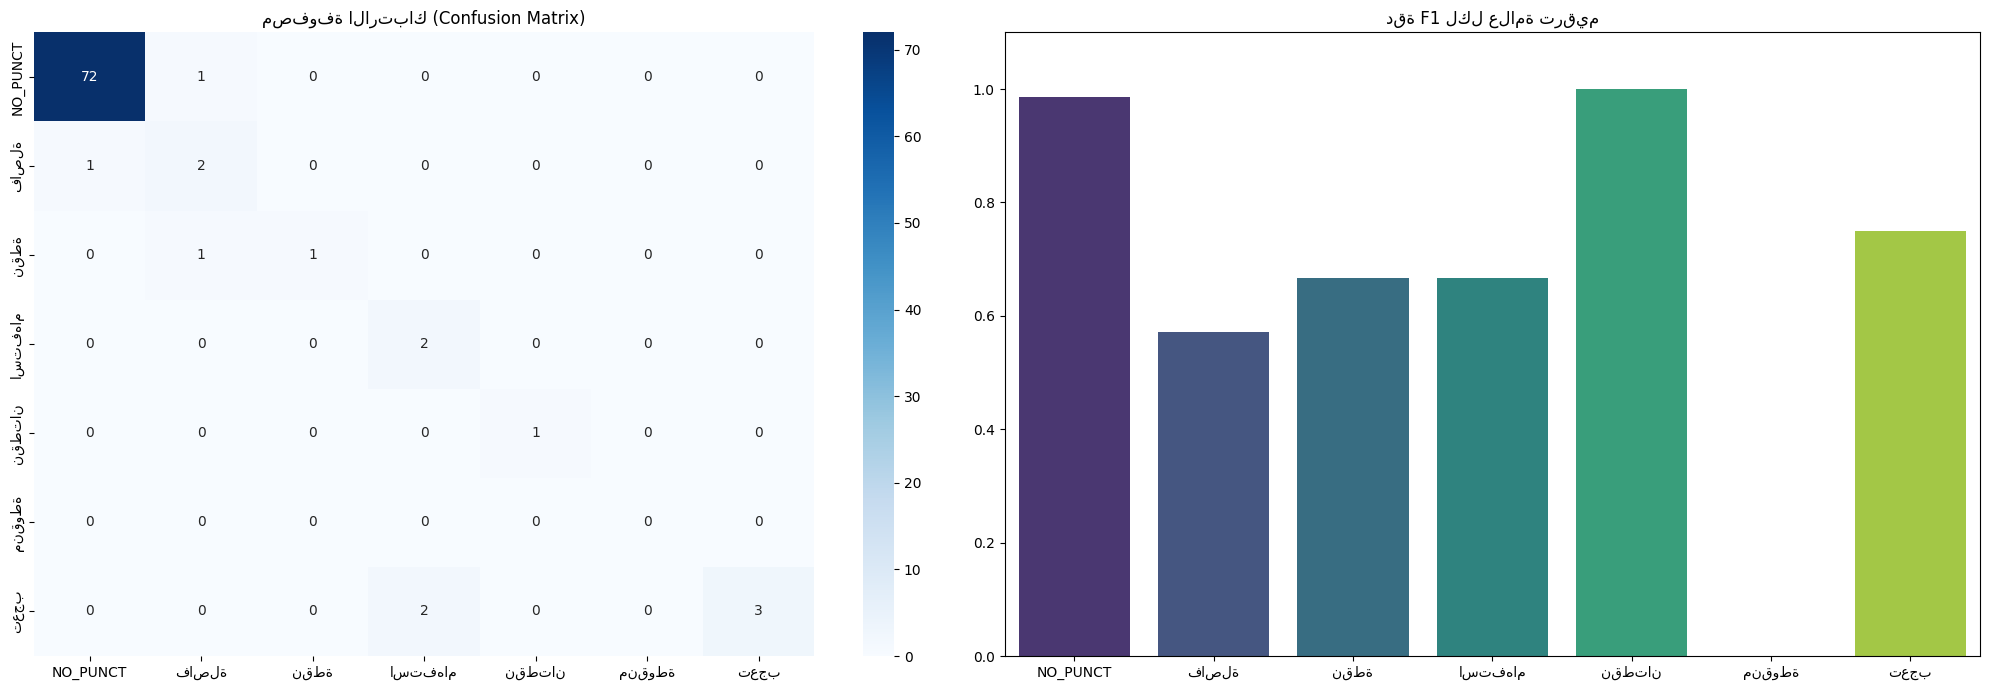

In [ ]:
import os
import torch
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown  # أداة تحميل من جوجل درايف
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML









# =================== 1. الإعدادات والمسارات ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "aubmindlab/bert-base-arabertv02"

# --- تعديل: تحميل الأوزان من الرابط العام بدلاً من المسار الشخصي ---
file_id = '1gUYyMvMDoFBmS_m0yJN1FOoAEx-HRmI_'
model_url = f'https://drive.google.com/uc?id={file_id}'
MODEL_WEIGHTS = 'smart_arabert_medical_finetuned_preproccessed.pt'

if not os.path.exists(MODEL_WEIGHTS):
    print("📥 جاري تحميل أوزان الموديل من الرابط العام...")
    gdown.download(model_url, MODEL_WEIGHTS, quiet=False)

# المسار الذي سيقوم المستخدم الآخر بتغييره لملف الاختبار الخاص به
TEST_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/nlpHompework/SSAC-UNPC_data/SSAC-UNPC/any.txt'

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
NUM_LABELS = len(PUNCTUATION_LABELS)
MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}
INV_MAPPING = {v: (k if k != "" else "🚫") for k, v in MAPPING_REV.items()}

# =================== 2. تحميل الموديل والأوزان ===================
print("🔄 جاري تحميل الموديل والتوكنايزر...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

# تحميل الأوزان المحملة برمجياً
if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
    model.to(device)
    model.eval()
    print(f"✅ تم تحميل الأوزان بنجاح من: {MODEL_WEIGHTS}")
else:
    print(f"❌ خطأ: لم يتم العثور على ملف الأوزان.")

# =================== 3. تابع التقييم المطور مع معالجة المسافات ===================
def evaluate_best_model(test_file_path, model, tokenizer, device):
    all_true_labels = []
    all_pred_labels = []
    comparison_data = [] # لتخزين تحليل الكلمات فرادى

    if not os.path.exists(test_file_path):
        print(f"❌ خطأ: الملف غير موجود في {test_file_path}")
        return None

    with open(test_file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    print(f"🧐 جاري معالجة {len(lines)} سطر وتحليل الأداء...")

    for line_idx, text in enumerate(tqdm(lines, desc="Evaluating")):
        text = text.strip()
        if not text: continue

        # --- خطوة الإصلاح الجوهرية: معالجة النص قبل التقطيع ---
        # 1. توحيد الفاصلة الإنجليزية إلى عربية
        text = text.replace(',', '،')
        # 2. لحم علامات الترقيم بالكلمة التي تسبقها مباشرة (إزالة المسافات قبل العلامة)
        text = re.sub(r'\s+([،.؟:؛!])', r'\1', text)

        # استخراج البيانات الحقيقية بعد التنظيف
        tokens = text.split()
        clean_words = []
        true_labels_in_line = []

        for t in tokens:
            # البحث عن علامة ترقيم في نهاية التوكن
            match = re.search(r'([،.؟:؛!])$', t)
            if match:
                symbol = match.group(1)
                word = t[:-1] # الكلمة بدون العلامة
                label = MAPPING_REV.get(symbol, 0)
            else:
                word, label = t, 0

            if word:
                clean_words.append(word)
                true_labels_in_line.append(label)

        # --- التوقع بواسطة النموذج ---
        input_text = " ".join(clean_words)
        # ملاحظة: التابع predict_long_text_v2 يجب أن يكون معرفاً في بيئتك
        predicted_text = predict_long_text_v2(input_text, model, tokenizer, device)
        pred_tokens = predicted_text.split()

        # --- المقارنة التفصيلية كلمة بكلمة ---
        for j in range(min(len(clean_words), len(pred_tokens))):
            word = clean_words[j]
            t_lab = true_labels_in_line[j]

            # استخراج العلامة المتوقعة من نص الموديل
            m_p = re.search(r'([،.؟:؛!])$', pred_tokens[j])
            p_lab = MAPPING_REV.get(m_p.group(1), 0) if m_p else 0

            all_true_labels.append(t_lab)
            all_pred_labels.append(p_lab)

            # حفظ المقارنة للجدول
            comparison_data.append({
                "السطر": line_idx + 1,
                "الكلمة": word,
                "العلامة الحقيقية": INV_MAPPING[t_lab],
                "توقع النموذج": INV_MAPPING[p_lab],
                "الحالة": "✅" if t_lab == p_lab else "❌"
            })

    # --- عرض النتائج ---
    full_df = pd.DataFrame(comparison_data)
    errors_df = full_df[full_df["الحالة"] == "❌"]

    print("\n" + "="*50)
    print(f"🔍 تحليل الأخطاء (تم العثور على {len(errors_df)} خطأ من أصل {len(full_df)} كلمة):")
    print("="*50)

    # عرض الأخطاء بنظام HTML لتنسيق الأيقونات
    display(HTML(errors_df.head(50).to_html(index=False)))

    # --- التقرير الإحصائي والمخططات ---
    print("\n📊 تقرير التصنيف النهائي:")
    print(classification_report(all_true_labels, all_pred_labels,
                                labels=range(NUM_LABELS),
                                target_names=PUNCTUATION_LABELS,
                                zero_division=0))

    fig, ax = plt.subplots(1, 2, figsize=(20, 7))

    # 1. Confusion Matrix
    cm = confusion_matrix(all_true_labels, all_pred_labels, labels=range(NUM_LABELS))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=PUNCTUATION_LABELS, yticklabels=PUNCTUATION_LABELS, ax=ax[0])
    ax[0].set_title('مصفوفة الارتباك (Confusion Matrix)')

    # 2. F1-Score
    report_dict = classification_report(all_true_labels, all_pred_labels, labels=range(NUM_LABELS), target_names=PUNCTUATION_LABELS, output_dict=True, zero_division=0)
    f1_vals = [report_dict[label]['f1-score'] for label in PUNCTUATION_LABELS]
    sns.barplot(x=PUNCTUATION_LABELS, y=f1_vals, hue=PUNCTUATION_LABELS, ax=ax[1], palette='viridis', legend=False)
    ax[1].set_title('دقة F1 لكل علامة ترقيم')
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

    return full_df

# =================== 4. التشغيل ===================
if 'model' in globals():
    analysis_results = evaluate_best_model(TEST_FILE_PATH, model, tokenizer, device)
else:
    print("⚠️ الموديل غير محمل في الذاكرة.")

📥 جاري تحميل البيانات الطبية من Shifaa...
✅ تم تجهيز 30 نص طبي في الملف: medical_test_data.txt
------------------------------
🧐 جاري معالجة 30 سطر وتحليل الأداء...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


🔍 تحليل الأخطاء (تم العثور على 941 خطأ من أصل 7745 كلمة):


السطر,الكلمة,العلامة الحقيقية,توقع النموذج,الحالة
1,الله-,،,🚫,❌
1,النزف,🚫,:,❌
1,مثل,🚫,:,❌
1,الله-,.,،,❌
1,الاستشارة,🚫,:,❌
1,الحالة,،,؛,❌
1,السبب,،,؛,❌
1,لإجرائه,؛,،,❌
2,العادي,🚫,،,❌
2,الخفي,🚫,،,❌



📊 تقرير التصنيف النهائي:
              precision    recall  f1-score   support

    NO_PUNCT       0.97      0.91      0.93      6503
       فاصلة       0.61      0.76      0.67       836
        نقطة       0.63      0.68      0.65       252
     استفهام       0.71      1.00      0.83         5
      نقطتان       0.35      0.76      0.48        97
      منقوطة       0.32      0.65      0.43        52
        تعجب       0.00      0.00      0.00         0

    accuracy                           0.88      7745
   macro avg       0.51      0.68      0.57      7745
weighted avg       0.90      0.88      0.89      7745



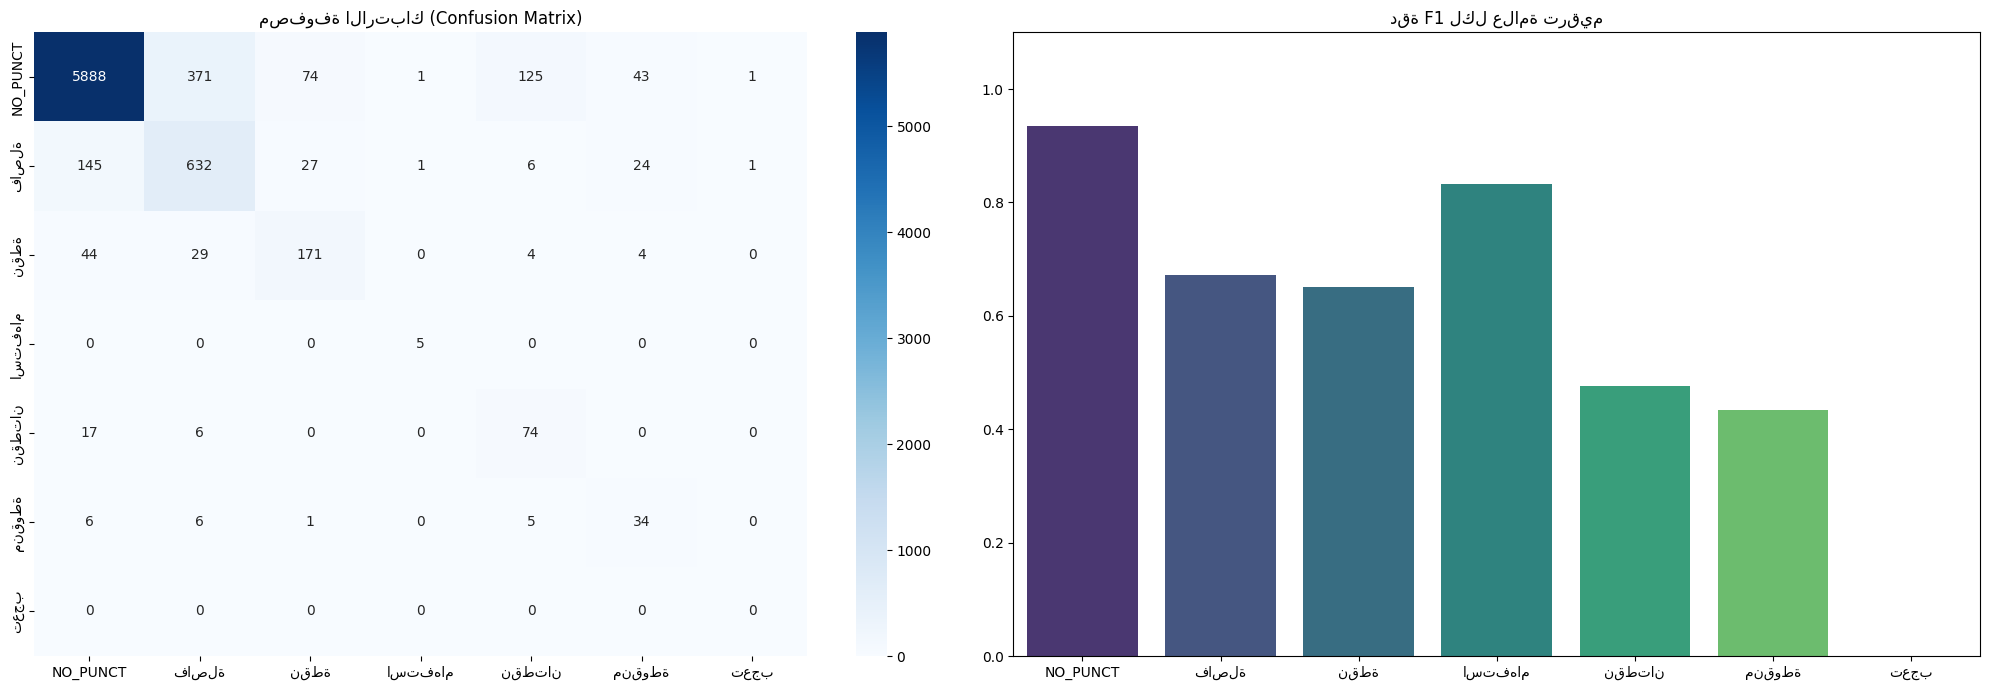

In [ ]:
from datasets import load_dataset
import pandas as pd

# 1. تنزيل البيانات الطبية (قسم الباطنية والصدر)
print("📥 جاري تحميل البيانات الطبية من Shifaa...")
medical_ds = load_dataset("Ahmed-Selem/Shifaa_Arabic_Medical_Consultations",
                          data_files="Internal_Medicine_and_Respiratory_Diseases.csv")

# 2. تحويل البيانات إلى ملف نصي مؤقت ليتوافق مع دخل التابع evaluate_best_model
MEDICAL_TXT_PATH = "medical_test_data.txt"
num_samples = 30 # يمكنك زيادة العدد حسب رغبتك

with open(MEDICAL_TXT_PATH, "w", encoding="utf-8") as f:
    # سنأخذ عينة من عمود 'Answer' لأنها الأكثر ثراءً بعلامات الترقيم
    answers = medical_ds['train']['Answer'][:num_samples]
    for ans in answers:
        if ans:
            # تنظيف بسيط لإزالة السطور الجديدة داخل النص الواحد لضمان معالجة السطر كجملة كاملة
            clean_ans = ans.replace('\n', ' ').strip()
            f.write(clean_ans + "\n")

print(f"✅ تم تجهيز {num_samples} نص طبي في الملف: {MEDICAL_TXT_PATH}")
print("-" * 30)

# 3. استدعاء التابع الأصلي الخاص بك بالمسار الجديد
if 'evaluate_best_model' in globals():
    medical_analysis_results = evaluate_best_model(MEDICAL_TXT_PATH, model, tokenizer, device)
else:
    print("❌ خطأ: لم يتم العثور على تابع evaluate_best_model. تأكد من تشغيل الخلية السابقة أولاً.")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification







# الإعدادات
MODEL_NAME = "aubmindlab/bert-base-arabertv02"
PATH = '/content/drive/MyDrive/Colab Notebooks/nlpHompework/models/smart_arabert_medical_finetuned_preproccessed.pt'
LABELS = ["", "،", ".", "؟", ":", "؛", "!"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# تحميل الموديل والـ Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=7).to(device)
model.load_state_dict(torch.load(PATH, map_location=device))
model.eval()

def predict_punctuation_smart(text, threshold=0.7):
    words = text.split()
    inputs = tokenizer(words, is_split_into_words=True, return_tensors="pt", truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs).logits
        # تحويل النتائج إلى احتمالات باستخدام Softmax
        probs = torch.softmax(outputs, dim=-1).squeeze()
        predictions = torch.argmax(probs, dim=-1).tolist()

    word_ids = inputs.word_ids()
    result = []
    prev_word_idx = None

    for i, word_idx in enumerate(word_ids):
        if word_idx is None or word_idx == prev_word_idx:
            continue

        word = words[word_idx]
        label_idx = predictions[i]
        label_prob = probs[i][label_idx].item()

        # المنطق الذكي:
        # 1. لا تضع علامة إلا إذا كانت الثقة أعلى من العتبة (Threshold)
        # 2. إذا كانت الثقة منخفضة، افترض أنها NO_PUNCT (0)
        if label_idx != 0 and label_prob < threshold:
            actual_punct = ""
        else:
            actual_punct = LABELS[label_idx]

        result.append(word + actual_punct)
        prev_word_idx = word_idx

    return " ".join(result)

# تجربة النص الذي فشل فيه الموديل سابقاً
sample = " يا له من مرض خطير  هل يشعر المريض بآلام حادة في الصدر يجب الانتباه للأعراض التالية ضيق التنفس الغثيان والتعرق البارد إن هذه الحالة تستدعي التدخل العاجل لأن هناك اشتباهاً بجلطة قلبية لا تنتظر أبداً أخبرني متى بدأت الأعراض وهل تناول أي دواء سابقاً"
print(predict_punctuation_smart(sample, threshold=0.8))

Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


يا له من مرض خطير هل يشعر المريض بآلام حادة في الصدر؟ يجب الانتباه للأعراض التالية: ضيق التنفس، الغثيان، والتعرق البارد إن هذه الحالة تستدعي التدخل العاجل؛ لأن هناك اشتباهاً بجلطة قلبية لا تنتظر أبداً أخبرني متى بدأت الأعراض وهل تناول أي دواء؟ سابقاً


# مقارنة النموذجين على بيانات الباطنية والصدر :

In [ ]:
from IPython.display import display, HTML

# 1. جدول المقارنة على بيانات Shifaa الطبية
medical_data_html = """
<style>
    .compare-table { width: 100%; border-collapse: collapse; margin: 25px 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; direction: rtl; text-align: center; }
    .compare-table th { background-color: #2c3e50; color: white; padding: 12px; }
    .compare-table td { border: 1px solid #ddd; padding: 10px; }
    .compare-table tr:nth-child(even) { background-color: #f2f2f2; }
    .compare-table tr:hover { background-color: #e1f5fe; }
    .winner { color: #27ae60; font-weight: bold; }
    .header-title { background-color: #e67e22; color: white; padding: 10px; text-align: center; border-radius: 5px 5px 0 0; margin-top: 20px; }
</style>

<div class="header-title">📊 المقارنة الأولى: نتائج الأداء على بيانات Shifaa الطبية (7745 كلمة)</div>
<table class="compare-table">
    <thead>
        <tr>
            <th>المعيار</th>
            <th>الموديل الطبي (Medical Preprocessed)</th>
            <th>موديل النسخة الثانية (V2 Balanced)</th>
            <th>المتفوق</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>الدقة الكلية (Accuracy)</td>
            <td>88%</td>
            <td>83%</td>
            <td class="winner">الموديل الطبي</td>
        </tr>
        <tr>
            <td>عدد الأخطاء</td>
            <td>941 خطأ</td>
            <td>1285 خطأ</td>
            <td class="winner">الموديل الطبي</td>
        </tr>
        <tr>
            <td>دقة الفاصلة (F1-Score)</td>
            <td>0.67</td>
            <td>0.39</td>
            <td class="winner">الموديل الطبي</td>
        </tr>
        <tr>
            <td>دقة النقطة (F1-Score)</td>
            <td>0.65</td>
            <td>0.40</td>
            <td class="winner">الموديل الطبي</td>
        </tr>
        <tr>
            <td>دقة النقطتين (F1-Score)</td>
            <td>0.48</td>
            <td>0.20</td>
            <td class="winner">الموديل الطبي</td>
        </tr>
        <tr>
            <td>الاستدعاء (Recall) العام</td>
            <td>0.68</td>
            <td>0.44</td>
            <td class="winner">الموديل الطبي</td>
        </tr>
    </tbody>
</table>
"""

# 2. جدول المقارنة على ملف any.txt
any_txt_html = """
<div class="header-title" style="background-color: #2980b9;">📝 المقارنة الثانية: نتائج الأداء على ملف any.txt (86 كلمة)</div>
<table class="compare-table">
    <thead>
        <tr>
            <th>المعيار</th>
            <th>الموديل الطبي (Medical Preprocessed)</th>
            <th>موديل النسخة المتوازنة (V2 Balanced)</th>
            <th>الملاحظة</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>الدقة الكلية (Accuracy)</td>
            <td>94%</td>
            <td>94%</td>
            <td>تساوي في الأداء العام</td>
        </tr>
        <tr>
            <td>عدد الكلمات المختبرة</td>
            <td>86 كلمة</td>
            <td>86 كلمة</td>
            <td>-</td>
        </tr>
        <tr>
            <td>عدد الأخطاء المكتشفة</td>
            <td>5 أخطاء</td>
            <td>5 أخطاء</td>
            <td>-</td>
        </tr>
        <tr>
            <td>دقة الفاصلة (F1-Score)</td>
            <td>0.57</td>
            <td class="winner">0.86</td>
            <td>تفوق النسخة المتوازنة</td>
        </tr>
        <tr>
            <td>دقة علامة التعجب (!)</td>
            <td class="winner">0.75</td>
            <td>0.57</td>
            <td>تفوق الموديل الطبي</td>
        </tr>
        <tr>
            <td>دقة علامة الاستفهام (؟)</td>
            <td>0.67</td>
            <td>0.67</td>
            <td>تساوي</td>
        </tr>
    </tbody>
</table>
"""

# عرض الجداول
display(HTML(medical_data_html))
display(HTML(any_txt_html))

المعيار,الموديل الطبي (Medical Preprocessed),موديل النسخة الثانية (V2 Balanced),المتفوق
الدقة الكلية (Accuracy),88%,83%,الموديل الطبي
عدد الأخطاء,941 خطأ,1285 خطأ,الموديل الطبي
دقة الفاصلة (F1-Score),0.67,0.39,الموديل الطبي
دقة النقطة (F1-Score),0.65,0.40,الموديل الطبي
دقة النقطتين (F1-Score),0.48,0.20,الموديل الطبي
الاستدعاء (Recall) العام,0.68,0.44,الموديل الطبي


المعيار,الموديل الطبي (Medical Preprocessed),موديل النسخة المتوازنة (V2 Balanced),الملاحظة
الدقة الكلية (Accuracy),94%,94%,تساوي في الأداء العام
عدد الكلمات المختبرة,86 كلمة,86 كلمة,-
عدد الأخطاء المكتشفة,5 أخطاء,5 أخطاء,-
دقة الفاصلة (F1-Score),0.57,0.86,تفوق النسخة المتوازنة
دقة علامة التعجب (!),0.75,0.57,تفوق الموديل الطبي
دقة علامة الاستفهام (؟),0.67,0.67,تساوي


سنعتمد على النسخة V2 BALCANCED

 جاري تهيئة الموديل...


Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 تم تحميل الأوزان بنجاح: smart_arabert_v2_balanced.pt
🧐 جاري معالجة 77 سطر وتحليل الأداء...


Evaluating:   0%|          | 0/77 [00:00<?, ?it/s]


🔍 تحليل الأخطاء (تم العثور على 376 خطأ من أصل 2936 كلمة):

📊 تقرير التصنيف النهائي:
              precision    recall  f1-score   support

    NO_PUNCT       0.96      0.93      0.95      2480
       فاصلة       0.31      0.62      0.41       149
        نقطة       0.71      0.58      0.64       257
     استفهام       0.11      0.50      0.18         2
      نقطتان       0.47      0.32      0.38        25
      منقوطة       0.17      0.05      0.07        22
        تعجب       0.00      0.00      0.00         1

    accuracy                           0.87      2936
   macro avg       0.39      0.43      0.38      2936
weighted avg       0.90      0.87      0.88      2936



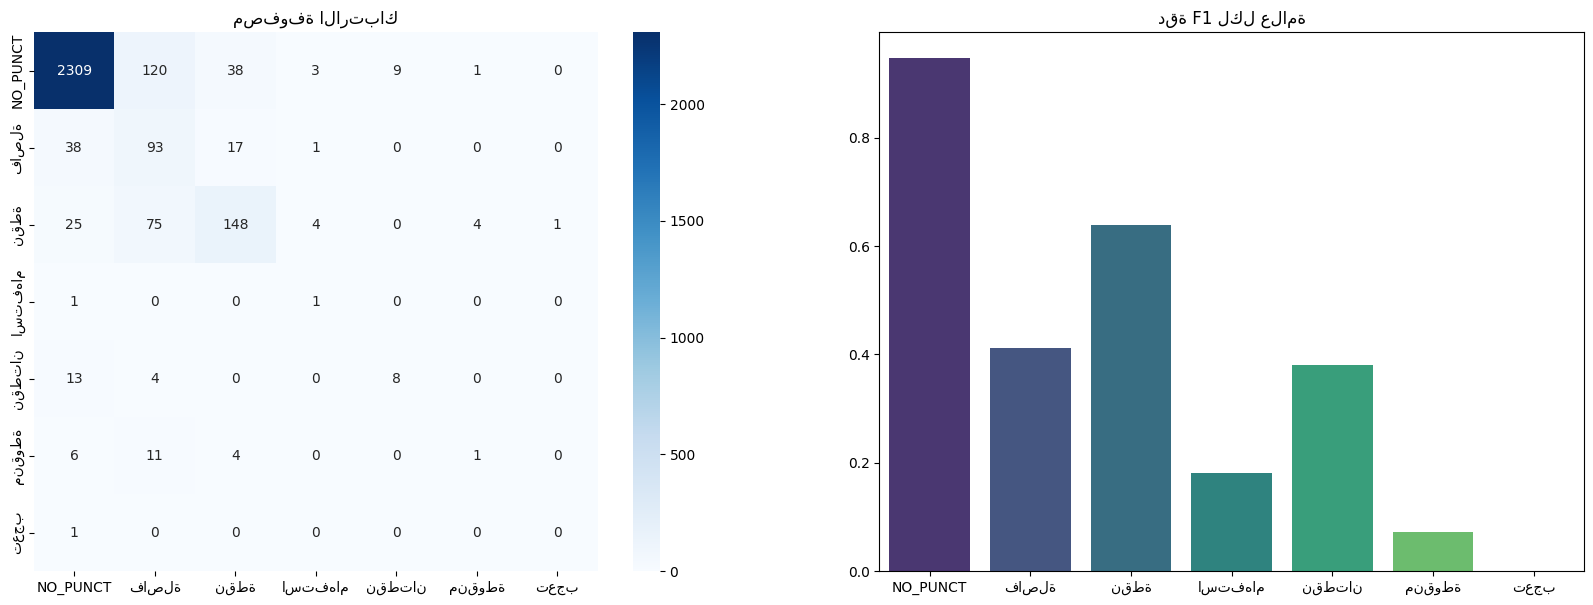

السطر,الكلمة,الحقيقية,التوقع,الحالة
1,الأول,🚫,،,❌
2,تاريخية,🚫,؛,❌
3,الأُمَوِيِّينَ,🚫,؟,❌
4,السياسية,🚫,:,❌
5,الإسلام,🚫,،,❌
5,أنسبائها,.,🚫,❌
5,جميعًا,.,🚫,❌
5,وخصوصًا,🚫,،,❌
5,الخلافة,،,🚫,❌
6,أُمَيَّةَ,🚫,،,❌


In [ ]:
import os
import torch
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML

# =================== 1. الإعدادات والتحميل العام ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "aubmindlab/bert-base-arabertv02"

# --- تحميل الأوزان من الرابط العام ---
file_id = '1hpfXnJ3aSklcMe6wai_YVGfK_Otb24f5'
model_url = f'https://drive.google.com/uc?id={file_id}'
MODEL_WEIGHTS = 'smart_arabert_v2_balanced.pt'

if not os.path.exists(MODEL_WEIGHTS):
    print("📥 جاري تحميل أوزان الموديل من الرابط العام (Drive)...")
    gdown.download(model_url, MODEL_WEIGHTS, quiet=False)

# مسار ملف الاختبار (يمكنك تعديله لأي ملف آخر)
TEST_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/nlpHompework/ABC_44.txt'

PUNCTUATION_LABELS = ["NO_PUNCT", "فاصلة", "نقطة", "استفهام", "نقطتان", "منقوطة", "تعجب"]
LABELS_CHARS = ["", "،", ".", "؟", ":", "؛", "!"]
NUM_LABELS = len(PUNCTUATION_LABELS)
MAPPING_REV = {"": 0, "،": 1, ".": 2, "؟": 3, ":": 4, "؛": 5, "!": 6}
INV_MAPPING = {v: (k if k != "" else "🚫") for k, v in MAPPING_REV.items()}

# =================== 2. وظائف المعالجة والتوقع ===================

def predict_long_text_v2(text, model, tokenizer, device, max_len=128):
    model.eval()
    clean_text = re.sub(r'[،.,؟?:;!]', '', text)
    words = clean_text.split()
    chunk_size = 100
    all_words_with_punct = []
    mapping = {i: char for i, char in enumerate(LABELS_CHARS)}

    for i in range(0, len(words), chunk_size):
        chunk_words = words[i : i + chunk_size]
        inputs = tokenizer(chunk_words, is_split_into_words=True, truncation=True,
                           max_length=max_len, padding='max_length', return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

        word_ids = inputs.word_ids()
        prev_w_idx = None
        for idx, w_idx in enumerate(word_ids):
            if w_idx is not None and w_idx != prev_w_idx:
                if w_idx < len(chunk_words):
                    word = chunk_words[w_idx]
                    label_id = predictions[idx]
                    symbol = mapping.get(label_id, "")
                    all_words_with_punct.append(word + symbol)
                prev_w_idx = w_idx
    return " ".join(all_words_with_punct)

def evaluate_best_model(test_file_path, model, tokenizer, device):
    all_true_labels, all_pred_labels, comparison_data = [], [], []

    if not os.path.exists(test_file_path):
        print(f"❌ خطأ: الملف غير موجود في {test_file_path}"); return None

    with open(test_file_path, 'r', encoding='utf-8') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    print(f"🧐 جاري معالجة {len(lines)} سطر وتحليل الأداء...")

    for line_idx, raw_text in enumerate(tqdm(lines, desc="Evaluating")):
        text_fixed = raw_text.replace(',', '،')
        text_fixed = re.sub(r'\s+([،.؟:؛!])', r'\1', text_fixed)
        tokens = text_fixed.split()
        clean_words, true_labels = [], []
        for t in tokens:
            match = re.search(r'([،.؟:؛!])$', t)
            if match:
                symbol, word = match.group(1), t[:-1]
                label = MAPPING_REV.get(symbol, 0)
            else:
                word, label = t, 0
            if word:
                clean_words.append(word); true_labels.append(label)

        input_text = " ".join(clean_words)
        predicted_text = predict_long_text_v2(input_text, model, tokenizer, device)
        pred_tokens = predicted_text.split()

        for j in range(min(len(clean_words), len(pred_tokens))):
            word, t_lab = clean_words[j], true_labels[j]
            m_p = re.search(r'([،.؟:؛!])$', pred_tokens[j])
            p_lab = MAPPING_REV.get(m_p.group(1), 0) if m_p else 0
            all_true_labels.append(t_lab)
            all_pred_labels.append(p_lab)
            comparison_data.append({
                "السطر": line_idx + 1, "الكلمة": word,
                "الحقيقية": INV_MAPPING[t_lab], "التوقع": INV_MAPPING[p_lab],
                "الحالة": "✅" if t_lab == p_lab else "❌"
            })

    full_df = pd.DataFrame(comparison_data)
    errors_df = full_df[full_df["الحالة"] == "❌"]

    print("\n" + "="*50)
    print(f"🔍 تحليل الأخطاء (تم العثور على {len(errors_df)} خطأ من أصل {len(full_df)} كلمة):")
    print("="*50)

    print("\n📊 تقرير التصنيف النهائي:")
    print(classification_report(all_true_labels, all_pred_labels, labels=range(NUM_LABELS), target_names=PUNCTUATION_LABELS, zero_division=0))


    fig, ax = plt.subplots(1, 2, figsize=(20, 7))
    cm = confusion_matrix(all_true_labels, all_pred_labels, labels=range(NUM_LABELS))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=PUNCTUATION_LABELS, yticklabels=PUNCTUATION_LABELS, ax=ax[0])
    ax[0].set_title('مصفوفة الارتباك')

    report_dict = classification_report(all_true_labels, all_pred_labels, labels=range(NUM_LABELS), target_names=PUNCTUATION_LABELS, output_dict=True, zero_division=0)
    f1_vals = [report_dict[label]['f1-score'] for label in PUNCTUATION_LABELS]
    sns.barplot(x=PUNCTUATION_LABELS, y=f1_vals, hue=PUNCTUATION_LABELS, ax=ax[1], palette='viridis', legend=False)
    ax[1].set_title('دقة F1 لكل علامة')
    plt.show()

    if not errors_df.empty:
        display(HTML("<h3>❌ عينة من الأخطاء (أول 30):</h3>"))
        style = "<style>td, th { text-align: right !important; font-size: 14px; direction: rtl !important; }</style>"
        display(HTML(style + errors_df.head(30).to_html(index=False)))

    return full_df

# =================== 3. التشغيل المباشر ===================

print(" جاري تهيئة الموديل...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
    model.to(device)
    print(f" تم تحميل الأوزان بنجاح: {MODEL_WEIGHTS}")

    # تأكد من وجود ملف اختبار قبل التشغيل، أو سيطبع الكود رسالة خطأ
    analysis_results = evaluate_best_model(TEST_FILE_PATH, model, tokenizer, device)
else:
    print(" فشل تحميل الأوزان.")